### All Statistics PPR2

In [1]:
# =========================
# Libraries and setup  R²
# =========================

from pathlib import Path          # File system paths (OS-independent)
import numpy as np                # Numerical operations (arrays, math)
import pandas as pd               # DataFrames, I/O, tabular manipulation
import matplotlib.pyplot as plt   # for plotting
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
import re                         # Regular expressions (string pattern matching)
import os                         # Useful to save tables, graphs to any location(s)
import dataframe_image as dfi     # Beautiful&neat tables
from scipy.stats import spearmanr
import openpyxl
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from playwright.async_api import async_playwright
from PIL import Image

# Display settings for pandas outputs in notebooks/console
pd.options.display.float_format = '{:.4f}'.format   # Show floats with 4 decimals
pd.set_option('display.max_columns', None) # Force all columns to be visible (wide tables)
# pd.options.display.float_format = '{:.0f}'.format # Alternative: show floats with 0 decimals


In [2]:
# Create an input folder variable
# the_input_folder = r"F:/ALL_ABOUT_PLOTS/PPR2_ACCURATE_Polygon_Shapefiles/"

# Helper function to join folder and filename to be used when reading the data
def input_path(filename):
    return os.path.join(the_input_folder, filename)

# Create an output folder variable
the_output_folder = "C:/Users/.../PPR2_FIGURES&TABLES/"

# Helper function to join folder and filename to be used when saving output
def output_path(filename):
    return os.path.join(the_output_folder, filename)

In [3]:
### Step 1 — Build revised master table of within-model statistics

# ============================================================
# INPUT
# ============================================================

from pathlib import Path
import re
import pandas as pd
import numpy as np

root = Path(
    r"C:\Users\...\..."
    r"\2nd-paper\phd_ppr2\r_model_output"
)

# ============================================================
# HELPERS
# ============================================================

def parse_folder_name(folder_name: str):
    # Expected:
    # PPR2_<Year>_<YYYY-MM-DD>_<Trait>

    match = re.match(
        r"^PPR2_([^_]+)_(\d{4}-\d{2}-\d{2})_(.+)$",
        folder_name
    )

    if not match:
        return None, None, pd.NaT

    year_part = match.group(1).replace("&", "-")
    run_date = pd.to_datetime(match.group(2))
    trait = match.group(3)

    return year_part, trait, run_date


# ============================================================
# FIND ONLY NEWEST FOLDER FOR EACH YEAR × TRAIT
# ============================================================

folder_records = []

for folder in root.iterdir():
    if not folder.is_dir() or not folder.name.startswith("PPR2_"):
        continue

    year_val, trait_val, run_date = parse_folder_name(folder.name)

    if year_val is None or trait_val is None or pd.isna(run_date):
        continue

    folder_records.append({
        "folder": folder,
        "Year": year_val,
        "inVar": trait_val,
        "Run_Date": run_date
    })

folder_table = pd.DataFrame(folder_records)

folder_table = (
    folder_table
    .sort_values("Run_Date")
    .drop_duplicates(subset=["Year", "inVar"], keep="last")
    .reset_index(drop=True)
)

folders = folder_table["folder"].tolist()

print(f"Newest PPR2 folders retained: {len(folders)}")


# ============================================================
# READ *_plot_data_REVISION_METRICS.csv FILES
# ============================================================

rows = []

for folder in folders:
    year_val, trait_val, run_date = parse_folder_name(folder.name)

    revision_files = list(
        folder.glob("*_plot_data_REVISION_METRICS.csv")
    )

    if len(revision_files) == 0:
        print(f"No revision metrics file: {folder.name}")
        continue

    if len(revision_files) > 1:
        print(f"Multiple revision metrics files found; using first: {folder.name}")

    revision_file = revision_files[0]

    try:
        df = pd.read_csv(revision_file)
    except Exception as e:
        print(f"Could not read: {revision_file.name}\n  -> {e}")
        continue

    # Force authoritative metadata from folder structure
    df["Year"] = year_val
    df["inVar"] = trait_val
    df["Run_Date"] = run_date
    df["source_path"] = str(folder)
    df["source_revision_file"] = revision_file.name

    rows.append(df)


if len(rows) == 0:
    raise RuntimeError("No *_plot_data_REVISION_METRICS.csv files were successfully read.")

revision_long = pd.concat(rows, ignore_index=True)


# ============================================================
# STANDARDIZE VALID ITERATION NAME
# ============================================================

if "Valid_Iterations" in revision_long.columns:
    revision_long["Valid_Iter"] = pd.to_numeric(
        revision_long["Valid_Iterations"],
        errors="coerce"
    )
else:
    revision_long["Valid_Iter"] = np.nan


# ============================================================
# CHECK EXPECTED DATASET TYPES
# ============================================================

print(
    "Dataset values found:",
    revision_long["Dataset"].dropna().unique().tolist()
)


# ============================================================
# SPLIT CALIBRATION AND WITHIN-YEAR VALIDATION
# ============================================================

cal_stats = revision_long[
    revision_long["Dataset"] == "Calibration"
].copy()

val_stats = revision_long[
    revision_long["Dataset"] == "Within-year validation"
].copy()


# ============================================================
# COLUMNS THAT DESCRIBE THE MODEL, NOT THE DATASET
# ============================================================

metadata_cols = [
    "Year",
    "inVar",
    "Run_Date",
    "Valid_Iter",
    "source_path",
    "source_revision_file"
]

# Metrics available for calibration/validation comparison
exclude_from_metric_prefix = {
    "Calibration_Years",
    "Trait",
    "Dataset",
    "Valid_Iterations",
    *metadata_cols
}

metric_cols = [
    c for c in revision_long.columns
    if c not in exclude_from_metric_prefix
]


# ============================================================
# PREFIX CALIBRATION AND VALIDATION STATISTICS
# ============================================================

cal_keep = [c for c in metadata_cols + metric_cols if c in cal_stats.columns]
val_keep = [c for c in metadata_cols + metric_cols if c in val_stats.columns]

cal_stats = cal_stats[cal_keep].copy()
val_stats = val_stats[val_keep].copy()

cal_stats = cal_stats.rename(
    columns={c: f"Cal_{c}" for c in metric_cols if c in cal_stats.columns}
)

val_stats = val_stats.rename(
    columns={c: f"Val_{c}" for c in metric_cols if c in val_stats.columns}
)


# ============================================================
# ONE ROW PER MODEL
# ============================================================

# Metadata need only come from one side of the merge
val_stats = val_stats.drop(
    columns=[
        "Run_Date",
        "Valid_Iter",
        "source_path",
        "source_revision_file"
    ],
    errors="ignore"
)

all_stats = cal_stats.merge(
    val_stats,
    on=["Year", "inVar"],
    how="outer",
    validate="one_to_one"
)


# ============================================================
# PRESERVE OLD DOWNSTREAM VARIABLE NAMES
#
# IMPORTANT:
# These now refer to the revised residual-based R² values.
# ============================================================

if "Cal_Residual_R2" in all_stats.columns:
    all_stats["Cal_R2"] = all_stats["Cal_Residual_R2"]

if "Val_Residual_R2" in all_stats.columns:
    all_stats["Val_R2"] = all_stats["Val_Residual_R2"]

# Cal_RMSEP and Val_RMSEP already exist naturally after prefixing
# the revision-metric RMSEP column.


# ============================================================
# NUMERIC CLEANING
# ============================================================

for c in all_stats.columns:
    if (
        c == "Valid_Iter" or
        c.startswith("Cal_") or
        c.startswith("Val_")
    ):
        if c not in [
            "Cal_Source_Folder",
            "Cal_Source_RData",
            "Val_Source_Folder",
            "Val_Source_RData"
        ]:
            all_stats[c] = pd.to_numeric(
                all_stats[c],
                errors="ignore"
            )


# ============================================================
# SANITY CHECKS
# ============================================================

print(f"Revision files read: {len(rows)}")
print(f"Calibration rows: {len(cal_stats)}")
print(f"Validation rows: {len(val_stats)}")
print(f"Final one-row-per-model table: {len(all_stats)}")

print("\nValid iteration range:")
print(all_stats["Valid_Iter"].min(), "to", all_stats["Valid_Iter"].max())

print("\nRevised R² columns available:")
print(
    [
        c for c in [
            "Cal_Residual_R2",
            "Val_Residual_R2",
            "Cal_R2",
            "Val_R2"
        ]
        if c in all_stats.columns
    ]
)

# all_stats.head()
all_stats.loc[:, ~all_stats.columns.str.contains("source", case=False)].head()

Newest PPR2 folders retained: 98
No revision metrics file: PPR2_2011_2026-08-05_ADL_perc
No revision metrics file: PPR2_2010_2026-08-05_C_perc
No revision metrics file: PPR2_2012_2026-08-05_C_perc
No revision metrics file: PPR2_2011_2026-08-05_Biom_wet_g
No revision metrics file: PPR2_2010-2011_2026-08-05_ADF_perc
Dataset values found: ['Calibration', 'Within-year validation']
Revision files read: 93
Calibration rows: 93
Validation rows: 93
Final one-row-per-model table: 93

Valid iteration range:
3 to 1000

Revised R² columns available:
['Cal_Residual_R2', 'Val_Residual_R2', 'Cal_R2', 'Val_R2']


,Year,inVar,Run_Date,Valid_Iter,Cal_N,Cal_Observed_Mean,Cal_Predicted_Mean,Cal_Observed_SD,Cal_Predicted_SD,Cal_Observed_Min,Cal_Observed_Max,Cal_Observed_Range,Cal_Residual_R2,Cal_Pearson_r,Cal_Spearman_rho,Cal_R2_regression,Cal_Adjusted_R2_regression,Cal_Regression_Intercept,Cal_Regression_Slope,Cal_Bias_Predicted_minus_Observed,Cal_MAE,Cal_MSE,Cal_RMSEP,Cal_nRMSEP_SD_percent,Cal_nRMSEP_Range_percent,Cal_PRESS_SSE,Cal_SST,Cal_Squared_Bias_Component,Cal_Unequal_Variance_Component,Cal_Incomplete_Correlation_Component,Cal_Squared_Bias_Percent_MSE,Cal_Unequal_Variance_Percent_MSE,Cal_Incomplete_Correlation_Percent_MSE,Cal_Decomposition_Sum,Cal_Decomposition_Difference_from_MSE,Val_N,Val_Observed_Mean,Val_Predicted_Mean,Val_Observed_SD,Val_Predicted_SD,Val_Observed_Min,Val_Observed_Max,Val_Observed_Range,Val_Residual_R2,Val_Pearson_r,Val_Spearman_rho,Val_R2_regression,Val_Adjusted_R2_regression,Val_Regression_Intercept,Val_Regression_Slope,Val_Bias_Predicted_minus_Observed,Val_MAE,Val_MSE,Val_RMSEP,Val_nRMSEP_SD_percent,Val_nRMSEP_Range_percent,Val_PRESS_SSE,Val_SST,Val_Squared_Bias_Component,Val_Unequal_Variance_Component,Val_Incomplete_Correlation_Component,Val_Squared_Bias_Percent_MSE,Val_Unequal_Variance_Percent_MSE,Val_Incomplete_Correlation_Percent_MSE,Val_Decomposition_Sum,Val_Decomposition_Difference_from_MSE,Cal_R2,Val_R2
0,2010,N_perc,2026-08-05,3,25,2.2830,2.2506,0.7411,0.4314,1.3499,4.0047,2.6548,0.3956,0.6326,0.5654,0.4002,0.3741,1.4100,0.3682,-0.0325,0.4563,0.3187,0.5645,76.1709,21.2646,7.9674,13.1829,0.0011,0.0921,0.2255,0.3308,28.9045,70.7646,0.3187,0,12,2.5510,2.1535,0.9031,0.4898,1.3499,4.0047,2.6548,-0.7304,-0.2072,-0.3636,0.0430,-0.0528,2.4402,-0.1124,-0.3975,0.9213,1.2936,1.1374,125.9450,42.8417,15.5231,8.9707,0.1580,0.1565,0.9790,12.2161,12.1007,75.6832,1.2936,0,0.3956,-0.7304
1,2011,ADF_perc,2026-08-05,7,16,29.6612,29.5696,3.3790,2.0668,23.6597,34.2817,10.6220,0.5731,0.7749,0.8088,0.6005,0.5720,15.5106,0.4740,-0.0916,1.8180,4.5699,2.1377,63.2644,20.1255,73.1182,171.2684,0.0084,1.6144,2.9471,0.1837,35.3275,64.4888,4.5699,0,10,30.8294,28.8966,2.7607,4.9032,26.5847,34.4070,7.8223,-4.5270,-0.2331,-0.4545,0.0543,-0.0639,41.6603,-0.4140,-1.9328,5.2035,37.9124,6.1573,223.0310,78.7144,379.1238,68.5951,3.7359,4.1311,30.0454,9.8540,10.8964,79.2496,37.9124,0,0.5731,-4.5270
2,2011-2013,N_perc,2026-08-05,484,118,1.7945,1.7938,0.3323,0.2244,1.1997,2.6784,1.4787,0.5967,0.7795,0.7742,0.6076,0.6042,0.8494,0.5263,-0.0007,0.1602,0.0442,0.2102,63.2356,14.2117,5.2114,12.9221,0.0000,0.0116,0.0326,0.0011,26.1634,73.8354,0.0442,0,118,1.7945,1.7905,0.3323,0.2190,1.1997,2.6784,1.4787,0.2866,0.5470,0.5699,0.2992,0.2932,1.1437,0.3604,-0.0040,0.2123,0.0781,0.2795,84.1048,18.9018,9.2187,12.9221,0.0000,0.0127,0.0654,0.0204,16.3124,83.6672,0.0781,0,0.5967,0.2866
3,2011-2013,NDF_perc,2026-08-05,170,118,51.2408,51.2346,4.7360,1.9086,40.0702,67.6542,27.5840,0.3882,0.6832,0.6582,0.4667,0.4621,37.1269,0.2753,-0.0062,2.9019,13.6056,3.6886,77.8833,13.3721,1605.4559,2624.3025,0.0000,7.9266,5.6789,0.0003,58.2601,41.7396,13.6056,0,118,51.2408,51.1977,4.7360,2.0820,40.0702,67.6542,27.5840,-0.0354,0.1797,0.3298,0.0323,0.0239,47.1502,0.0790,-0.0431,3.4889,23.0262,4.7986,101.3205,17.3962,2717.0967,2624.3025,0.0019,6.9841,16.0403,0.0081,30.3312,69.6608,23.0262,0,0.3882,-0.0354
4,2011-2013,C_perc,2026-08-05,995,118,42.1974,42.1968,1.5439,0.8237,33.1000,44.2223,11.1223,0.3666,0.6103,0.3491,0.3725,0.3671,28.4564,0.3256,-0.0006,0.8413,1.4970,1.2235,79.2500,11.0006,176.6471,278.8767,0.0000,0.5142,0.9828,0.0000,34.3506,65.6494,1.4970,0,118,42.1974,42.2157,1.5439,0.8168,33.1000,44.2223,11.1223,0.1500,0.4065,0.2468,0.1652,0.1580,33.1409,0.2151,0.0183,0.9261,2.0088,1.4173,91.8021,12.7429,237.0354,278.8767,0.0003,0.5241,1.4843,0.0167,26.0903,73.8930,2.0088,0,0.3666,0.1500


In [4]:
# =========================
# Clean and standardize metadata
# =========================

all_stats["Year"] = (
    all_stats["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

all_stats["Year"] = all_stats["Year"].replace(["", "None"], pd.NA)
all_stats["inVar"] = all_stats["inVar"].replace(["", "None"], pd.NA)

all_stats = all_stats[
    ~(all_stats["Year"].isna() & all_stats["inVar"].isna())
].copy()


### Step 2 — Generalization gap

all_stats["R2_gap"] = (
    all_stats["Cal_R2"] - all_stats["Val_R2"]
).abs()

all_stats[
    ["Year", "inVar", "Cal_R2", "Val_R2", "R2_gap", "Valid_Iter"]
].head(5)

,Year,inVar,Cal_R2,Val_R2,R2_gap,Valid_Iter
0,2010,N_perc,0.3956,-0.7304,1.1260,3
1,2011,ADF_perc,0.5731,-4.5270,5.1001,7
2,2011-2013,N_perc,0.5967,0.2866,0.3101,484
3,2011-2013,NDF_perc,0.3882,-0.0354,0.4236,170
4,2011-2013,C_perc,0.3666,0.1500,0.2165,995


In [5]:
# For analyses that are specifically meant to use retained/CONVERGED MODELS

all_stats_converged = all_stats[
    all_stats["Valid_Iter"] >= 700
].copy()


In [6]:
# ============================================================
# ADD ITERATION-LEVEL STABILITY + nComps METRICS TO all_stats
# ============================================================
#
# Source:
#   *_REF_DF_MODELs-*-STATISTICS.csv
#
# Adds ONLY:
#   Iter_R2_iqr
#   Iter_R2_sd
#   Iter_nComps_mode
#   Iter_nComps_mode_pct
#   Iter_nComps_range
#
# Performance statistics in all_stats remain based on the
# *_plot_data_REVISION_METRICS.csv files.
# ============================================================

stability_rows = []

# IMPORTANT:
# "folders" comes from Cell 1 and contains only the newest
# PPR2 folder for each Year × trait combination.
for folder in folders:

    year_val, trait_val, run_date = parse_folder_name(folder.name)

    if year_val is None or trait_val is None:
        continue

    # Find iteration-level statistics file(s)
    stats_candidates = list(
        folder.glob("*_REF_DF_MODELs-*-STATISTICS.csv")
    )

    if not stats_candidates:
        print(f"No iteration statistics file: {folder.name}")
        continue

    df_list = []

    for f in stats_candidates:
        try:
            df = pd.read_csv(f).drop(
                columns=["Unnamed: 0"],
                errors="ignore"
            )
            df_list.append(df)

        except Exception as e:
            print(f"Could not read: {f.name}\n  -> {e}")

    if not df_list:
        continue

    df_iter = pd.concat(df_list, ignore_index=True)

    # Required iteration-level variables
    required = {"R2", "Valid_Iter", "Processing", "nComps"}

    if not required.issubset(df_iter.columns):
        missing = required - set(df_iter.columns)

        print(
            f"Missing required columns in {folder.name}: "
            f"{sorted(missing)}"
        )
        continue

    # Keep only the intended trait
    df_iter = df_iter[
        df_iter["Processing"].astype(str) == str(trait_val)
    ].copy()

    if len(df_iter) == 0:
        print(
            f"No iteration rows matching trait "
            f"{trait_val}: {folder.name}"
        )
        continue

    # Numeric conversion
    df_iter["R2"] = pd.to_numeric(
        df_iter["R2"],
        errors="coerce"
    )

    df_iter["Valid_Iter"] = pd.to_numeric(
        df_iter["Valid_Iter"],
        errors="coerce"
    )

    df_iter["nComps"] = pd.to_numeric(
        df_iter["nComps"],
        errors="coerce"
    )

    # Keep complete iteration rows
    df_iter = df_iter.dropna(
        subset=["Valid_Iter", "R2", "nComps"]
    )

    # If multiple files contain the same iteration ID,
    # retain only one value for that iteration
    df_iter = (
        df_iter
        .sort_values("Valid_Iter")
        .drop_duplicates(
            subset=["Valid_Iter"],
            keep="last"
        )
    )

    if len(df_iter) < 2:
        print(
            f"Fewer than two usable iteration rows: "
            f"{folder.name}"
        )
        continue

    # --------------------------------------------------------
    # R² stability across successful iterations
    # --------------------------------------------------------

    iter_r2_iqr = (
        df_iter["R2"].quantile(0.75) -
        df_iter["R2"].quantile(0.25)
    )

    iter_r2_sd = df_iter["R2"].std()

    # --------------------------------------------------------
    # nComps stability
    # --------------------------------------------------------

    ncomps_series = df_iter["nComps"].dropna().astype(int)

    if len(ncomps_series) == 0:
        ncomps_mode_val = np.nan
        ncomps_mode_pct = np.nan
        ncomps_range = np.nan

    else:
        ncomps_mode = ncomps_series.mode()

        ncomps_mode_val = (
            int(ncomps_mode.iloc[0])
            if len(ncomps_mode) > 0
            else np.nan
        )

        mode_count = (
            int((ncomps_series == ncomps_mode_val).sum())
            if pd.notna(ncomps_mode_val)
            else 0
        )

        ncomps_mode_pct = (
            100 * mode_count / len(ncomps_series)
            if len(ncomps_series) > 0
            else np.nan
        )

        ncomps_range = int(
            ncomps_series.max() -
            ncomps_series.min()
        )

    stability_rows.append({
        "Year": str(year_val).replace("&", "-"),
        "inVar": str(trait_val),

        "Iter_R2_iqr": iter_r2_iqr,
        "Iter_R2_sd": iter_r2_sd,

        "Iter_nComps_mode": ncomps_mode_val,
        "Iter_nComps_mode_pct": ncomps_mode_pct,
        "Iter_nComps_range": ncomps_range
    })


# ============================================================
# BUILD STABILITY TABLE
# ============================================================

stability_df = pd.DataFrame(stability_rows)

if stability_df.empty:
    raise RuntimeError(
        "No iteration-level stability statistics were produced."
    )

stability_df["Year"] = (
    stability_df["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

stability_df["inVar"] = (
    stability_df["inVar"]
    .astype("string")
)


# ============================================================
# CHECK 1 — ONE ROW PER YEAR × TRAIT IN stability_df
# ============================================================

duplicate_stability_keys = stability_df[
    stability_df.duplicated(
        subset=["Year", "inVar"],
        keep=False
    )
].copy()

if len(duplicate_stability_keys) > 0:

    print(
        duplicate_stability_keys
        .sort_values(["Year", "inVar"])
    )

    raise ValueError(
        "stability_df contains duplicate Year × inVar keys. "
        "Merge stopped."
    )

print(
    "Duplicate Year × trait keys in stability_df:",
    len(duplicate_stability_keys)
)


# ============================================================
# CHECK 2 — ONE ROW PER YEAR × TRAIT IN all_stats
# ============================================================

duplicate_all_stats_keys = all_stats[
    all_stats.duplicated(
        subset=["Year", "inVar"],
        keep=False
    )
].copy()

if len(duplicate_all_stats_keys) > 0:

    print(
        duplicate_all_stats_keys[
            ["Year", "inVar"]
        ].sort_values(["Year", "inVar"])
    )

    raise ValueError(
        "all_stats contains duplicate Year × inVar keys. "
        "Merge stopped."
    )

print(
    "Duplicate Year × trait keys in all_stats:",
    len(duplicate_all_stats_keys)
)


# ============================================================
# CHECK 3 — FIND STABILITY MODELS NOT PRESENT IN all_stats
# ============================================================

unmatched_stability = (
    stability_df[["Year", "inVar"]]
    .merge(
        all_stats[["Year", "inVar"]],
        on=["Year", "inVar"],
        how="left",
        indicator=True
    )
    .query("_merge == 'left_only'")
    [["Year", "inVar"]]
)

print(
    "Stability rows not represented in all_stats:",
    len(unmatched_stability)
)

if len(unmatched_stability) > 0:
    print(
        unmatched_stability
        .sort_values(["Year", "inVar"])
    )


# ============================================================
# CHECK 4 — FIND all_stats MODELS WITHOUT STABILITY DATA
# ============================================================

missing_stability_before_merge = (
    all_stats[["Year", "inVar"]]
    .merge(
        stability_df[["Year", "inVar"]],
        on=["Year", "inVar"],
        how="left",
        indicator=True
    )
    .query("_merge == 'left_only'")
    [["Year", "inVar"]]
)

print(
    "all_stats models without iteration stability data:",
    len(missing_stability_before_merge)
)

if len(missing_stability_before_merge) > 0:
    print(
        missing_stability_before_merge
        .sort_values(["Year", "inVar"])
    )


# ============================================================
# MERGE INTO all_stats
# ============================================================

rows_before_merge = len(all_stats)

all_stats = all_stats.merge(
    stability_df,
    on=["Year", "inVar"],
    how="left",
    validate="one_to_one"
)

rows_after_merge = len(all_stats)


# ============================================================
# POST-MERGE SAFETY CHECKS
# ============================================================

if rows_before_merge != rows_after_merge:
    raise RuntimeError(
        "Row count changed during stability merge. "
        f"Before: {rows_before_merge}; "
        f"after: {rows_after_merge}"
    )

print("\n============================================")
print("ITERATION-STABILITY MERGE COMPLETE")
print("============================================")

print(
    "stability_df rows:",
    len(stability_df)
)

print(
    "all_stats rows before merge:",
    rows_before_merge
)

print(
    "all_stats rows after merge:",
    rows_after_merge
)

print(
    "Models with Iter_R2_iqr:",
    all_stats["Iter_R2_iqr"].notna().sum()
)

print(
    "Models without Iter_R2_iqr:",
    all_stats["Iter_R2_iqr"].isna().sum()
)

print("============================================")


# ============================================================
# INSPECT MODELS WITHOUT STABILITY STATISTICS
# ============================================================

models_without_stability = all_stats.loc[
    all_stats["Iter_R2_iqr"].isna(),
    ["Year", "inVar", "Valid_Iter"]
].sort_values(
    ["Year", "inVar"]
)

if len(models_without_stability) > 0:
    print("\nModels without iteration stability statistics:")
    print(models_without_stability.to_string(index=False))


# ============================================================
# DISPLAY MERGED VARIABLES
# ============================================================

all_stats[[
    "Year",
    "inVar",
    "Valid_Iter",
    "Val_R2",
    "Iter_R2_iqr",
    "Iter_R2_sd",
    "Iter_nComps_mode",
    "Iter_nComps_mode_pct",
    "Iter_nComps_range"
]].head(10)

No iteration statistics file: PPR2_2011_2026-08-05_ADL_perc
No iteration statistics file: PPR2_2010_2026-08-05_C_perc
Fewer than two usable iteration rows: PPR2_2012_2026-08-05_C_perc
Fewer than two usable iteration rows: PPR2_2011_2026-08-05_Biom_wet_g
Fewer than two usable iteration rows: PPR2_2010-2011_2026-08-05_ADF_perc
Duplicate Year × trait keys in stability_df: 0
Duplicate Year × trait keys in all_stats: 0
Stability rows not represented in all_stats: 0
all_stats models without iteration stability data: 0

ITERATION-STABILITY MERGE COMPLETE
stability_df rows: 93
all_stats rows before merge: 93
all_stats rows after merge: 93
Models with Iter_R2_iqr: 93
Models without Iter_R2_iqr: 0


,Year,inVar,Valid_Iter,Val_R2,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range
0,2010,N_perc,3,-0.7304,0.0217,0.0221,1,66.6667,1
1,2011,ADF_perc,7,-4.5270,0.3855,0.2341,1,57.1429,2
2,2011-2013,N_perc,484,0.2866,0.0865,0.0659,4,14.8760,18
3,2011-2013,NDF_perc,170,-0.0354,0.2214,0.1159,2,34.1176,15
4,2011-2013,C_perc,995,0.1500,0.0789,0.0736,2,77.5879,14
5,2011-2013,Biom_wet_g,1000,0.2431,0.1047,0.0954,6,45.9000,21
6,2011-2013,Biom_dry_g,1000,0.1550,0.0760,0.0580,1,65.0000,24
7,2011-2013,ADL_perc,1000,0.3615,0.1059,0.0814,10,58.9000,17
8,2011-2013,ADF_perc,707,0.0892,0.1972,0.1295,2,50.3536,17
9,2011-2012,N_perc,492,0.3252,0.0977,0.1002,6,31.9106,20


In [7]:
# ============================================================
# SORT all_stats BY TRAIT AND CALIBRATION YEAR
# ============================================================

year_order = [
    "2010","2011","2012","2013",
    "2010-2011","2010-2012","2010-2013",
    "2011-2012","2011-2013","2012-2013",
    "2010-2011-2012","2010-2011-2013",
    "2010-2012-2013","2011-2012-2013"
]

year_rank = {y: i for i, y in enumerate(year_order)}

all_stats["_year_rank"] = (
    all_stats["Year"].astype(str)
    .map(year_rank)
    .fillna(9999)
    .astype(int)
)

all_stats = (
    all_stats
    .sort_values(["inVar", "_year_rank"])
    .drop(columns=["_year_rank"])
    .reset_index(drop=True)
)


# ============================================================
# YEAR-LEVEL METADATA: AGDD, PHENOLOGY, CLIMATE, MODEL TYPE
# ============================================================

data = [
    # Single-year models
    ["2010", "20100624", "225.1", 225.1, "14.2", "52.2", "early", "Single_Year"],
    ["2011", "20110626", "319.8", 319.8, "17.6", "141.5", "late", "Single_Year"],
    ["2012", "20120629", "333.3", 333.3, "19.6", "132.7", "late", "Single_Year"],
    ["2013", "20130712", "321.5", 321.5, "16.2", "56.7", "late", "Single_Year"],

    # Two-year combinations
    ["2010-2011", "20100624 - 20110626", "225.1 - 319.8", 272.45,
     "14.2 - 17.6", "52.2 - 141.5", "mid", "Combined_Year"],

    ["2010-2012", "20100624 - 20120629", "225.1 - 333.3", 279.2,
     "14.2 - 19.6", "52.2 - 132.7", "mid", "Combined_Year"],

    ["2010-2013", "20100624 - 20130712", "225.1 - 321.5", 273.3,
     "14.2 - 16.2", "52.2 - 56.7", "mid", "Combined_Year"],

    ["2011-2012", "20110626 - 20120629", "319.8 - 333.3", 326.6,
     "17.6 - 19.6", "141.5 - 132.7", "late", "Combined_Year"],

    ["2011-2013", "20110626 - 20130712", "319.8 - 321.5", 320.7,
     "17.6 - 16.2", "141.5 - 56.7", "late", "Combined_Year"],

    ["2012-2013", "20120629 - 20130712", "333.3 - 321.5", 327.4,
     "19.6 - 16.2", "132.7 - 56.7", "late", "Combined_Year"],

    # Three-year combinations
    ["2010-2011-2012", "20100624 - 20110626 - 20120629",
     "225.1 - 319.8 - 333.3", 292.7,
     "14.2 - 17.6 - 19.6", "52.2 - 141.5 - 132.7",
     "mid", "Combined_Year"],

    ["2010-2011-2013", "20100624 - 20110626 - 20130712",
     "225.1 - 319.8 - 321.5", 288.8,
     "14.2 - 17.6 - 16.2", "52.2 - 141.5 - 56.7",
     "mid", "Combined_Year"],

    ["2010-2012-2013", "20100624 - 20120629 - 20130712",
     "225.1 - 333.3 - 321.5", 293.3,
     "14.2 - 19.6 - 16.2", "52.2 - 132.7 - 56.7",
     "mid", "Combined_Year"],

    ["2011-2012-2013", "20110626 - 20120629 - 20130712",
     "319.8 - 333.3 - 321.5", 324.9,
     "17.6 - 19.6 - 16.2", "141.5 - 132.7 - 56.7",
     "late", "Combined_Year"]
]

columns = [
    "Year_int", "Img_acq_date", "AGDD", "AGDD_int_avg",
    "T_avg_M_C0", "Precip_Avg_M_mm", "Phenology", "Model_Type"
]

df_meta = pd.DataFrame(data, columns=columns)


# ============================================================
# ADD WITHIN-CALIBRATION AGDD RANGE
# ============================================================

annual_agdd = {
    "2010": 225.1,
    "2011": 319.8,
    "2012": 333.3,
    "2013": 321.5
}

def get_agdd_values(year_label):
    years = str(year_label).split("-")
    return [annual_agdd[y] for y in years]

df_meta["AGDD_min"] = df_meta["Year_int"].apply(
    lambda x: min(get_agdd_values(x))
)

df_meta["AGDD_max"] = df_meta["Year_int"].apply(
    lambda x: max(get_agdd_values(x))
)

df_meta["AGDD_range"] = (
    df_meta["AGDD_max"] - df_meta["AGDD_min"]
)

df_meta.head(10)

,Year_int,Img_acq_date,AGDD,AGDD_int_avg,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,AGDD_min,AGDD_max,AGDD_range
0,2010,20100624,225.1,225.1000,14.2,52.2,early,Single_Year,225.1000,225.1000,0.0000
1,2011,20110626,319.8,319.8000,17.6,141.5,late,Single_Year,319.8000,319.8000,0.0000
2,2012,20120629,333.3,333.3000,19.6,132.7,late,Single_Year,333.3000,333.3000,0.0000
3,2013,20130712,321.5,321.5000,16.2,56.7,late,Single_Year,321.5000,321.5000,0.0000
4,2010-2011,20100624 - 20110626,225.1 - 319.8,272.4500,14.2 - 17.6,52.2 - 141.5,mid,Combined_Year,225.1000,319.8000,94.7000
5,2010-2012,20100624 - 20120629,225.1 - 333.3,279.2000,14.2 - 19.6,52.2 - 132.7,mid,Combined_Year,225.1000,333.3000,108.2000
6,2010-2013,20100624 - 20130712,225.1 - 321.5,273.3000,14.2 - 16.2,52.2 - 56.7,mid,Combined_Year,225.1000,321.5000,96.4000
7,2011-2012,20110626 - 20120629,319.8 - 333.3,326.6000,17.6 - 19.6,141.5 - 132.7,late,Combined_Year,319.8000,333.3000,13.5000
8,2011-2013,20110626 - 20130712,319.8 - 321.5,320.7000,17.6 - 16.2,141.5 - 56.7,late,Combined_Year,319.8000,321.5000,1.7000
9,2012-2013,20120629 - 20130712,333.3 - 321.5,327.4000,19.6 - 16.2,132.7 - 56.7,late,Combined_Year,321.5000,333.3000,11.8000


In [8]:
# ============================================================
# EXPAND YEAR-LEVEL METADATA TO YEAR × TRAIT
# ============================================================

traits = [
    "ADF_perc",
    "ADL_perc",
    "Biom_dry_g",
    "Biom_wet_g",
    "C_perc",
    "NDF_perc",
    "N_perc"
]

# Repeat each metadata row for all seven study traits
df_meta_long = df_meta.merge(
    pd.DataFrame({"inVar": traits}),
    how="cross"
)

# Custom year ordering
year_rank = {y: i for i, y in enumerate(year_order)}

df_meta_long["_year_rank"] = (
    df_meta_long["Year_int"]
    .map(year_rank)
    .fillna(9999)
    .astype(int)
)

df_meta_long = (
    df_meta_long
    .sort_values(["inVar", "_year_rank"])
    .drop(columns=["_year_rank"])
    .reset_index(drop=True)
)

# Reorder columns
cols = [
    "Year_int",
    "inVar",
    "Img_acq_date",
    "AGDD",
    "AGDD_int_avg",
    "AGDD_min",
    "AGDD_max",
    "AGDD_range",
    "T_avg_M_C0",
    "Precip_Avg_M_mm",
    "Phenology",
    "Model_Type"
]

df_meta_long = df_meta_long[cols]

print("Metadata rows:", len(df_meta_long))
print("Expected rows:", len(df_meta) * len(traits))

df_meta_long.head(10)

Metadata rows: 98
Expected rows: 98


,Year_int,inVar,Img_acq_date,AGDD,AGDD_int_avg,AGDD_min,AGDD_max,AGDD_range,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type
0,2010,ADF_perc,20100624,225.1,225.1000,225.1000,225.1000,0.0000,14.2,52.2,early,Single_Year
1,2011,ADF_perc,20110626,319.8,319.8000,319.8000,319.8000,0.0000,17.6,141.5,late,Single_Year
2,2012,ADF_perc,20120629,333.3,333.3000,333.3000,333.3000,0.0000,19.6,132.7,late,Single_Year
3,2013,ADF_perc,20130712,321.5,321.5000,321.5000,321.5000,0.0000,16.2,56.7,late,Single_Year
4,2010-2011,ADF_perc,20100624 - 20110626,225.1 - 319.8,272.4500,225.1000,319.8000,94.7000,14.2 - 17.6,52.2 - 141.5,mid,Combined_Year
5,2010-2012,ADF_perc,20100624 - 20120629,225.1 - 333.3,279.2000,225.1000,333.3000,108.2000,14.2 - 19.6,52.2 - 132.7,mid,Combined_Year
6,2010-2013,ADF_perc,20100624 - 20130712,225.1 - 321.5,273.3000,225.1000,321.5000,96.4000,14.2 - 16.2,52.2 - 56.7,mid,Combined_Year
7,2011-2012,ADF_perc,20110626 - 20120629,319.8 - 333.3,326.6000,319.8000,333.3000,13.5000,17.6 - 19.6,141.5 - 132.7,late,Combined_Year
8,2011-2013,ADF_perc,20110626 - 20130712,319.8 - 321.5,320.7000,319.8000,321.5000,1.7000,17.6 - 16.2,141.5 - 56.7,late,Combined_Year
9,2012-2013,ADF_perc,20120629 - 20130712,333.3 - 321.5,327.4000,321.5000,333.3000,11.8000,19.6 - 16.2,132.7 - 56.7,late,Combined_Year


In [9]:
# ============================================================
# MERGE METADATA INTO all_stats
# ============================================================

rows_before_merge = len(all_stats)

all_stats = all_stats.merge(
    df_meta_long,
    left_on=["Year", "inVar"],
    right_on=["Year_int", "inVar"],
    how="left",
    validate="one_to_one"
)

rows_after_merge = len(all_stats)

if rows_before_merge != rows_after_merge:
    raise RuntimeError(
        f"Metadata merge changed row count: "
        f"{rows_before_merge} -> {rows_after_merge}"
    )

print("Metadata merge complete")
print("Rows before:", rows_before_merge)
print("Rows after:", rows_after_merge)

# Check models that did not receive metadata
missing_meta = all_stats[
    all_stats["Year_int"].isna()
][["Year", "inVar"]]

print("Models without metadata:", len(missing_meta))

if len(missing_meta) > 0:
    print(missing_meta.to_string(index=False))

# Quick inspection
all_stats[[
    "Year",
    "Year_int",
    "inVar",
    "Img_acq_date",
    "AGDD_int_avg",
    "AGDD_range",
    "Phenology",
    "Model_Type"
]].head(10)

Metadata merge complete
Rows before: 93
Rows after: 93
Models without metadata: 0


,Year,Year_int,inVar,Img_acq_date,AGDD_int_avg,AGDD_range,Phenology,Model_Type
0,2010,2010,ADF_perc,20100624,225.1000,0.0000,early,Single_Year
1,2011,2011,ADF_perc,20110626,319.8000,0.0000,late,Single_Year
2,2012,2012,ADF_perc,20120629,333.3000,0.0000,late,Single_Year
3,2013,2013,ADF_perc,20130712,321.5000,0.0000,late,Single_Year
4,2010-2012,2010-2012,ADF_perc,20100624 - 20120629,279.2000,108.2000,mid,Combined_Year
5,2010-2013,2010-2013,ADF_perc,20100624 - 20130712,273.3000,96.4000,mid,Combined_Year
6,2011-2012,2011-2012,ADF_perc,20110626 - 20120629,326.6000,13.5000,late,Combined_Year
7,2011-2013,2011-2013,ADF_perc,20110626 - 20130712,320.7000,1.7000,late,Combined_Year
8,2012-2013,2012-2013,ADF_perc,20120629 - 20130712,327.4000,11.8000,late,Combined_Year
9,2010-2011-2012,2010-2011-2012,ADF_perc,20100624 - 20110626 - 20120629,292.7000,108.2000,mid,Combined_Year


### Summarize across the 148 evaluated transfers how often each MSE component is the largest

In [10]:
import pandas as pd
MSE_Comp_Analysis = pd.read_csv("./r_model_output/PPR2_ALL_CROSS_YEAR_REVISION_METRICS.csv")

print(MSE_Comp_Analysis.columns.tolist())

['Calibration_Years', 'Calibration_Type', 'Target_Years', 'Target_Type', 'Evaluation_Type', 'Trait', 'Valid_Iterations', 'N', 'Year_Overlap_Count', 'Overlap_Years', 'Observed_Mean', 'Predicted_Mean', 'Observed_SD', 'Predicted_SD', 'Observed_Min', 'Observed_Max', 'Observed_Range', 'Predicted_Min', 'Predicted_Max', 'Predicted_Range', 'Residual_R2', 'Pearson_r', 'Spearman_rho', 'R2_regression', 'Adjusted_R2_regression', 'Regression_Intercept', 'Regression_Slope', 'Bias_Predicted_minus_Observed', 'MAE', 'MSE', 'RMSE', 'RMSEP', 'MAPE_percent', 'nRMSEP_SD_percent', 'nRMSEP_Range_percent', 'PRESS_SSE', 'SST', 'Squared_Bias_Component', 'Unequal_Variance_Component', 'Incomplete_Correlation_Component', 'Squared_Bias_Percent_MSE', 'Unequal_Variance_Percent_MSE', 'Incomplete_Correlation_Percent_MSE', 'Decomposition_Sum', 'Decomposition_Difference_from_MSE', 'Source_Folder', 'Source_Prediction_CSV']


In [11]:
# # ============================================================
# # Appendix Table 2 — Add calibration and validation sample sizes
# # ============================================================

# # -------------------------
# # 1) Add Cal_N from all_stats
# # Match: Calibration_Years = Year AND Trait = inVar
# # -------------------------

# cal_n_lookup = (
#     all_stats[["Year", "inVar", "Cal_N"]]
#     .rename(columns={"Year": "Calibration_Years", "inVar": "Trait"})
#     .drop_duplicates(["Calibration_Years", "Trait"])
# )

# MSE_Comp_Analysis = MSE_Comp_Analysis.merge(
#     cal_n_lookup,
#     on=["Calibration_Years", "Trait"],
#     how="left",
#     validate="many_to_one"
# )

# # -------------------------
# # 2) Add Val_N from transfer_df
# # Match: Target_Years = Input_Year AND Trait = Trait
# # -------------------------

# val_n_lookup = (
#     transfer_df[["Input_Year", "Trait", "N"]]
#     .rename(columns={"Input_Year": "Target_Years", "N": "Val_N"})
#     .drop_duplicates(["Target_Years", "Trait"])
# )

# MSE_Comp_Analysis = MSE_Comp_Analysis.merge(
#     val_n_lookup,
#     on=["Target_Years", "Trait"],
#     how="left",
#     validate="many_to_one"
# )

# # -------------------------
# # 3) Trait labels
# # -------------------------

# trait_labels = {
#     "Biom_wet_g": "Fresh AGB (g m⁻²)",
#     "Biom_dry_g": "Dry AGB (g m⁻²)",
#     "ADF_perc": "ADF%",
#     "ADL_perc": "ADL%",
#     "NDF_perc": "NDF%",
#     "C_perc": "C%",
#     "N_perc": "N%"
# }

# # -------------------------
# # 4) Build Appendix Table 2
# # -------------------------

# appendix_table_2 = (
#     MSE_Comp_Analysis
#     .assign(**{"Trait\n(unit)": lambda d: d["Trait"].replace(trait_labels)})
#     .rename(columns={
#         "Valid_Iterations": "Valid Iterations",
#         "Calibration_Years": "Calibration\nyears",
#         "Cal_N": "Cal.\nN",
#         "Target_Years": "Target\nyear(s)",
#         "Val_N": "Val.\nN",
#         "Residual_R2": "R²",
#         "Pearson_r": "Pearson\nr",
#         "Bias_Predicted_minus_Observed": "Bias",
#         "Regression_Intercept": "Regression Intercept",
#         "Regression_Slope": "Regression Slope",
#         "Squared_Bias_Percent_MSE": "Squared bias\n(% MSE)",
#         "Unequal_Variance_Percent_MSE": "Unequal variance (% MSE)",
#         "Incomplete_Correlation_Percent_MSE": "Incomplete correlation (% MSE)",
#         "nRMSEP_SD_percent": "nRMSEP SD (%)"
#     })
#     [[
#         "Valid Iterations",
#         "Calibration\nyears",
#         "Cal.\nN",
#         "Trait\n(unit)",
#         "Target\nyear(s)",
#         "Val.\nN",
#         "R²",
#         "Pearson\nr",
#         "Bias",
#         "Regression Intercept",
#         "Regression Slope",
#         "Squared bias\n(% MSE)",
#         "Unequal variance (% MSE)",
#         "Incomplete correlation (% MSE)",
#         "RMSEP",
#         "nRMSEP SD (%)"
#     ]]
#     .reset_index(drop=True)
# )

# appendix_table_2.insert(0, "№", np.arange(1, len(appendix_table_2) + 1))

# # -------------------------
# # 5) Checks + display
# # -------------------------

# print("Rows:", len(appendix_table_2))
# print("Missing Cal_N:", appendix_table_2["Cal.\nN"].isna().sum())
# print("Missing Val_N:", appendix_table_2["Val.\nN"].isna().sum())

# display(appendix_table_2)

# # -------------------------
# # 6) Save CSV
# # -------------------------

# # appendix_table_2.to_csv(output_path("PPR2_Revised_Appendix_Table_2_CrossYear_Diagnostics.csv"), index=False, encoding="utf-8-sig")

In [12]:
import os
import numpy as np
import pandas as pd

# ============================================================
# MSE COMPONENT ANALYSIS — CROSS-YEAR TRANSFERS
# ============================================================

input_path = "./r_model_output/PPR2_ALL_CROSS_YEAR_REVISION_METRICS.csv"
# output_dir = "./r_model_output"

df = pd.read_csv(input_path)

component_cols = {
    "Squared bias": "Squared_Bias_Percent_MSE",
    "Unequal variance": "Unequal_Variance_Percent_MSE",
    "Incomplete correlation": "Incomplete_Correlation_Percent_MSE"
}

# Keep rows with complete MSE decomposition
analysis_df = df.dropna(subset=list(component_cols.values())).copy()

# Identify dominant MSE component for each transfer
analysis_df["Dominant_MSE_Component"] = (
    analysis_df[list(component_cols.values())]
    .idxmax(axis=1)
    .map({v: k for k, v in component_cols.items()})
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

summary_rows = []

for label, col in component_cols.items():
    x = analysis_df[col]

    summary_rows.append({
        "MSE_Component": label,
        "Dominant_n": int((analysis_df["Dominant_MSE_Component"] == label).sum()),
        "Dominant_percent": 100 * (
            analysis_df["Dominant_MSE_Component"] == label
        ).mean(),
        "Median_contribution_percent": x.median(),
        "Q1_contribution_percent": x.quantile(0.25),
        "Q3_contribution_percent": x.quantile(0.75),
        "IQR_contribution_percent": x.quantile(0.75) - x.quantile(0.25)
    })

mse_component_summary = pd.DataFrame(summary_rows)

# Round reporting values
numeric_cols = mse_component_summary.select_dtypes(include=np.number).columns
mse_component_summary[numeric_cols] = (
    mse_component_summary[numeric_cols].round(2)
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print(f"Cross-year transfers analysed: {len(analysis_df)}")
print("\nMSE component summary:")
print(mse_component_summary.to_string(index=False))

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

# summary_path = os.path.join("./r_model_output/PPR2_CROSS_YEAR_MSE_COMPONENT_SUMMARY.csv")

# mse_component_summary.to_csv(summary_path, index=False)

# ------------------------------------------------------------
# SAVE CASE-LEVEL DOMINANCE OUTPUT
# ------------------------------------------------------------

case_output_cols = [
    "Calibration_Years",
    "Calibration_Type",
    "Target_Years",
    "Target_Type",
    "Trait",
    "Residual_R2",
    "Pearson_r",
    "Spearman_rho",
    "Bias_Predicted_minus_Observed",
    "Regression_Intercept",
    "Regression_Slope",
    "Squared_Bias_Percent_MSE",
    "Unequal_Variance_Percent_MSE",
    "Incomplete_Correlation_Percent_MSE",
    "Dominant_MSE_Component"
]

case_level_output = analysis_df[case_output_cols].copy()

# ### SAVE
# case_level_output.to_csv(output_path("PPR2_CROSS_YEAR_MSE_COMPONENT_CASES.csv"), index=False)
# # case_level_output.to_excel(output_path("PPR2_CROSS_YEAR_MSE_COMPONENT_CASES.xlsx"), index=False)


Cross-year transfers analysed: 148

MSE component summary:
         MSE_Component  Dominant_n  Dominant_percent  Median_contribution_percent  Q1_contribution_percent  Q3_contribution_percent  IQR_contribution_percent
          Squared bias           5            3.3800                       7.3700                   1.7400                  20.0000                   18.2600
      Unequal variance          20           13.5100                      10.5400                   3.4700                  29.6000                   26.1200
Incomplete correlation         123           83.1100                      72.6100                  53.9700                  88.1300                   34.1600


In [13]:
### Step 8 — Stable VIP wavelengths across iterations
# ============================================================
# Uses iteration-level VIP files to identify wavelengths that
# are repeatedly important for each calibration Year × Trait.
#
# Source:
#   *_REF_DF_MODELs-*-STATISTICS.csv
#   *_REF_DF_MODELs-*-VIPS.csv
#
# Output:
#   vip_top30_df
#
# IMPORTANT:
# Revised performance metrics remain in all_stats.
# These old iteration-level files are used here ONLY for
# iteration/VIP stability and interpretation.
# ============================================================

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}" if pd.notna(x) else "NaN"
)

# ------------------------------------------------------------
# HELPER — EXTRACT ITERATION COUNT FROM FILE NAME
# ------------------------------------------------------------

def iter_n(path: Path) -> int:
    match = re.search(r"REF_DF_MODELs-(\d+)-", path.name)
    return int(match.group(1)) if match else -1
# ------------------------------------------------------------
# HELPER — VIP STABILITY
# ------------------------------------------------------------

def vip_stability(df_one, vip_threshold=1.0, top_n=30):
    """
    Calculate wavelength-level VIP stability across successful
    model iterations for one calibration Year × Trait.

    Returns the Top-N wavelengths ranked by stability_score.
    """

    # Numeric wavelength columns only
    vip_cols = [
        c for c in df_one.columns
        if re.fullmatch(r"\d+", str(c))
    ]

    # Stability requires wavelengths and >=2 iterations
    if len(vip_cols) == 0 or df_one["Valid_Iter"].nunique() < 2:
        return pd.DataFrame()

    X = df_one[vip_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    vip_mean = X.mean(axis=0)
    vip_sd = X.std(axis=0)

    vip_cv = vip_sd / vip_mean.replace(0, np.nan)

    vip_gt1_pct = (
        X.gt(vip_threshold)
        .mean(axis=0) * 100
    )

    out = pd.DataFrame({
        "wavelength": pd.to_numeric(vip_cols),
        "vip_mean": vip_mean.values,
        "vip_sd": vip_sd.values,
        "vip_cv": vip_cv.values,
        "vip_gt1_pct": vip_gt1_pct.values,
        "n_valid_iters": df_one["Valid_Iter"].nunique()
    })

    # Ranking diagnostic:
    # high mean VIP + frequent VIP > 1 + low variability
    out["stability_score"] = (
        out["vip_mean"].rank(pct=True) +
        out["vip_gt1_pct"].rank(pct=True) -
        out["vip_cv"].rank(pct=True)
    )

    return (
        out
        .sort_values(
            "stability_score",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

# ============================================================
# BUILD TOP-30 VIP TABLE
# ============================================================

vip_top30_all = []

# "folders" comes from Cell 1:
# newest PPR2 folder for each Year × Trait only.
for folder in folders:

    year_val, trait_val, run_date = parse_folder_name(
        folder.name
    )

    if year_val is None or trait_val is None:
        continue

    stats_files = list(
        folder.glob("*_REF_DF_MODELs-*-STATISTICS.csv")
    )

    vips_files = list(
        folder.glob("*_REF_DF_MODELs-*-VIPS.csv")
    )

    if not stats_files or not vips_files:
        print(
            f"Missing iteration statistics/VIP file: "
            f"{folder.name}"
        )
        continue

    # Select file representing the largest number of
    # successful iterations in this model folder
    stats_file = max(stats_files, key=iter_n)
    vips_file = max(vips_files, key=iter_n)

    try:
        stats = pd.read_csv(stats_file).drop(
            columns=["Unnamed: 0"],
            errors="ignore"
        )

        vips = pd.read_csv(vips_file).drop(
            columns=["Unnamed: 0"],
            errors="ignore"
        )

    except Exception as e:
        print(
            f"Read error in {folder.name}\n"
            f"  -> {e}"
        )
        continue

    # --------------------------------------------------------
    # REQUIRED STATISTICS INFORMATION
    # --------------------------------------------------------

    if "Valid_Iter" not in stats.columns:
        print(
            f"Valid_Iter missing from statistics file: "
            f"{stats_file.name}"
        )
        continue

    stats["Valid_Iter"] = pd.to_numeric(
        stats["Valid_Iter"],
        errors="coerce"
    )

    # --------------------------------------------------------
    # IDENTIFY TRAIT ROWS
    # --------------------------------------------------------

    if "Processing" in stats.columns:
        stats = stats[
            stats["Processing"].astype(str) ==
            str(trait_val)
        ].copy()

    if stats.empty:
        print(
            f"No statistics rows for trait {trait_val}: "
            f"{folder.name}"
        )
        continue

    # --------------------------------------------------------
    # ALIGN VIP TABLE WITH ITERATIONS
    # --------------------------------------------------------

    if "Valid_Iter" not in vips.columns:

        if len(vips) != len(stats):
            print(
                f"Cannot reconstruct Valid_Iter safely: "
                f"{folder.name} | "
                f"stats rows={len(stats)}, VIP rows={len(vips)}"
            )
            continue

        vips = vips.copy()
        vips["Valid_Iter"] = stats["Valid_Iter"].values

    vips["Valid_Iter"] = pd.to_numeric(
        vips["Valid_Iter"],
        errors="coerce"
    )

    # Check duplicate iteration IDs before merge
    if stats["Valid_Iter"].duplicated().any():
        stats = (
            stats
            .sort_values("Valid_Iter")
            .drop_duplicates(
                subset=["Valid_Iter"],
                keep="last"
            )
        )

    if vips["Valid_Iter"].duplicated().any():
        vips = (
            vips
            .sort_values("Valid_Iter")
            .drop_duplicates(
                subset=["Valid_Iter"],
                keep="last"
            )
        )

    merged = pd.merge(
        stats,
        vips,
        on="Valid_Iter",
        how="inner",
        validate="one_to_one"
    )

    if merged.empty:
        print(
            f"No aligned STATISTICS/VIP iterations: "
            f"{folder.name}"
        )
        continue

    # --------------------------------------------------------
    # CALCULATE TOP-30 STABLE WAVELENGTHS
    # --------------------------------------------------------

    stab = vip_stability(
        merged,
        vip_threshold=1.0,
        top_n=30
    )

    if stab.empty:
        continue

    stab.insert(
        0,
        "Year",
        str(year_val).replace("&", "-")
    )

    stab.insert(
        1,
        "inVar",
        str(trait_val)
    )

    stab["source_folder"] = str(folder)
    stab["source_stats_file"] = stats_file.name
    stab["source_vips_file"] = vips_file.name

    vip_top30_all.append(stab)

# ============================================================
# COMBINE RESULTS
# ============================================================

if len(vip_top30_all) == 0:
    raise RuntimeError(
        "No VIP stability results were produced."
    )

vip_top30_df = pd.concat(
    vip_top30_all,
    ignore_index=True
)

vip_top30_df["Year"] = (
    vip_top30_df["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

vip_top30_df["inVar"] = (
    vip_top30_df["inVar"]
    .astype("string")
)

# ============================================================
# ATTACH MODEL-QUALITY INFORMATION FROM all_stats
# ============================================================

model_quality = (
    all_stats[
        [
            "Year",
            "inVar",
            "Valid_Iter",
            "Iter_R2_iqr"
        ]
    ]
    .drop_duplicates(
        subset=["Year", "inVar"]
    )
)

vip_top30_df = vip_top30_df.merge(
    model_quality,
    on=["Year", "inVar"],
    how="left",
    validate="many_to_one"
)

# Flag convergence rather than deleting models
vip_top30_df["Pass_Valid_Iter"] = (
    vip_top30_df["Valid_Iter"] >= 700
)

# ============================================================
# SAFETY CHECKS
# ============================================================

print("\n============================================")
print("VIP STABILITY ANALYSIS COMPLETE")
print("============================================")

print(
    "Calibration Year × Trait models represented:",
    vip_top30_df[
        ["Year", "inVar"]
    ].drop_duplicates().shape[0]
)

print(
    "Total Top-30 wavelength rows:",
    len(vip_top30_df)
)

print(
    "Models with Valid_Iter >= 700:",
    vip_top30_df.loc[
        vip_top30_df["Pass_Valid_Iter"],
        ["Year", "inVar"]
    ].drop_duplicates().shape[0]
)

print(
    "Models with Valid_Iter < 700:",
    vip_top30_df.loc[
        ~vip_top30_df["Pass_Valid_Iter"],
        ["Year", "inVar"]
    ].drop_duplicates().shape[0]
)

print("============================================")

# ============================================================
# INSPECT MODELS BELOW CONVERGENCE THRESHOLD
# ============================================================

vip_nonconverged = (
    vip_top30_df.loc[
        ~vip_top30_df["Pass_Valid_Iter"],
        ["Year", "inVar", "Valid_Iter", "Iter_R2_iqr"]
    ]
    .drop_duplicates()
    .sort_values(["Year", "inVar"])
)


# ============================================================
# QUICK INSPECTION
# ============================================================

vip_top30_df[[
    "Year",
    "inVar",
    "wavelength",
    "vip_mean",
    "vip_sd",
    "vip_cv",
    "vip_gt1_pct",
    "stability_score",
    "n_valid_iters",
    "Valid_Iter",
    "Iter_R2_iqr",
    "Pass_Valid_Iter"
]].head(10)

Missing iteration statistics/VIP file: PPR2_2011_2026-08-05_ADL_perc
Missing iteration statistics/VIP file: PPR2_2010_2026-08-05_C_perc

VIP STABILITY ANALYSIS COMPLETE
Calibration Year × Trait models represented: 93
Total Top-30 wavelength rows: 2790
Models with Valid_Iter >= 700: 48
Models with Valid_Iter < 700: 45


,Year,inVar,wavelength,vip_mean,vip_sd,vip_cv,vip_gt1_pct,stability_score,n_valid_iters,Valid_Iter,Iter_R2_iqr,Pass_Valid_Iter
0,2010,N_perc,880,2.1221,0.2459,0.1159,100.0000,1.8315,3,3,0.0217,False
1,2010,N_perc,887,2.0503,0.2252,0.1099,100.0000,1.8170,3,3,0.0217,False
2,2010,N_perc,874,2.0978,0.2556,0.1218,100.0000,1.8098,3,3,0.0217,False
3,2010,N_perc,862,2.1096,0.2711,0.1285,100.0000,1.7989,3,3,0.0217,False
4,2010,N_perc,868,2.0869,0.2614,0.1252,100.0000,1.7953,3,3,0.0217,False
5,2010,N_perc,856,2.0835,0.2722,0.1307,100.0000,1.7808,3,3,0.0217,False
6,2010,N_perc,894,1.9184,0.2117,0.1104,100.0000,1.7446,3,3,0.0217,False
7,2010,N_perc,780,2.0788,0.2899,0.1395,100.0000,1.7446,3,3,0.0217,False
8,2010,N_perc,850,2.0331,0.2685,0.1321,100.0000,1.7409,3,3,0.0217,False
9,2010,N_perc,907,1.9036,0.2186,0.1148,100.0000,1.7337,3,3,0.0217,False


In [14]:
# ============================================================
# VIP BROAD SPECTRAL-REGION SUMMARY
# ============================================================
# Creates base_wide for broad VIS/NIR/SWIR interpretation.
# No figure is produced.
# ============================================================

trait_order = [
    "ADF%",
    "ADL%",
    "Fresh AGB (g m⁻²)",
    "Dry AGB (g m⁻²)",
    "NDF%",
    "C%",
    "N%"
]

trait_labels_pub = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%"
}

region_order = ["VIS", "NIR", "SWIR1", "SWIR2"]

def spectral_region(w):
    w = float(w)

    if 410 <= w <= 748:
        return "VIS"
    if 753 <= w <= 1098:
        return "NIR"
    if 1107 <= w <= 1862:
        return "SWIR1"
    if 1870 <= w <= 2400:
        return "SWIR2"

    return np.nan

# ------------------------------------------------------------
# Build broad spectral-region VIP summary
# ------------------------------------------------------------

rows = []

# "folders" = newest model folders selected in Cell 1
for folder in folders:

    year_val, trait_val, run_date = parse_folder_name(folder.name)

    if year_val is None or trait_val is None:
        continue

    year_val = str(year_val).replace("&", "-")

    if trait_val not in trait_labels_pub:
        continue

    vips_files = list(
        folder.glob("*_REF_DF_MODELs-*-VIPS.csv")
    )

    if not vips_files:
        continue

    vips_file = max(vips_files, key=iter_n)

    vips = pd.read_csv(vips_file).drop(
        columns=["Unnamed: 0"],
        errors="ignore"
    )

    vip_cols = [
        c for c in vips.columns
        if re.fullmatch(r"\d+", str(c))
    ]

    if not vip_cols:
        continue

    X = vips[vip_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    vip_mean_by_wvl = X.mean(axis=0)

    region_sums = {r: 0.0 for r in region_order}

    for col in vip_cols:

        region = spectral_region(col)

        if pd.isna(region):
            continue

        value = vip_mean_by_wvl.get(col, np.nan)

        if pd.notna(value):
            region_sums[region] += float(value)

    total = sum(region_sums.values())

    if total <= 0:
        continue

    rows.append({
        "Year": year_val,
        "inVar": trait_val,
        "Trait_label": trait_labels_pub[trait_val],
        "Calibration_Type":
            "Multi-year" if "-" in year_val else "Single-year",
        "VIS_pct": 100 * region_sums["VIS"] / total,
        "NIR_pct": 100 * region_sums["NIR"] / total,
        "SWIR1_pct": 100 * region_sums["SWIR1"] / total,
        "SWIR2_pct": 100 * region_sums["SWIR2"] / total
    })

base_wide = pd.DataFrame(rows)

# ------------------------------------------------------------
# Attach model-quality information
# ------------------------------------------------------------

vip_model_quality = (
    all_stats[
        ["Year", "inVar", "Valid_Iter", "Iter_R2_iqr"]
    ]
    .drop_duplicates(["Year", "inVar"])
)

base_wide = base_wide.merge(
    vip_model_quality,
    on=["Year", "inVar"],
    how="left",
    validate="one_to_one"
)

base_wide["Pass_Valid_Iter"] = (
    base_wide["Valid_Iter"] >= 700
)

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

base_wide["Trait_label"] = pd.Categorical(
    base_wide["Trait_label"],
    categories=trait_order,
    ordered=True
)

base_wide["Year"] = pd.Categorical(
    base_wide["Year"],
    categories=year_order,
    ordered=True
)

base_wide = (
    base_wide
    .sort_values(["Trait_label", "Year"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

print("Broad VIP-region models:", len(base_wide))

base_wide[[
    "Year",
    "inVar",
    "Valid_Iter",
    "Iter_R2_iqr",
    "VIS_pct",
    "NIR_pct",
    "SWIR1_pct",
    "SWIR2_pct"
]].head(10)

Broad VIP-region models: 96


,Year,inVar,Valid_Iter,Iter_R2_iqr,VIS_pct,NIR_pct,SWIR1_pct,SWIR2_pct
0,2010,ADF_perc,3.0000,0.2501,23.2205,23.6257,30.8695,22.2843
1,2011,ADF_perc,7.0000,0.3855,12.5647,34.0307,38.7052,14.6993
2,2012,ADF_perc,259.0000,0.2877,22.7529,20.1689,30.5928,26.4854
3,2013,ADF_perc,804.0000,0.1763,21.2142,20.7323,32.3464,25.7071
4,2010-2011,ADF_perc,NaN,NaN,13.6198,53.5359,20.5516,12.2927
5,2010-2012,ADF_perc,196.0000,0.2404,21.1809,22.8592,31.6678,24.2921
6,2010-2013,ADF_perc,495.0000,0.2933,21.7491,23.0838,31.4881,23.6790
7,2011-2012,ADF_perc,61.0000,0.0930,24.1093,16.8939,32.2655,26.7312
8,2011-2013,ADF_perc,707.0000,0.1972,21.6442,19.2559,32.1948,26.9051
9,2012-2013,ADF_perc,1000.0000,0.1326,24.9809,18.1121,30.6943,26.2127


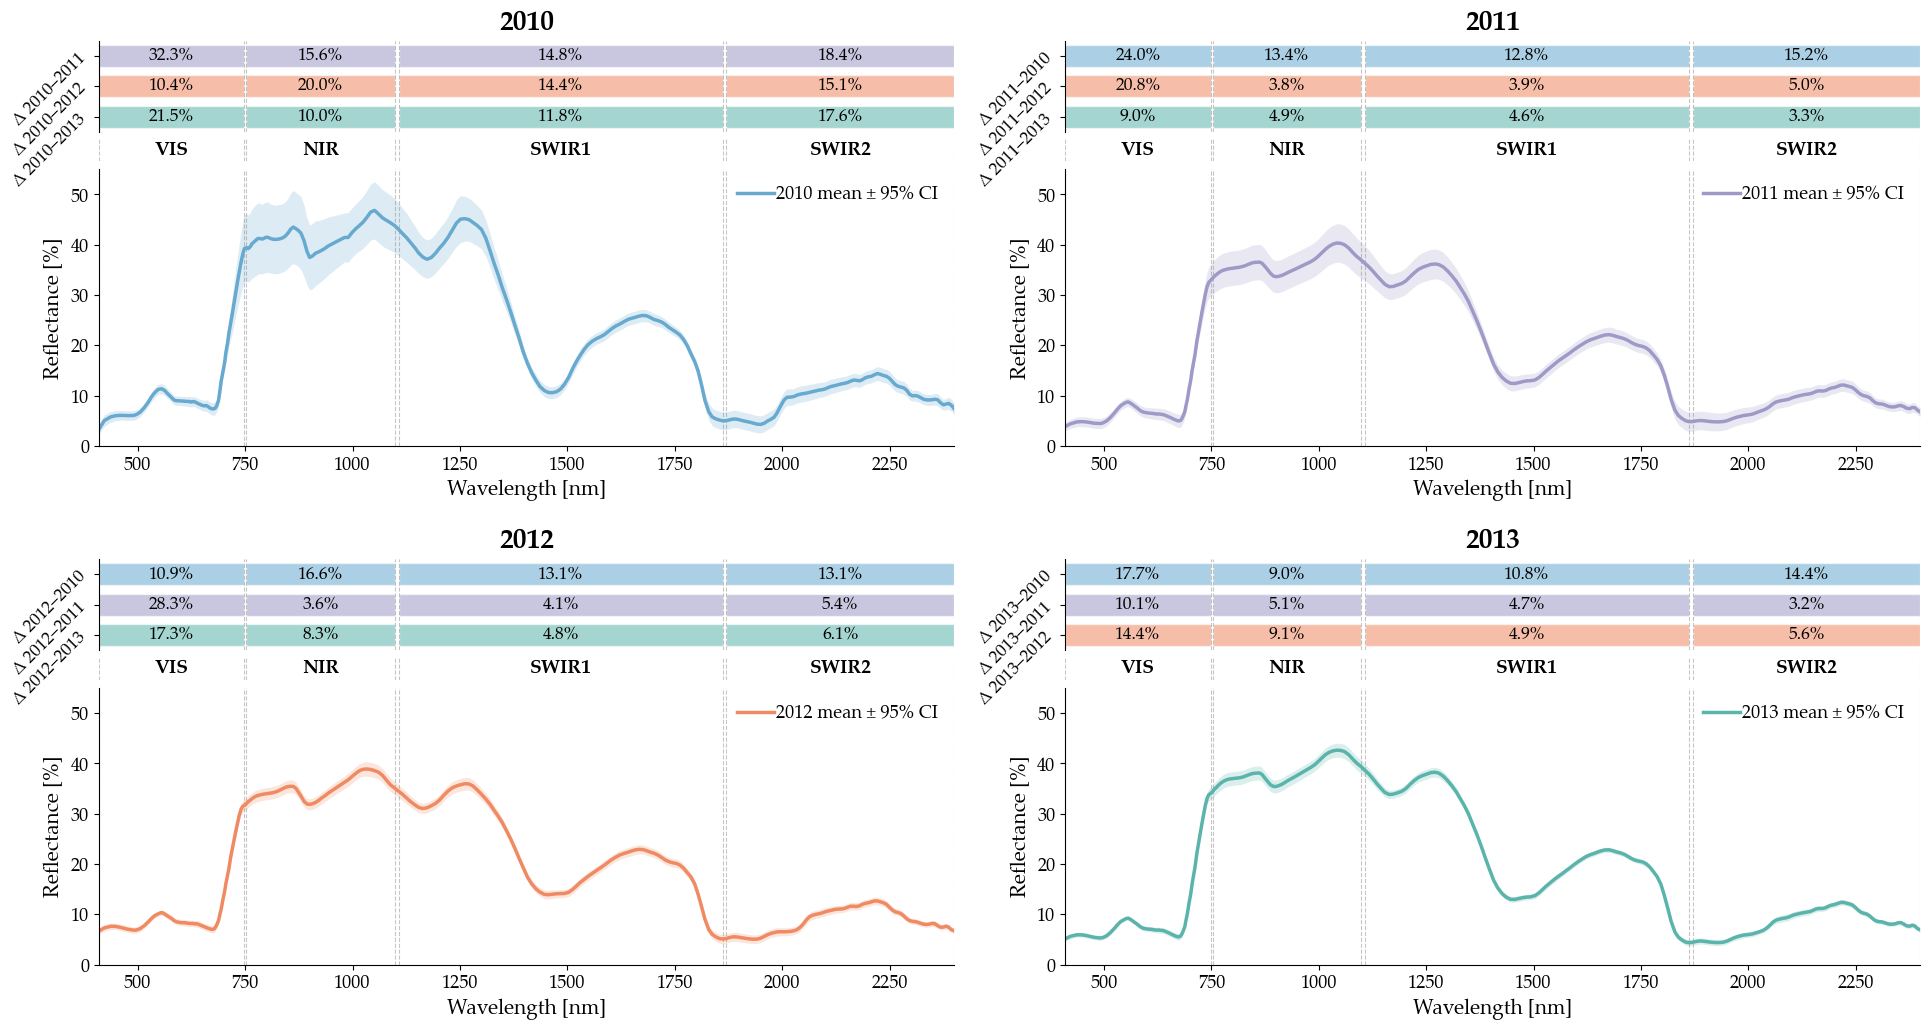

In [15]:
# ============================================================
# INPUT REFLECTANCE FIGURE — ALL YEARS GRID
# Each year panel:
# Top: regional % difference from other years
# Middle: spectral region labels
# Main: mean reflectance ± 95% CI
# ============================================================

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

FIGSIZE = (23.5, 12)

# -------------------------
# Dynamic Font sizes (your rule)
# -------------------------
base_size = 12
def rel(x): return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype","axes.titlesize": rel(1.6),"axes.labelsize": rel(1.6),
    "figure.titlesize": rel(1.6),"xtick.labelsize": rel(1.6),"ytick.labelsize": rel(1.2),
    "legend.fontsize": rel(1.2),"pdf.fonttype": 42,"ps.fonttype": 42,
})

def rel(x):
    return base_size * (x + 0.3)

YEAR_COLORS = {
    2010: "#67a9cf",
    2011: "#9e9ac8", # check https://colorbrewer2.org/ site for color blind friendly palette(s)
    2012: "#ef8a62",
    2013: "#5ab4ac",
}

YEARS = [2010, 2011, 2012, 2013]

REGION_BANDS = {
    "VIS":   (410, 748),
    "NIR":   (753, 1098),
    "SWIR1": (1107, 1862),
    "SWIR2": (1870, 2400),
}

region_order = ["VIS", "NIR", "SWIR1", "SWIR2"]

Input_FILES = {
    2010: "./input_data/No_Duplicates_Single-Year_Model_input_2010_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2011: "./input_data/No_Duplicates_Single-Year_Model_input_2011_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2012: "./input_data/No_Duplicates_Single-Year_Model_input_2012_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2013: "./input_data/No_Duplicates_Single-Year_Model_input_2013_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
}

dfs = {yr: pd.read_csv(path) for yr, path in Input_FILES.items()}

def get_reflectance_cols(df):
    cols = [c for c in df.columns if re.fullmatch(r"X\d+", str(c))]
    return sorted(cols, key=lambda x: int(x.replace("X", "")))

ref_cols = get_reflectance_cols(dfs[2010])
wavelengths = np.array([int(c.replace("X", "")) for c in ref_cols])

# Pre-compute yearly mean and CI
year_stats = {}

for yr in YEARS:
    X = dfs[yr][ref_cols].apply(pd.to_numeric, errors="coerce") / 100
    mean = X.mean(axis=0)
    se = X.sem(axis=0)
    ci95 = 1.96 * se

    year_stats[yr] = {
        "mean": mean,
        "ci95": ci95,
        "n": len(X)
    }

def draw_year_panel(fig, outer_spec, selected_year):

    subgs = outer_spec.subgridspec(
        nrows=3,
        ncols=1,
        height_ratios=[1.45, 0.35, 4.4],
        hspace=0.06
    )

    ax_top = fig.add_subplot(subgs[0, 0])
    ax_region = fig.add_subplot(subgs[1, 0], sharex=ax_top)
    ax_main = fig.add_subplot(subgs[2, 0], sharex=ax_top)

    mean_sel = year_stats[selected_year]["mean"]
    ci95_sel = year_stats[selected_year]["ci95"]

    # -------------------------
    # Regional mean absolute percentage difference
    #
    # For every wavelength:
    # |mean reflectance selected year - mean reflectance comparison year|
    # ------------------------------------------------------------------- × 100
    #              |mean reflectance comparison year|
    #
    # Wavelength-level percentage differences are then averaged
    # separately within VIS, NIR, SWIR1 and SWIR2.
    #
    # NOTE: This measure is directional because the comparison year
    # is used as the denominator.
    # -------------------------
    
    rows = []

    for comp_year in YEARS:

        if comp_year == selected_year:
            continue

        mean_comp = year_stats[comp_year]["mean"]

        pct_diff = ((mean_sel - mean_comp).abs() / mean_comp.abs()) * 100

        for reg, (x0, x1) in REGION_BANDS.items():

            mask = (wavelengths >= x0) & (wavelengths <= x1)

            rows.append({
                "Comparison_year": comp_year,
                "Region": reg,
                "Pct_diff": pct_diff[mask].mean()
            })

    diff_df = pd.DataFrame(rows)
    
    # NOTE:
    # Each displayed value is the mean absolute wavelength-wise percentage
    # difference within that spectral region, relative to the comparison-year
    # mean reflectance. VIS, NIR, SWIR1 and SWIR2 are calculated independently;
    # therefore, the four percentages are not proportions and do not sum to 100%.
    
    # print(
    # selected_year,
    # diff_df.groupby("Comparison_year")["Pct_diff"].sum()
    # )

    # -------------------------
    # Shared spectral boundaries
    # -------------------------
    for ax in [ax_top, ax_region, ax_main]:
        for reg, (x0, x1) in REGION_BANDS.items():
            ax.axvline(x0, color="grey", lw=0.8, ls="--", alpha=0.45)
            ax.axvline(x1, color="grey", lw=0.8, ls="--", alpha=0.45)

    # -------------------------
    # Top panel: regional % difference bars
    # -------------------------
    comparison_years = [yr for yr in YEARS if yr != selected_year]
    y_positions = np.arange(len(comparison_years))
    bar_height = 0.72

    for i, comp_year in enumerate(comparison_years):

        d_comp = diff_df[diff_df["Comparison_year"] == comp_year]

        for reg in region_order:

            d_reg = d_comp[d_comp["Region"] == reg]

            if d_reg.empty:
                continue

            pct = float(d_reg["Pct_diff"].iloc[0])
            x0, x1 = REGION_BANDS[reg]
            width = x1 - x0

            ax_top.barh(
                y=i,
                width=width,
                left=x0,
                height=bar_height,
                color=YEAR_COLORS[comp_year],
                alpha=0.55,
                edgecolor="white",
                linewidth=1.0
            )

            ax_top.text(
                x0 + width / 2,
                i,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=rel(0.75)
            )

    ax_top.set_yticks(y_positions)
    ax_top.set_yticklabels(
        [f"Δ {selected_year}–{yr}" for yr in comparison_years],
        fontsize=rel(0.75),
        rotation = 45
    )
    ax_top.invert_yaxis()
    ax_top.set_xlim(410, 2400)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

    ax_top.set_title(
        f"{selected_year}",
        fontsize=rel(1.35),
        fontweight="bold",
        pad=8
    )

    # -------------------------
    # Middle spectral-region labels
    # -------------------------
    ax_region.set_ylim(0, 1)
    ax_region.set_yticks([])

    for reg, (x0, x1) in REGION_BANDS.items():
        ax_region.text(
            (x0 + x1) / 2,
            0.5,
            reg,
            ha="center",
            va="center",
            fontsize=rel(0.85),
            fontweight="bold"
        )

    ax_region.tick_params(axis="x", bottom=False, labelbottom=False)

    # -------------------------
    # Main panel: mean reflectance ± CI
    # -------------------------
    color = YEAR_COLORS[selected_year]

    ax_main.plot(
        wavelengths,
        mean_sel.values,
        color=color,
        lw=2.5,
        label=f"{selected_year} mean ± 95% CI"
    )

    ax_main.fill_between(
        wavelengths,
        (mean_sel - ci95_sel).values,
        (mean_sel + ci95_sel).values,
        color=color,
        alpha=0.22, # 0.15
        linewidth=0
    )

    ax_main.set_xlim(410, 2400)
    ax_main.set_ylim(0, 55)
    ax_main.set_yticks(np.arange(0, 51, 10))
    ax_main.set_xlabel("Wavelength [nm]", fontsize=rel(0.95))
    ax_main.set_ylabel("Reflectance [%]", fontsize=rel(0.95))
    ax_main.tick_params(axis="both", labelsize=rel(0.8))

    ax_main.legend(
        frameon=False,
        loc="upper right",
        fontsize=rel(0.8),
        handletextpad=0.1 # move CI legend text to the right
    )

    # -------------------------
    # Styling
    # -------------------------
    for ax in [ax_top, ax_region, ax_main]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax_top.spines["bottom"].set_visible(False)
    ax_region.spines["left"].set_visible(False)
    ax_region.spines["bottom"].set_visible(False)
    ax_region.spines["top"].set_visible(False)

    return ax_top, ax_region, ax_main

# -------------------------
# Figure layout: 2 × 2 grid
# -------------------------
fig = plt.figure(figsize=FIGSIZE)

outer_gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    wspace=0.13, # Space in between grid columns
    hspace=0.28 # 0.26 Space in between grid rows
)

for idx, yr in enumerate(YEARS):

    row = idx // 2
    col = idx % 2

    draw_year_panel(
        fig=fig,
        outer_spec=outer_gs[row, col],
        selected_year=yr
    )

# fig.suptitle(
#     "Inter-annual differences in plot-level APEX reflectance spectra",
#     fontsize=rel(1.6),
#     fontweight="bold",
#     y=0.98
# )

plt.tight_layout(rect=[0, 0, 1, 0.965])

# # -------------------------
# # Save figure (PNG, 600 dpi & PDF)
# # -------------------------
# # pad_inches trims excess outer whitespace without altering any figure element(s)
# fig.savefig(output_path("PPR2_Revised_FIGURE_N_Avg_REF_with_CI_all_years.pdf"), bbox_inches="tight", pad_inches=0.05)
# fig.savefig(output_path("PPR2_Revised_FIGURE_N_Avg_REF_with_CI_all_years.png"), bbox_inches="tight", pad_inches=0.05, dpi=600)

plt.show()

In [16]:
### Step 9 — Spectral region aggregation (interpretability)
# ============================================================
# Groups the Top-30 stable VIP wavelengths into 25-nm bins
# for each calibration Year × Trait.
#
# Creates:
#   region_summary
#
# Higher stability_score_sum indicates that more of the stable
# VIP signal is concentrated in that spectral interval.
#
# No manuscript-quality filters are applied here.
# ============================================================

BIN_WIDTH = 25

# ------------------------------------------------------------
# 1. Assign Top-30 wavelengths to 25-nm spectral bins
# ------------------------------------------------------------

vip_top30_df = vip_top30_df.copy()

vip_top30_df["region_start"] = (
    vip_top30_df["wavelength"] // BIN_WIDTH
) * BIN_WIDTH

vip_top30_df["region_end"] = (
    vip_top30_df["region_start"] + BIN_WIDTH - 1
)

vip_top30_df["region"] = (
    vip_top30_df["region_start"].astype(int).astype(str) +
    "-" +
    vip_top30_df["region_end"].astype(int).astype(str)
)

# ------------------------------------------------------------
# 2. Summarize each 25-nm region per Year × Trait
# ------------------------------------------------------------

region_summary = (
    vip_top30_df
    .groupby(
        [
            "Year",
            "inVar",
            "region",
            "Valid_Iter",
            "Iter_R2_iqr",
            "Pass_Valid_Iter"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        n_wvl=("wavelength", "count"),
        vip_mean_avg=("vip_mean", "mean"),
        vip_gt1_pct_avg=("vip_gt1_pct", "mean"),
        vip_cv_avg=("vip_cv", "mean"),
        stability_score_avg=("stability_score", "mean"),
        stability_score_sum=("stability_score", "sum")
    )
)

# ------------------------------------------------------------
# 3. Rank spectral regions within each Year × Trait
# ------------------------------------------------------------

region_summary["region_rank"] = (
    region_summary
    .groupby(["Year", "inVar"])["stability_score_sum"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

# ------------------------------------------------------------
# 4. Standardize Year labels
# ------------------------------------------------------------

region_summary["Year"] = (
    region_summary["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

# ------------------------------------------------------------
# 5. Sort and inspect
# ------------------------------------------------------------

region_summary = (
    region_summary
    .sort_values(
        ["Year", "inVar", "region_rank"]
    )
    .reset_index(drop=True)
)

print(
    "Year × Trait models represented:",
    region_summary[["Year", "inVar"]]
    .drop_duplicates()
    .shape[0]
)

print(
    "Spectral-region rows:",
    len(region_summary)
)

region_summary[[
    "Year",
    "inVar",
    "region",
    "region_rank",
    "n_wvl",
    "vip_mean_avg",
    "vip_gt1_pct_avg",
    "vip_cv_avg",
    "stability_score_sum",
    "Valid_Iter",
    "Iter_R2_iqr",
    "Pass_Valid_Iter"
]].head(15)

Year × Trait models represented: 93
Spectral-region rows: 1119


,Year,inVar,region,region_rank,n_wvl,vip_mean_avg,vip_gt1_pct_avg,vip_cv_avg,stability_score_sum,Valid_Iter,Iter_R2_iqr,Pass_Valid_Iter
0,2010,ADF_perc,725-749,1,5,1.2242,100.0000,0.0442,7.4909,3,0.2501,False
1,2010,ADF_perc,850-874,2,4,1.5040,100.0000,0.0436,6.6087,3,0.2501,False
2,2010,ADF_perc,825-849,3,4,1.4723,100.0000,0.0449,6.4493,3,0.2501,False
3,2010,ADF_perc,875-899,4,3,1.5079,100.0000,0.0246,5.3351,3,0.2501,False
4,2010,ADF_perc,900-924,5,3,1.3946,100.0000,0.0288,5.0779,3,0.2501,False
5,2010,ADF_perc,1050-1074,6,3,1.1653,100.0000,0.0347,4.6431,3,0.2501,False
6,2010,ADF_perc,800-824,7,2,1.4088,100.0000,0.0452,3.1630,3,0.2501,False
7,2010,ADF_perc,750-774,8,2,1.3313,100.0000,0.0484,2.9891,3,0.2501,False
8,2010,ADF_perc,1250-1274,9,1,1.6238,100.0000,0.0493,1.5960,3,0.2501,False
9,2010,ADF_perc,2000-2024,10,1,1.0971,100.0000,0.0335,1.5417,3,0.2501,False


In [17]:
# ============================================================
# Step 9b — Top spectral regions per Year × Trait
# ============================================================
# Retains the TOP_K_REGIONS highest-ranked 25-nm regions
# for each calibration Year × Trait.
#
# Input:
#   region_summary
#
# Output:
#   top_regions
# ============================================================

TOP_K_REGIONS = 5

top_regions = (
    region_summary
    .sort_values(["Year", "inVar", "region_rank"])
    .groupby(["Year", "inVar"], group_keys=False)
    .head(TOP_K_REGIONS)
    .reset_index(drop=True)
)

# Safety check: no model should have more than TOP_K_REGIONS rows
check_top_regions = (
    top_regions
    .groupby(["Year", "inVar"])
    .size()
)

if check_top_regions.max() > TOP_K_REGIONS:
    raise RuntimeError("More than TOP_K_REGIONS retained for at least one model.")

print(
    "Year × Trait models represented:",
    top_regions[["Year", "inVar"]]
    .drop_duplicates()
    .shape[0]
)

top_regions[[
    "Year",
    "inVar",
    "region",
    "region_rank",
    "n_wvl",
    "vip_mean_avg",
    "vip_gt1_pct_avg",
    "vip_cv_avg",
    "stability_score_sum",
    "Valid_Iter",
    "Iter_R2_iqr",
    "Pass_Valid_Iter"
]].head(10)

Year × Trait models represented: 93


,Year,inVar,region,region_rank,n_wvl,vip_mean_avg,vip_gt1_pct_avg,vip_cv_avg,stability_score_sum,Valid_Iter,Iter_R2_iqr,Pass_Valid_Iter
0,2010,ADF_perc,725-749,1,5,1.2242,100.0000,0.0442,7.4909,3,0.2501,False
1,2010,ADF_perc,850-874,2,4,1.5040,100.0000,0.0436,6.6087,3,0.2501,False
2,2010,ADF_perc,825-849,3,4,1.4723,100.0000,0.0449,6.4493,3,0.2501,False
3,2010,ADF_perc,875-899,4,3,1.5079,100.0000,0.0246,5.3351,3,0.2501,False
4,2010,ADF_perc,900-924,5,3,1.3946,100.0000,0.0288,5.0779,3,0.2501,False
5,2010,ADL_perc,775-799,1,5,1.9539,100.0000,0.1425,8.3116,9,0.0715,False
6,2010,ADL_perc,875-899,2,3,2.0157,100.0000,0.1413,5.0435,9,0.0715,False
7,2010,ADL_perc,1050-1074,3,3,1.5823,100.0000,0.1121,5.0036,9,0.0715,False
8,2010,ADL_perc,1000-1024,4,3,1.4106,100.0000,0.0990,4.9746,9,0.0715,False
9,2010,ADL_perc,800-824,5,3,1.9182,100.0000,0.1413,4.9601,9,0.0715,False


In [18]:
### Step 10 — Cross-year spectral region consensus
# ============================================================
# Identifies 25-nm spectral regions that repeatedly occur among
# the Top-K stable regions for the same trait across calibration
# models/years.
#
# Input:
#   top_regions
#
# Output:
#   trait_region_consensus
#
# IMPORTANT:
# No Valid_Iter or Iter_R2_iqr filtering is applied here.
# Model-quality information is summarized and retained so that
# manuscript-specific filtering can be applied later.
# ============================================================

# ------------------------------------------------------------
# 1. Cross-model consensus per Trait × spectral region
# ------------------------------------------------------------

trait_region_consensus = (
    top_regions
    .groupby(["inVar", "region"], as_index=False)
    .agg(
        # Recurrence across calibration models
        n_models=("Year", "nunique"),
        years_list=("Year", lambda s: ", ".join(
            sorted(set(map(str, s)))
        )),

        # Overall importance/stability
        total_stability=("stability_score_sum", "sum"),
        mean_stability=("stability_score_sum", "mean"),
        min_stability=("stability_score_sum", "min"),
        max_stability=("stability_score_sum", "max"),

        # VIP characteristics
        mean_vip=("vip_mean_avg", "mean"),
        mean_vip_gt1_pct=("vip_gt1_pct_avg", "mean"),
        mean_cv=("vip_cv_avg", "mean"),

        # Number of Top-30 wavelengths represented
        total_n_wvl=("n_wvl", "sum"),
        mean_n_wvl=("n_wvl", "mean"),

        # Model-quality information
        min_Valid_Iter=("Valid_Iter", "min"),
        max_Valid_Iter=("Valid_Iter", "max"),
        mean_Valid_Iter=("Valid_Iter", "mean"),

        min_Iter_R2_iqr=("Iter_R2_iqr", "min"),
        max_Iter_R2_iqr=("Iter_R2_iqr", "max"),
        mean_Iter_R2_iqr=("Iter_R2_iqr", "mean"),

        n_models_passing_Valid_Iter=(
            "Pass_Valid_Iter",
            "sum"
        )
    )
)

# ------------------------------------------------------------
# 2. Keep recurrent regions
#
# A consensus region must occur among the Top-K regions of at
# least two distinct calibration models.
# ------------------------------------------------------------

trait_region_consensus = (
    trait_region_consensus
    .query("n_models >= 2")
    .copy()
)

# Proportion of contributing models that pass Valid_Iter >= 700
trait_region_consensus["pct_models_passing_Valid_Iter"] = (
    100 *
    trait_region_consensus["n_models_passing_Valid_Iter"] /
    trait_region_consensus["n_models"]
)

# ------------------------------------------------------------
# 3. Rank recurrent regions within each trait
#
# Priority:
#   1. recurrence across more calibration models
#   2. greater total stability
# ------------------------------------------------------------

trait_region_consensus = (
    trait_region_consensus
    .sort_values(
        ["inVar", "n_models", "total_stability"],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

trait_region_consensus["consensus_rank"] = (
    trait_region_consensus
    .groupby("inVar")
    .cumcount() + 1
)

# ------------------------------------------------------------
# 4. Safety / audit checks
# ------------------------------------------------------------

print(
    "Traits represented:",
    trait_region_consensus["inVar"].nunique()
)

print(
    "Recurrent Trait × spectral-region combinations:",
    len(trait_region_consensus)
)

print(
    "Maximum number of calibration models supporting one region:",
    trait_region_consensus["n_models"].max()
    if len(trait_region_consensus) > 0 else 0
)

# Check that all retained consensus regions have support >= 2
assert (
    trait_region_consensus["n_models"] >= 2
).all(), "Consensus table contains a region supported by fewer than 2 models."

# ------------------------------------------------------------
# 5. Inspect
# ------------------------------------------------------------

trait_region_consensus[[
    "inVar",
    "region",
    "consensus_rank",
    "n_models",
    "years_list",
    "total_n_wvl",
    "total_stability",
    "mean_stability",
    "min_stability",
    "max_stability",
    "mean_vip",
    "mean_vip_gt1_pct",
    "mean_cv",
    "min_Valid_Iter",
    "mean_Valid_Iter",
    "max_Valid_Iter",
    "mean_Iter_R2_iqr",
    "n_models_passing_Valid_Iter",
    "pct_models_passing_Valid_Iter"
]].head(5)

Traits represented: 7
Recurrent Trait × spectral-region combinations: 103
Maximum number of calibration models supporting one region: 10


,inVar,region,consensus_rank,n_models,years_list,total_n_wvl,total_stability,mean_stability,min_stability,max_stability,mean_vip,mean_vip_gt1_pct,mean_cv,min_Valid_Iter,mean_Valid_Iter,max_Valid_Iter,mean_Iter_R2_iqr,n_models_passing_Valid_Iter,pct_models_passing_Valid_Iter
0,ADF_perc,825-849,1,5,"2010, 2010-2011-2013, 2010-2012-2013, 2010-201...",19,30.9221,6.1844,4.2083,6.8768,1.3573,95.4419,0.0989,3,384.8000,997,0.2508,1,20.0000
1,ADF_perc,850-874,2,4,"2010, 2010-2011-2013, 2010-2013, 2011",16,25.8116,6.4529,4.7953,8.2264,1.4584,99.5040,0.1185,3,231.7500,495,0.2936,0,0.0000
2,ADF_perc,1825-1849,3,4,"2011-2012, 2011-2012-2013, 2012, 2012-2013",12,19.4040,4.8510,4.1522,5.3370,1.2848,89.2619,0.1368,61,580.0000,1000,0.1554,2,50.0000
3,ADF_perc,1425-1449,4,4,"2010-2011-2012, 2010-2011-2013, 2010-2012, 2012",12,18.8786,4.7197,4.5634,4.8551,1.1705,86.4689,0.1368,114,247.7500,422,0.2167,0,0.0000
4,ADF_perc,1900-1924,5,4,"2010-2012-2013, 2011-2012, 2011-2012-2013, 201...",12,18.6014,4.6504,4.1522,4.8949,1.1432,90.8441,0.0896,61,764.5000,1000,0.1033,3,75.0000


In [19]:
# Step 10b — Attach Top-5 spectral regions to all_stats

top5_regions = (
    top_regions
    .sort_values(["Year", "inVar", "region_rank"])
    .groupby(["Year", "inVar"])["region"]
    .apply(lambda s: list(dict.fromkeys(s.astype(str)))[:5])
    .reset_index(name="Top5_regions")
)

assert not top5_regions.duplicated(["Year", "inVar"]).any()
assert top5_regions["Top5_regions"].apply(len).le(5).all()

all_stats = all_stats.drop(columns=["Top5_regions"], errors="ignore")

all_stats = all_stats.merge(
    top5_regions,
    on=["Year", "inVar"],
    how="left",
    validate="one_to_one"
)

all_stats["Top5_regions"] = all_stats["Top5_regions"].apply(
    lambda x: x if isinstance(x, list) else []
)

print("Models in all_stats:", len(all_stats))
print("Models with Top-5 spectral regions:",
      all_stats["Top5_regions"].apply(len).gt(0).sum())

check_cols = [c for c in [
    "Year", "inVar", "Valid_Iter", "Iter_R2_iqr", "Top5_regions"
] if c in all_stats.columns]

all_stats[check_cols].head(15)

Models in all_stats: 93
Models with Top-5 spectral regions: 93


,Year,inVar,Valid_Iter,Iter_R2_iqr,Top5_regions
0,2010,ADF_perc,3,0.2501,"[725-749, 850-874, 825-849, 875-899, 900-924]"
1,2011,ADF_perc,7,0.3855,"[850-874, 775-799, 800-824, 750-774, 825-849]"
2,2012,ADF_perc,259,0.2877,"[750-774, 1425-1449, 1825-1849, 1400-1424, 107..."
3,2013,ADF_perc,804,0.1763,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1..."
4,2010-2012,ADF_perc,196,0.2404,"[1000-1024, 1250-1274, 1200-1224, 1425-1449, 1..."
5,2010-2013,ADF_perc,495,0.2933,"[825-849, 850-874, 875-899, 900-924, 725-749]"
6,2011-2012,ADF_perc,61,0.0930,"[1800-1824, 1850-1874, 1900-1924, 1825-1849, 1..."
7,2011-2013,ADF_perc,707,0.1972,"[1775-1799, 1675-1699, 1750-1774, 1625-1649, 2..."
8,2012-2013,ADF_perc,1000,0.1326,"[1825-1849, 1900-1924, 1875-1899, 2000-2024, 7..."
9,2010-2011-2012,ADF_perc,114,0.0933,"[1000-1024, 1050-1074, 1200-1224, 975-999, 142..."


In [20]:
### Step 12 — Spectral support summary

MIN_MODELS_SUPPORT = 2

region_support = (
    trait_region_consensus
    .query("n_models >= @MIN_MODELS_SUPPORT")
    .copy()
    .sort_values(["inVar", "n_models", "total_stability"],
                 ascending=[True, False, False])
    .reset_index(drop=True)
)

print("Recurrent Trait × region combinations:", len(region_support))
print("Traits with recurrent spectral support:", region_support["inVar"].nunique())

region_support[[
    "inVar", "region", "consensus_rank",
    "n_models", "years_list",
    "total_stability", "mean_vip", "mean_cv",
    "min_Valid_Iter", "mean_Iter_R2_iqr"
]].head(20)

# Keep source_path as the final column if it exists
if "source_path" in all_stats.columns:
    all_stats = all_stats[
        [c for c in all_stats.columns if c != "source_path"] + ["source_path"]
    ]

# all_stats.head()
all_stats.loc[:, ~all_stats.columns.str.contains("source", case=False)].head()

Recurrent Trait × region combinations: 103
Traits with recurrent spectral support: 7


,Year,inVar,Run_Date,Valid_Iter,Cal_N,Cal_Observed_Mean,Cal_Predicted_Mean,Cal_Observed_SD,Cal_Predicted_SD,Cal_Observed_Min,Cal_Observed_Max,Cal_Observed_Range,Cal_Residual_R2,Cal_Pearson_r,Cal_Spearman_rho,Cal_R2_regression,Cal_Adjusted_R2_regression,Cal_Regression_Intercept,Cal_Regression_Slope,Cal_Bias_Predicted_minus_Observed,Cal_MAE,Cal_MSE,Cal_RMSEP,Cal_nRMSEP_SD_percent,Cal_nRMSEP_Range_percent,Cal_PRESS_SSE,Cal_SST,Cal_Squared_Bias_Component,Cal_Unequal_Variance_Component,Cal_Incomplete_Correlation_Component,Cal_Squared_Bias_Percent_MSE,Cal_Unequal_Variance_Percent_MSE,Cal_Incomplete_Correlation_Percent_MSE,Cal_Decomposition_Sum,Cal_Decomposition_Difference_from_MSE,Val_N,Val_Observed_Mean,Val_Predicted_Mean,Val_Observed_SD,Val_Predicted_SD,Val_Observed_Min,Val_Observed_Max,Val_Observed_Range,Val_Residual_R2,Val_Pearson_r,Val_Spearman_rho,Val_R2_regression,Val_Adjusted_R2_regression,Val_Regression_Intercept,Val_Regression_Slope,Val_Bias_Predicted_minus_Observed,Val_MAE,Val_MSE,Val_RMSEP,Val_nRMSEP_SD_percent,Val_nRMSEP_Range_percent,Val_PRESS_SSE,Val_SST,Val_Squared_Bias_Component,Val_Unequal_Variance_Component,Val_Incomplete_Correlation_Component,Val_Squared_Bias_Percent_MSE,Val_Unequal_Variance_Percent_MSE,Val_Incomplete_Correlation_Percent_MSE,Val_Decomposition_Sum,Val_Decomposition_Difference_from_MSE,Cal_R2,Val_R2,R2_gap,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,Year_int,Img_acq_date,AGDD,AGDD_int_avg,AGDD_min,AGDD_max,AGDD_range,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,Top5_regions
0,2010,ADF_perc,2026-08-05,3,25,28.1672,28.2557,3.9181,3.2316,21.5467,35.6820,14.1353,0.8143,0.9063,0.9208,0.8214,0.8137,7.2000,0.7475,0.0884,1.3095,2.7375,1.6545,42.2278,11.7050,68.4377,368.4430,0.0078,0.4525,2.2772,0.2857,16.5284,83.1859,2.7375,0,10,27.9101,32.2887,5.5230,6.2674,21.5467,35.6820,14.1353,-3.4639,-0.6512,-0.5636,0.4240,0.3520,52.9122,-0.7389,4.3786,8.6453,122.5473,11.0701,200.4382,78.3152,1225.4735,274.5271,19.1718,0.4987,102.8768,15.6444,0.4070,83.9486,122.5473,0,0.8143,-3.4639,4.2782,0.2501,0.2878,3,66.6667,6,2010,20100624,225.1,225.1000,225.1000,225.1000,0.0000,14.2,52.2,early,Single_Year,"[725-749, 850-874, 825-849, 875-899, 900-924]"
1,2011,ADF_perc,2026-08-05,7,16,29.6612,29.5696,3.3790,2.0668,23.6597,34.2817,10.6220,0.5731,0.7749,0.8088,0.6005,0.5720,15.5106,0.4740,-0.0916,1.8180,4.5699,2.1377,63.2644,20.1255,73.1182,171.2684,0.0084,1.6144,2.9471,0.1837,35.3275,64.4888,4.5699,0,10,30.8294,28.8966,2.7607,4.9032,26.5847,34.4070,7.8223,-4.5270,-0.2331,-0.4545,0.0543,-0.0639,41.6603,-0.4140,-1.9328,5.2035,37.9124,6.1573,223.0310,78.7144,379.1238,68.5951,3.7359,4.1311,30.0454,9.8540,10.8964,79.2496,37.9124,0,0.5731,-4.5270,5.1001,0.3855,0.2341,1,57.1429,2,2011,20110626,319.8,319.8000,319.8000,319.8000,0.0000,17.6,141.5,late,Single_Year,"[850-874, 775-799, 800-824, 750-774, 825-849]"
2,2012,ADF_perc,2026-08-05,259,75,29.4930,29.5439,2.8810,1.7592,23.4583,37.2373,13.7790,0.6847,0.8662,0.8657,0.7504,0.7470,13.9433,0.5290,0.0508,1.2168,2.5818,1.6068,55.7734,11.6613,193.6374,614.1945,0.0026,1.2416,1.3377,0.1001,48.0888,51.8111,2.5818,0,75,29.4930,29.4700,2.8810,1.6405,23.4583,37.2373,13.7790,0.3737,0.6129,0.6626,0.3756,0.3671,19.1769,0.3490,-0.0231,1.7369,5.1291,2.2648,78.6112,16.4363,384.6846,614.1945,0.0005,1.5182,3.6104,0.0104,29.5987,70.3909,5.1291,0,0.6847,0.3737,0.3111,0.2877,0.1561,1,17.3745,19,2012,20120629,333.3,333.3000,333.3000,333.3000,0.0000,19.6,132.7,late,Single_Year,"[750-774, 1425-1449, 1825-1849, 1400-1424, 107..."
3,2013,ADF_perc,2026-08-05,804,100,28.5635,28.5717,3.2774,1.8614,22.0123,44.1906,22.1783,0.4682,0.6962,0.6151,0.4847,0.4794,17.2776,0.3954,0.0082,1.7178,5.6547,2.3780,72.5562,10.7221,565.4746,1063.4065,0.0001,1.9851,3.6696,0.0012,35.1052,64.8936,5.6547,0,100,28.5635,28.5168,3.2774,1.8785,22.0123,44.1906,22.1783,0.0967,0.3711,0.4340,0.1377,0.1289,22.4407,0.2127,-0.0466,1.9724,9.6056,3.0993,94.5648,13.9744,960.5576,1063.4065,0.0022,1.9374,7.6660,0.0226

### Table 2 After Revisions ###

In [22]:
# 700-iteration threshold

import os
import numpy as np
import pandas as pd

# -------------------------
# Dynamic Font sizes
# -------------------------
base_size = 12

def rel(x):
    return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype",
    "axes.titlesize": rel(1.5),
    "axes.labelsize": rel(1.3),
    "xtick.labelsize": rel(1),
    "ytick.labelsize": rel(1),
    "legend.fontsize": rel(1),
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

trait_labels = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%"
}

# Single-year within-year models only
single_year_stats = all_stats.loc[
    all_stats["Year"].astype(str).str.fullmatch(r"\d{4}", na=False)
].copy()

single_year_stats["Model_Status"] = np.where(
    pd.to_numeric(single_year_stats["Valid_Iter"], errors="coerce") >= 700,
    "Convergent",
    "Non-convergent (<700 valid iterations)"
)

single_year_stats["Trait"] = single_year_stats["inVar"].replace(trait_labels)

# ============================================================
# Main-body Table 2: convergent within-year models only
# ============================================================

table2 = (
    single_year_stats.loc[
        pd.to_numeric(single_year_stats["Valid_Iter"], errors="coerce") >= 700
    ]
    .rename(columns={
        "Cal_N": "Cal. N",
        "Val_N": "Val. N",
        "Val_Residual_R2": "R²",
        "Val_RMSEP": "RMSEP",
        "Val_nRMSEP_SD_percent": "nRMSEP_SD (%)",
        "Val_Bias_Predicted_minus_Observed": "Bias",
        "Val_Pearson_r": "Pearson r",
        "Val_Regression_Slope": "Regression slope",
        "Iter_R2_iqr": "R² IQR",
        "Valid_Iter": "Valid iterations",
        "Iter_nComps_mode": "nComps mode",
        "Iter_nComps_mode_pct": "Dominant nComp (%)"
    })[
        [
            "Year", "Trait", "Cal. N", "Val. N",
            "R²", "RMSEP", "nRMSEP_SD (%)", "Bias",
            "Pearson r", "Regression slope", "R² IQR",
            "Valid iterations", "nComps mode", "Dominant nComp (%)"
        ]
    ]
    .sort_values(["Year", "Trait"])
    .reset_index(drop=True)
)

# ============================================================
# Appendix Table 1: all attempted within-year models
# ============================================================

appendix_s1 = (
    single_year_stats
    .rename(columns={
        "Model_Status": "Model status",
        "Cal_N": "Cal. N",
        "Val_N": "Val. N",
        "Val_Residual_R2": "R²",
        "Val_RMSEP": "RMSEP",
        "Val_nRMSEP_SD_percent": "nRMSEP_SD (%)",
        "Val_nRMSEP_Range_percent": "nRMSEP_Range (%)",
        "Val_Bias_Predicted_minus_Observed": "Bias",
        "Val_Pearson_r": "Pearson r",
        "Val_Spearman_rho": "Spearman rho",
        "Val_Regression_Intercept": "Regression intercept",
        "Val_Regression_Slope": "Regression slope",
        "Iter_R2_iqr": "R² IQR",
        "Valid_Iter": "Valid iterations",
        "Iter_nComps_mode": "nComps mode",
        "Iter_nComps_mode_pct": "Dominant nComp (%)"
    })[
        [
            "Year", "Trait", "Cal. N", "Val. N", "Model status",
            "R²", "RMSEP", "nRMSEP_SD (%)", "nRMSEP_Range (%)",
            "Bias", "Pearson r", "Spearman rho",
            "Regression intercept", "Regression slope",
            "R² IQR", "Valid iterations",
            "nComps mode", "Dominant nComp (%)"
        ]
    ]
    .sort_values(["Year", "Trait"])
    .reset_index(drop=True)
)

# -------------------------
# Rounding
# -------------------------

table2_rounding = {
    "R²": 2,
    "RMSEP": 2,
    "nRMSEP_SD (%)": 1,
    "Bias": 2,
    "Pearson r": 2,
    "Regression slope": 2,
    "R² IQR": 2,
    "Dominant nComp (%)": 1
}

appendix_rounding = {
    "R²": 3,
    "RMSEP": 3,
    "nRMSEP_SD (%)": 1,
    "nRMSEP_Range (%)": 1,
    "Bias": 3,
    "Pearson r": 3,
    "Spearman rho": 3,
    "Regression intercept": 3,
    "Regression slope": 3,
    "R² IQR": 3,
    "Dominant nComp (%)": 1
}

for col, decimals in table2_rounding.items():
    table2[col] = pd.to_numeric(table2[col], errors="coerce").round(decimals)

for col, decimals in appendix_rounding.items():
    appendix_s1[col] = pd.to_numeric(
        appendix_s1[col], errors="coerce"
    ).round(decimals)

# -------------------------
# Optional sanity checks
# -------------------------

print("Missing Cal. N in Table 2:", table2["Cal. N"].isna().sum())
print("Missing Val. N in Table 2:", table2["Val. N"].isna().sum())

print("Missing Cal. N in Appendix Table 1:", appendix_s1["Cal. N"].isna().sum())
print("Missing Val. N in Appendix Table 1:", appendix_s1["Val. N"].isna().sum())

# -------------------------
# SAVE TABLES
# -------------------------
# table2.to_csv(output_path("PPR2_Revised_MAIN_Table-2_WithinYear_Convergent.csv"), index=False, encoding="utf-8-sig")
# appendix_s1.to_csv(output_path("PPR2_Revised_Appendix_Table_S1_WithinYear_All.csv"), index=False, encoding="utf-8-sig")

print("\nTable 2:")
print(table2.to_string(index=False))
print("\nAppendix Table 1:")
print(appendix_s1.to_string(index=False))
print("\nChecks:")
print("Single-year combinations:", len(single_year_stats))
print("Convergent:",(pd.to_numeric(single_year_stats["Valid_Iter"], errors="coerce") >= 700).sum())
print("Non-convergent:",(pd.to_numeric(single_year_stats["Valid_Iter"], errors="coerce") < 700).sum())

Missing Cal. N in Table 2: 0
Missing Val. N in Table 2: 0
Missing Cal. N in Appendix Table 1: 0
Missing Val. N in Appendix Table 1: 0

Table 2:
Year             Trait  Cal. N  Val. N     R²    RMSEP  nRMSEP_SD (%)     Bias  Pearson r  Regression slope  R² IQR  Valid iterations  nComps mode  Dominant nComp (%)
2010 Fresh AGB (g m⁻²)      25      25 0.2200 229.0200        86.3000  13.1800     0.5500            0.4500  0.3000               847            1             63.2000
2012              ADL%      75      75 0.1400   1.8900        92.0000   0.0400     0.4100            0.2300  0.0700               928            4             28.0000
2012   Dry AGB (g m⁻²)      75      75 0.1700  72.2900        90.8000  -3.5400     0.4300            0.2300  0.1200               910            3             72.1000
2012 Fresh AGB (g m⁻²)      76      76 0.4600 197.9000        73.3000 -13.9400     0.6800            0.4700  0.0700               870            3             74.0000
2012                N

In [24]:
# ============================================================
# CROSS-YEAR REPRESENTATIVENESS — reusable helper
#
# Purpose:
# Quantify how different the measured trait distribution in a
# TARGET year is from the measured trait distribution represented
# by the CALIBRATION year(s).
#
# IMPORTANT:
# This replaces the old internal calibration-vs-validation diagnostic.
# Do NOT calculate these metrics from ensemble-cal / ensemble-val files.
#
# These metrics will later be applied to each actual
# calibration Year(s) → target Year transfer case.
#
# Interpretation:
# mean_shift_sd
#   = |target mean - calibration mean| / calibration SD
#   Smaller = more similar trait means.
#
# range_overlap_pct_cal
#   = overlapping cal/target range / calibration range
#   Higher = greater calibration-target range overlap.
#   1 = complete calibration-range overlap; 0 = no overlap.
#
# range_shift_ratio
#   = target range / calibration range
#   ~1 = similar spread; >1 = broader target distribution;
#   <1 = narrower target distribution.
# ============================================================

def distribution_shift_metrics(cal_y, target_y):
    cal_y = pd.to_numeric(pd.Series(cal_y), errors="coerce").dropna().to_numpy()
    target_y = pd.to_numeric(pd.Series(target_y), errors="coerce").dropna().to_numpy()

    if len(cal_y) < 2 or len(target_y) < 2:
        return {"mean_shift_sd":np.nan, "range_overlap_pct_cal":np.nan,
                "range_shift_ratio":np.nan}

    cal_mean, target_mean = cal_y.mean(), target_y.mean()
    cal_sd = cal_y.std(ddof=1)
    cal_min, cal_max = cal_y.min(), cal_y.max()
    target_min, target_max = target_y.min(), target_y.max()
    cal_range, target_range = cal_max-cal_min, target_max-target_min
    overlap = max(0, min(cal_max,target_max)-max(cal_min,target_min))

    return {
        "mean_shift_sd": abs(target_mean-cal_mean)/cal_sd if cal_sd > 0 else np.nan,
        "range_overlap_pct_cal": overlap/cal_range if cal_range > 0 else np.nan,
        "range_shift_ratio": target_range/cal_range if cal_range > 0 else np.nan
    }

In [25]:
# ============================================================
# CONVERGENCE-FILTER AUDIT
#
# Purpose:
# Document exactly which calibration Year × Trait models are
# retained or excluded by the convergence criterion.
#
# Convergence criterion:
# Valid_Iter >= 700 -> Retained
# Valid_Iter < 700  -> Excluded
#
# IMPORTANT:
# Run from all_stats BEFORE filtering to retained models.
# This audit does NOT remove anything from all_stats.
# ============================================================

conv_audit = all_stats.copy()
conv_audit["Valid_Iter"] = pd.to_numeric(conv_audit["Valid_Iter"], errors="coerce")
conv_audit["Calibration_Years"] = conv_audit["Year"].astype(str).str.replace("&","-",regex=False)
conv_audit["Calibration_Type"] = np.where(
    conv_audit["Calibration_Years"].str.contains("-",regex=False),
    "Multi-year","Single-year"
)
conv_audit["Convergence_Status"] = np.select(
    [conv_audit["Valid_Iter"] >= 700, conv_audit["Valid_Iter"] < 700],
    ["Retained","Excluded (<700)"],
    default="Missing Valid_Iter"
)

# One row per calibration Year × Trait model
conv_audit = (
    conv_audit[[
        "Calibration_Years","inVar","Calibration_Type","Valid_Iter",
        "Convergence_Status","Iter_R2_iqr","Iter_R2_sd",
        "Iter_nComps_mode","Iter_nComps_mode_pct","Iter_nComps_range"
    ]]
    .drop_duplicates(["Calibration_Years","inVar"])
    .rename(columns={"inVar":"Trait"})
    .sort_values(["Calibration_Type","Calibration_Years","Trait"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 1) Overall audit by calibration design
# ------------------------------------------------------------

conv_by_type = (
    conv_audit
    .groupby(["Calibration_Type","Convergence_Status"])
    .size().unstack(fill_value=0)
)

for c in ["Retained","Excluded (<700)","Missing Valid_Iter"]:
    if c not in conv_by_type.columns: conv_by_type[c] = 0

conv_by_type["Total"] = conv_by_type[
    ["Retained","Excluded (<700)","Missing Valid_Iter"]
].sum(axis=1)
conv_by_type["Retained_pct"] = 100*conv_by_type["Retained"]/conv_by_type["Total"]
conv_by_type["Excluded_pct"] = 100*conv_by_type["Excluded (<700)"]/conv_by_type["Total"]
conv_by_type = conv_by_type.reset_index().round(1)

# ------------------------------------------------------------
# 2) Audit by exact calibration year/year-combination
# ------------------------------------------------------------

conv_by_year = (
    conv_audit
    .groupby(["Calibration_Type","Calibration_Years","Convergence_Status"])
    .size().unstack(fill_value=0)
)

for c in ["Retained","Excluded (<700)","Missing Valid_Iter"]:
    if c not in conv_by_year.columns: conv_by_year[c] = 0

conv_by_year["Total"] = conv_by_year[
    ["Retained","Excluded (<700)","Missing Valid_Iter"]
].sum(axis=1)
conv_by_year["Retained_pct"] = 100*conv_by_year["Retained"]/conv_by_year["Total"]
conv_by_year["Excluded_pct"] = 100*conv_by_year["Excluded (<700)"]/conv_by_year["Total"]
conv_by_year = conv_by_year.reset_index().round(1)

# ------------------------------------------------------------
# 3) Exactly which models were excluded
# ------------------------------------------------------------

excluded_models = (
    conv_audit[conv_audit["Convergence_Status"] == "Excluded (<700)"]
    .sort_values(["Calibration_Type","Calibration_Years","Trait"])
    .reset_index(drop=True)
)

print("Calibration models audited:", len(conv_audit))
print("Retained:", (conv_audit["Convergence_Status"]=="Retained").sum())
print("Excluded (<700):", len(excluded_models))
print("\nBy calibration type:")
display(conv_by_type)

print("By calibration year/combination:")
display(conv_by_year)

print("Excluded Year × Trait models:")
display(excluded_models)

# # ------------------------------------------------------------
# # 4) Save reviewer-facing audit outputs
# # ------------------------------------------------------------

# conv_by_type.to_csv(output_path("PPR2_Revised_APPENDIX-TABLE_Convergence_Audit_by_Calibration_Type.csv"),index=False)
# conv_by_year.to_csv(output_path("PPR2_Revised_APPENDIX-TABLE_Convergence_Audit_by_Calibration_Year.csv"),index=False)
# excluded_models.to_csv(output_path("PPR2_Revised_Repository-Only_Convergence_Audit_Excluded_Models.csv"),index=False)


Calibration models audited: 93
Retained: 48
Excluded (<700): 45

By calibration type:


Convergence_Status,Calibration_Type,Excluded (<700),Retained,Missing Valid_Iter,Total,Retained_pct,Excluded_pct
0,Multi-year,31,38,0,69,55.1000,44.9000
1,Single-year,14,10,0,24,41.7000,58.3000


By calibration year/combination:


Convergence_Status,Calibration_Type,Calibration_Years,Excluded (<700),Retained,Missing Valid_Iter,Total,Retained_pct,Excluded_pct
0,Multi-year,2010-2011,6,0,0,6,0.0000,100.0000
1,Multi-year,2010-2011-2012,4,3,0,7,42.9000,57.1000
2,Multi-year,2010-2011-2013,3,4,0,7,57.1000,42.9000
3,Multi-year,2010-2012,4,3,0,7,42.9000,57.1000
4,Multi-year,2010-2012-2013,2,5,0,7,71.4000,28.6000
5,Multi-year,2010-2013,3,4,0,7,57.1000,42.9000
6,Multi-year,2011-2012,6,1,0,7,14.3000,85.7000
7,Multi-year,2011-2012-2013,1,6,0,7,85.7000,14.3000
8,Multi-year,2011-2013,2,5,0,7,71.4000,28.6000
9,Multi-year,2012-2013,0,7,0,7,100.0000,0.0000


Excluded Year × Trait models:


,Calibration_Years,Trait,Calibration_Type,Valid_Iter,Convergence_Status,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range
0,2010-2011,ADL_perc,Multi-year,27,Excluded (<700),0.0140,0.0307,1,88.8889,3
1,2010-2011,Biom_dry_g,Multi-year,64,Excluded (<700),0.0587,0.0516,2,51.5625,4
2,2010-2011,Biom_wet_g,Multi-year,415,Excluded (<700),0.1087,0.0972,1,42.6506,2
3,2010-2011,C_perc,Multi-year,4,Excluded (<700),0.0053,0.0071,1,75.0000,1
4,2010-2011,NDF_perc,Multi-year,62,Excluded (<700),0.3825,0.2015,2,37.0968,8
5,2010-2011,N_perc,Multi-year,18,Excluded (<700),0.0563,0.1099,1,44.4444,6
6,2010-2011-2012,ADF_perc,Multi-year,114,Excluded (<700),0.0933,0.0995,9,40.3509,11
7,2010-2011-2012,C_perc,Multi-year,152,Excluded (<700),0.0167,0.0242,2,53.9474,9
8,2010-2011-2012,NDF_perc,Multi-year,180,Excluded (<700),0.3638,0.1829,1,42.7778,11
9,2010-2011-2012,N_perc,Multi-year,188,Excluded (<700),0.2719,0.1538,1,31.3830,17


## Transfer Models

In [26]:
# ============================================================
# Prepare within-year and cross-year model tables
# ============================================================

# ALL calibration models, including Valid_Iter < 700
models_df_all = all_stats.copy(deep=True)

models_df_all["Year"] = pd.Categorical(
    models_df_all["Year"].astype(str),
    categories=year_order,
    ordered=True
)

models_df_all = (
    models_df_all
    .sort_values(["inVar", "Year"], kind="mergesort")
    .reset_index(drop=True)
)

# Valid calibration models only
models_df = models_df_all[
    pd.to_numeric(models_df_all["Valid_Iter"], errors="coerce") >= 700
].copy()

# ------------------------------------------------------------
# Load revised cross-year results
# Cross-year predictions exist only for calibration models >=700
# ------------------------------------------------------------

transfer_file = root / "PPR2_CROSS_YEAR_REVISION_SUMMARY.csv"
transfer_df = pd.read_csv(transfer_file)

transfer_df = transfer_df.rename(columns={
    "Calibration_Years": "Predicted_From",
    "Target_Years": "Input_Year",
    "Valid_Iterations": "Valid_Iter",
    "Residual_R2": "R2_ext",
    "RMSEP": "RMSEP_ext",
    "PRESS_SSE": "PRESS_ext"
})

for c in ["Predicted_From", "Input_Year"]:
    transfer_df[c] = transfer_df[c].astype("string").str.replace("&", "-", regex=False)

transfer_df["Trait"] = transfer_df["Trait"].astype("string")
transfer_df["Valid_Iter"] = pd.to_numeric(
    transfer_df["Valid_Iter"], errors="coerce"
).astype("Int64")

# Safety checks — these CHECK, they do not filter
assert transfer_df["Valid_Iter"].notna().all(), "Missing Valid_Iter in transfer_df."
assert (transfer_df["Valid_Iter"] >= 700).all(), "Transfer result found for Valid_Iter < 700."
assert (transfer_df["Year_Overlap_Count"] == 0).all(), "Calibration-target year overlap found."

# ------------------------------------------------------------
# Add target-year AGDD
# ------------------------------------------------------------

agdd_map = df_meta_long.set_index(["Year_int", "inVar"])["AGDD_int_avg"].to_dict()

transfer_df["AGDD_ext_avg"] = [
    agdd_map.get((yr, trait))
    for yr, trait in zip(transfer_df["Input_Year"], transfer_df["Trait"])
]

print("All calibration models:", len(models_df_all))
print("Calibration models >=700:", len(models_df))
print("Calibration models <700:",
      (pd.to_numeric(models_df_all["Valid_Iter"], errors="coerce") < 700).sum())
print("Cross-year transfer rows:", len(transfer_df))
print("Missing target AGDD:", transfer_df["AGDD_ext_avg"].isna().sum())

# models_df_all.head()
models_df_all.loc[:, ~models_df_all.columns.str.contains("source", case=False)].head()

All calibration models: 93
Calibration models >=700: 48
Calibration models <700: 45
Cross-year transfer rows: 148
Missing target AGDD: 0


,Year,inVar,Run_Date,Valid_Iter,Cal_N,Cal_Observed_Mean,Cal_Predicted_Mean,Cal_Observed_SD,Cal_Predicted_SD,Cal_Observed_Min,Cal_Observed_Max,Cal_Observed_Range,Cal_Residual_R2,Cal_Pearson_r,Cal_Spearman_rho,Cal_R2_regression,Cal_Adjusted_R2_regression,Cal_Regression_Intercept,Cal_Regression_Slope,Cal_Bias_Predicted_minus_Observed,Cal_MAE,Cal_MSE,Cal_RMSEP,Cal_nRMSEP_SD_percent,Cal_nRMSEP_Range_percent,Cal_PRESS_SSE,Cal_SST,Cal_Squared_Bias_Component,Cal_Unequal_Variance_Component,Cal_Incomplete_Correlation_Component,Cal_Squared_Bias_Percent_MSE,Cal_Unequal_Variance_Percent_MSE,Cal_Incomplete_Correlation_Percent_MSE,Cal_Decomposition_Sum,Cal_Decomposition_Difference_from_MSE,Val_N,Val_Observed_Mean,Val_Predicted_Mean,Val_Observed_SD,Val_Predicted_SD,Val_Observed_Min,Val_Observed_Max,Val_Observed_Range,Val_Residual_R2,Val_Pearson_r,Val_Spearman_rho,Val_R2_regression,Val_Adjusted_R2_regression,Val_Regression_Intercept,Val_Regression_Slope,Val_Bias_Predicted_minus_Observed,Val_MAE,Val_MSE,Val_RMSEP,Val_nRMSEP_SD_percent,Val_nRMSEP_Range_percent,Val_PRESS_SSE,Val_SST,Val_Squared_Bias_Component,Val_Unequal_Variance_Component,Val_Incomplete_Correlation_Component,Val_Squared_Bias_Percent_MSE,Val_Unequal_Variance_Percent_MSE,Val_Incomplete_Correlation_Percent_MSE,Val_Decomposition_Sum,Val_Decomposition_Difference_from_MSE,Cal_R2,Val_R2,R2_gap,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,Year_int,Img_acq_date,AGDD,AGDD_int_avg,AGDD_min,AGDD_max,AGDD_range,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,Top5_regions
0,2010,ADF_perc,2026-08-05,3,25,28.1672,28.2557,3.9181,3.2316,21.5467,35.6820,14.1353,0.8143,0.9063,0.9208,0.8214,0.8137,7.2000,0.7475,0.0884,1.3095,2.7375,1.6545,42.2278,11.7050,68.4377,368.4430,0.0078,0.4525,2.2772,0.2857,16.5284,83.1859,2.7375,0,10,27.9101,32.2887,5.5230,6.2674,21.5467,35.6820,14.1353,-3.4639,-0.6512,-0.5636,0.4240,0.3520,52.9122,-0.7389,4.3786,8.6453,122.5473,11.0701,200.4382,78.3152,1225.4735,274.5271,19.1718,0.4987,102.8768,15.6444,0.4070,83.9486,122.5473,0,0.8143,-3.4639,4.2782,0.2501,0.2878,3,66.6667,6,2010,20100624,225.1,225.1000,225.1000,225.1000,0.0000,14.2,52.2,early,Single_Year,"[725-749, 850-874, 825-849, 875-899, 900-924]"
1,2011,ADF_perc,2026-08-05,7,16,29.6612,29.5696,3.3790,2.0668,23.6597,34.2817,10.6220,0.5731,0.7749,0.8088,0.6005,0.5720,15.5106,0.4740,-0.0916,1.8180,4.5699,2.1377,63.2644,20.1255,73.1182,171.2684,0.0084,1.6144,2.9471,0.1837,35.3275,64.4888,4.5699,0,10,30.8294,28.8966,2.7607,4.9032,26.5847,34.4070,7.8223,-4.5270,-0.2331,-0.4545,0.0543,-0.0639,41.6603,-0.4140,-1.9328,5.2035,37.9124,6.1573,223.0310,78.7144,379.1238,68.5951,3.7359,4.1311,30.0454,9.8540,10.8964,79.2496,37.9124,0,0.5731,-4.5270,5.1001,0.3855,0.2341,1,57.1429,2,2011,20110626,319.8,319.8000,319.8000,319.8000,0.0000,17.6,141.5,late,Single_Year,"[850-874, 775-799, 800-824, 750-774, 825-849]"
2,2012,ADF_perc,2026-08-05,259,75,29.4930,29.5439,2.8810,1.7592,23.4583,37.2373,13.7790,0.6847,0.8662,0.8657,0.7504,0.7470,13.9433,0.5290,0.0508,1.2168,2.5818,1.6068,55.7734,11.6613,193.6374,614.1945,0.0026,1.2416,1.3377,0.1001,48.0888,51.8111,2.5818,0,75,29.4930,29.4700,2.8810,1.6405,23.4583,37.2373,13.7790,0.3737,0.6129,0.6626,0.3756,0.3671,19.1769,0.3490,-0.0231,1.7369,5.1291,2.2648,78.6112,16.4363,384.6846,614.1945,0.0005,1.5182,3.6104,0.0104,29.5987,70.3909,5.1291,0,0.6847,0.3737,0.3111,0.2877,0.1561,1,17.3745,19,2012,20120629,333.3,333.3000,333.3000,333.3000,0.0000,19.6,132.7,late,Single_Year,"[750-774, 1425-1449, 1825-1849, 1400-1424, 107..."
3,2013,ADF_perc,2026-08-05,804,100,28.5635,28.5717,3.2774,1.8614,22.0123,44.1906,22.1783,0.4682,0.6962,0.6151,0.4847,0.4794,17.2776,0.3954,0.0082,1.7178,5.6547,2.3780,72.5562,10.7221,565.4746,1063.4065,0.0001,1.9851,3.6696,0.0012,35.1052,64.8936,5.6547,0,100,28.5635,28.5168,3.2774,1.8785,22.0123,44.1906,22.1783,0.0967,0.3711,0.4340,0.1377,0.1289,22.4407,0.2127,-0.0466,1.9724,9.6056,3.0993,94.5648,13.9744,960.5576,1063.4065,0.0022,1.9374,7.6660,0.0226

In [27]:
# ============================================================
# MODEL COMPLEXITY vs CROSS-YEAR TRANSFER
#
# Reviewer question:
# Do calibration models using more PLS components show poorer
# cross-year transfer performance / success?
#
# Analysis unit = calibration Year × Trait model
# Multiple target-year transfers from the same calibration model
# are summarized first, avoiding treatment of them as independent
# calibration models.
#
# Main analysis includes converged calibration models only:
# Valid_Iter >= 700
# No R²-IQR or nComps stability filtering is applied because
# model complexity itself is the variable being evaluated.
# ============================================================

from scipy.stats import spearmanr

# ------------------------------------------------------------
# 1) Summarize cross-year performance per calibration model
# ------------------------------------------------------------

complexity_transfer = (
    transfer_df
    .assign(R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"))
    .dropna(subset=["R2_ext_num"])
    .groupby(["Predicted_From", "Trait"], as_index=False)
    .agg(
        N_Transfers=("R2_ext_num", "size"),
        Median_Transfer_R2=("R2_ext_num", "median"),
        Mean_Transfer_R2=("R2_ext_num", "mean"),
        Positive_Transfers=("R2_ext_num", lambda x: (x > 0).sum()),
        Positive_Transfer_Rate=("R2_ext_num", lambda x: (x > 0).mean())
    )
)

# ------------------------------------------------------------
# 2) Add calibration-model complexity/stability information
# ------------------------------------------------------------

complexity_info = (
    all_stats[[
        "Year", "inVar", "Valid_Iter",
        "Iter_nComps_mode",          # most frequently selected number of PLS components
        "Iter_nComps_mode_pct",      # frequency of modal nComps; higher = more consistent
        "Iter_nComps_range",         # max-min nComps across iterations; smaller = more stable
        "Iter_R2_iqr",               # robust R² variability; smaller = more stable
        "Iter_R2_sd"                 # iteration-level R² SD; smaller = more stable
    ]]
    .rename(columns={"Year": "Predicted_From", "inVar": "Trait"})
    .drop_duplicates(["Predicted_From", "Trait"])
    .copy()
)

complexity_info["Valid_Iter"] = pd.to_numeric(
    complexity_info["Valid_Iter"], errors="coerce"
)

complexity_transfer = complexity_transfer.merge(
    complexity_info,
    on=["Predicted_From", "Trait"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 3) Keep converged models with usable complexity information
# ------------------------------------------------------------

complexity_analysis = (
    complexity_transfer
    .loc[
        lambda d: (
            (d["Valid_Iter"] >= 700) &
            d["Iter_nComps_mode"].notna() &
            d["Median_Transfer_R2"].notna()
        )
    ]
    .copy()
)

complexity_analysis["Calibration_type"] = np.where(
    complexity_analysis["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)

print("Calibration models available for complexity analysis:",
      len(complexity_analysis))

# ------------------------------------------------------------
# 4) Reviewer-requested Spearman tests
#
# Negative rho for nComps vs R²:
#   more components associated with poorer transfer performance.
#
# Negative rho for nComps vs positive-transfer rate:
#   more components associated with lower transfer success.
# ------------------------------------------------------------

rho_r2, p_r2 = spearmanr(
    complexity_analysis["Iter_nComps_mode"],
    complexity_analysis["Median_Transfer_R2"]
)

rho_pos, p_pos = spearmanr(
    complexity_analysis["Iter_nComps_mode"],
    complexity_analysis["Positive_Transfer_Rate"]
)

complexity_test_results = pd.DataFrame({
    "Relationship": [
        "nComps mode vs median cross-year residual R²",
        "nComps mode vs positive-transfer rate"
    ],
    "N_calibration_models": len(complexity_analysis),
    "Spearman_rho": [rho_r2, rho_pos],
    "p_value": [p_r2, p_pos]
})

display(complexity_test_results.round({
    "Spearman_rho": 3,
    "p_value": 4
}))

# ------------------------------------------------------------
# 5) Descriptive support by modal number of components
# ------------------------------------------------------------

complexity_by_ncomps = (
    complexity_analysis
    .groupby("Iter_nComps_mode", as_index=False)
    .agg(
        N_Models=("Iter_nComps_mode", "size"),
        Median_Transfer_R2=("Median_Transfer_R2", "median"),
        Mean_Transfer_R2=("Median_Transfer_R2", "mean"),
        Median_Positive_Transfer_Rate=("Positive_Transfer_Rate", "median")
    )
    .sort_values("Iter_nComps_mode")
    .round(3)
)

display(complexity_by_ncomps)

# ------------------------------------------------------------
# 6) Audit table — model-level observations used in the test
# ------------------------------------------------------------

display(
    complexity_analysis[[
        "Predicted_From", "Trait", "Calibration_type",
        "Valid_Iter", "N_Transfers",
        "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range",
        "Iter_R2_iqr", "Iter_R2_sd",
        "Median_Transfer_R2",
        "Positive_Transfers", "Positive_Transfer_Rate"
    ]]
    .sort_values(["Iter_nComps_mode", "Trait", "Predicted_From"])
    .reset_index(drop=True)
)

# ## 5) Save reviewer-analysis outputs
# complexity_test_results.to_csv(output_path("PPR2_REVISION_APPENDIX-TABLE_Model_Complexity_Spearman_Tests.csv"), index=False)
# complexity_by_ncomps.to_csv(output_path("PPR2_REVISION_Model_Complexity_by_nComps.csv"), index=False)


Calibration models available for complexity analysis: 48


,Relationship,N_calibration_models,Spearman_rho,p_value
0,nComps mode vs median cross-year residual R²,48,-0.4890,0.0004
1,nComps mode vs positive-transfer rate,48,-0.2410,0.0988


,Iter_nComps_mode,N_Models,Median_Transfer_R2,Mean_Transfer_R2,Median_Positive_Transfer_Rate
0,1,5,-0.1540,-1.0260,0.0000
1,2,16,-0.2870,-0.2650,0.0000
2,3,2,-0.3500,-0.3500,0.1430
3,4,2,0.1150,0.1150,0.6190
4,5,2,-0.6160,-0.6160,0.6670
5,6,4,-0.1790,-0.2140,0.3330
6,7,1,-3.6730,-3.6730,0.0000
7,8,3,-0.2660,-0.2170,0.0000
8,9,2,-0.0480,-0.0480,0.6670
9,10,3,-5.0460,-3.9870,0.0000


,Predicted_From,Trait,Calibration_type,Valid_Iter,N_Transfers,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,Iter_R2_iqr,Iter_R2_sd,Median_Transfer_R2,Positive_Transfers,Positive_Transfer_Rate
0,2010-2011-2012,Biom_dry_g,Multi-year,863,1,1,74.6234,9,0.0683,0.0531,0.0414,1,1.0000
1,2010-2012,Biom_dry_g,Multi-year,931,3,1,70.8915,12,0.1132,0.0907,-0.1538,0,0.0000
2,2011-2012-2013,Biom_dry_g,Multi-year,1000,1,1,52.6000,20,0.1227,0.0775,-4.8069,0,0.0000
3,2011-2013,Biom_dry_g,Multi-year,1000,3,1,65.0000,24,0.0760,0.0580,-0.3756,0,0.0000
4,2010,Biom_wet_g,Single-year,847,7,1,63.1641,15,0.3047,0.2023,0.1646,6,0.8571
5,2011-2013,ADF_perc,Multi-year,707,3,2,50.3536,17,0.1972,0.1295,-0.3012,1,0.3333
6,2013,ADF_perc,Single-year,804,7,2,64.1791,11,0.1763,0.1430,-0.3404,0,0.0000
7,2010-2011-2013,ADL_perc,Multi-year,1000,1,2,79.4000,23,0.0416,0.0324,0.1146,1,1.0000
8,2010-2012,ADL_perc,Multi-year,921,3,2,72.9642,9,0.0729,0.0481,0.2391,2,0.6667
9,2010-2012-2013,ADL_perc,Multi-year,1000,1,2,56.5000,20,0.0532,0.0392,-0.2736,0,0.0000


In [28]:
# ============================================================
# POOLED-CALIBRATION AGDD RANGE
#
# Question:
# Does greater phenological spread within a multi-year calibration
# dataset relate to better cross-year transfer performance?
#
# Reviewer rationale:
# Mean pooled-year AGDD discards within-calibration phenological
# heterogeneity; AGDD_range represents that spread directly.
#
# Analysis unit = multi-year calibration Year-combination × Trait.
# Multiple target transfers are summarized first to avoid treating
# them as independent calibration models.
#
# Included models:
# Valid_Iter >= 700 only.
# No R² or stability pre-filtering.
# ============================================================

from scipy.stats import spearmanr

# 1) Summarize transfer performance per calibration model
agdd_range_transfer = (
    transfer_df
    .assign(R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"))
    .dropna(subset=["R2_ext_num"])
    .groupby(["Predicted_From","Trait"], as_index=False)
    .agg(
        N_Transfers=("R2_ext_num","size"),
        Median_Transfer_R2=("R2_ext_num","median"),
        Mean_Transfer_R2=("R2_ext_num","mean"),
        Positive_Transfers=("R2_ext_num",lambda x:(x > 0).sum()),
        Positive_Transfer_Rate=("R2_ext_num",lambda x:(x > 0).mean())
    )
)

# 2) Add calibration AGDD range + convergence information
agdd_info = (
    all_stats[["Year","inVar","Valid_Iter","AGDD_int_avg","AGDD_min","AGDD_range"]]
    .rename(columns={"Year":"Predicted_From","inVar":"Trait"})
    .drop_duplicates(["Predicted_From","Trait"])
    .copy()
)

for c in ["Valid_Iter","AGDD_int_avg","AGDD_min","AGDD_range"]:
    agdd_info[c] = pd.to_numeric(agdd_info[c], errors="coerce")

agdd_range_analysis = (
    agdd_range_transfer
    .merge(agdd_info, on=["Predicted_From","Trait"], how="left", validate="one_to_one")
    .loc[lambda d:
         d["Predicted_From"].astype(str).str.contains("-", regex=False) &
         (d["Valid_Iter"] >= 700) &
         d["AGDD_range"].notna()]
    .copy()
)

print("Multi-year calibration models available:", len(agdd_range_analysis))

# 3) Spearman tests
# Positive rho with R² / positive-transfer rate would suggest that
# broader within-calibration phenological coverage improves transfer.
rho_r2, p_r2 = spearmanr(
    agdd_range_analysis["AGDD_range"],
    agdd_range_analysis["Median_Transfer_R2"]
)

rho_pos, p_pos = spearmanr(
    agdd_range_analysis["AGDD_range"],
    agdd_range_analysis["Positive_Transfer_Rate"]
)

agdd_range_tests = pd.DataFrame({
    "Relationship":[
        "Calibration AGDD range vs median cross-year residual R²",
        "Calibration AGDD range vs positive-transfer rate"
    ],
    "N_calibration_models":len(agdd_range_analysis),
    "Spearman_rho":[rho_r2,rho_pos],
    "p_value":[p_r2,p_pos]
}).round({"Spearman_rho":3,"p_value":4})

# 4) Descriptive calibration-model table
agdd_range_models = (
    agdd_range_analysis[[
        "Predicted_From","Trait","Valid_Iter",
        "AGDD_int_avg","AGDD_min","AGDD_range",
        "N_Transfers","Median_Transfer_R2",
        "Positive_Transfers","Positive_Transfer_Rate"
    ]]
    .sort_values(["AGDD_range","Trait"], ascending=[False,True])
    .reset_index(drop=True)
)

display(agdd_range_tests)
display(agdd_range_models)

# # 5) Save reviewer-analysis outputs
# agdd_range_tests.to_csv(output_path("PPR2_Revised_APPENDIX-TABLE_AGDD_Range_Spearman_Tests.csv"), index=False)
# agdd_range_models.to_csv(output_path("PPR2_Revised_APPENDIX-TABLE_AGDD_Range_Model_Data.csv"), index=False)


Multi-year calibration models available: 38


,Relationship,N_calibration_models,Spearman_rho,p_value
0,Calibration AGDD range vs median cross-year re...,38,0.5360,0.0005
1,Calibration AGDD range vs positive-transfer rate,38,0.3370,0.0387


,Predicted_From,Trait,Valid_Iter,AGDD_int_avg,AGDD_min,AGDD_range,N_Transfers,Median_Transfer_R2,Positive_Transfers,Positive_Transfer_Rate
0,2010-2012-2013,ADF_perc,997,293.3000,225.1000,108.2000,1,0.0908,1,1.0000
1,2010-2011-2012,ADL_perc,946,292.7000,225.1000,108.2000,1,0.1914,1,1.0000
2,2010-2012,ADL_perc,921,279.2000,225.1000,108.2000,3,0.2391,2,0.6667
3,2010-2012-2013,ADL_perc,1000,293.3000,225.1000,108.2000,1,-0.2736,0,0.0000
4,2010-2011-2012,Biom_dry_g,863,292.7000,225.1000,108.2000,1,0.0414,1,1.0000
5,2010-2012,Biom_dry_g,931,279.2000,225.1000,108.2000,3,-0.1538,0,0.0000
6,2010-2012-2013,Biom_dry_g,1000,293.3000,225.1000,108.2000,1,-0.9269,0,0.0000
7,2010-2011-2012,Biom_wet_g,988,292.7000,225.1000,108.2000,1,0.2551,1,1.0000
8,2010-2012,Biom_wet_g,991,279.2000,225.1000,108.2000,3,0.1021,2,0.6667
9,2010-2012-2013,Biom_wet_g,1000,293.3000,225.1000,108.2000,1,-0.7398,0,0.0000


### Main Merged Output that is Saved as .csv

In [29]:
# ============================================================
# Build combined calibration-model × cross-year tables
# ============================================================

year_rank = {y: i for i, y in enumerate(year_order)}

# Sort valid transfer results
transfer_df["_pred_rank"] = transfer_df["Predicted_From"].astype(str).map(year_rank).fillna(len(year_order))
transfer_df["_in_rank"] = transfer_df["Input_Year"].astype(str).map(year_rank).fillna(len(year_order))

transfer_df = (
    transfer_df
    .sort_values(["Trait", "_pred_rank", "_in_rank"], kind="mergesort")
    .drop(columns=["_pred_rank", "_in_rank"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Unique IDs for actual transfer cases
# ------------------------------------------------------------

def num_to_letters(n):
    s = ""
    while n > 0:
        n, r = divmod(n - 1, 26)
        s = chr(97 + r) + s
    return s

group_id = transfer_df.groupby(["Predicted_From", "Trait"], sort=False).ngroup() + 1
within_group = transfer_df.groupby(["Predicted_From", "Trait"], sort=False).cumcount()

transfer_df["Unique_Combination"] = (
    group_id.astype(str) +
    within_group.map(lambda n: "" if n == 0 else num_to_letters(n))
)

# ------------------------------------------------------------
# Merge calibration-model details onto valid transfer cases
# ------------------------------------------------------------

model_lookup = models_df.copy()
model_lookup["Year"] = model_lookup["Year"].astype(str)
model_lookup = model_lookup.drop(columns=["Year_int"], errors="ignore")
model_lookup = model_lookup.rename(columns={"Year": "Predicted_From", "inVar": "Trait"})

assert not model_lookup.duplicated(["Predicted_From", "Trait"]).any(), \
    "Duplicate calibration Year × Trait rows found in models_df."

overlap = [c for c in model_lookup.columns
           if c in transfer_df.columns and c not in ["Predicted_From", "Trait"]]
model_lookup = model_lookup.drop(columns=overlap)

models_df_expanded = transfer_df.merge(
    model_lookup, on=["Predicted_From", "Trait"],
    how="left", validate="many_to_one"
)

models_df_expanded["Transfer_Evaluated"] = True
models_df_expanded["Exclusion_Reason"] = pd.NA

# ------------------------------------------------------------
# Reviewer-safe transfer-performance classes
# ------------------------------------------------------------

models_df_expanded["Model_Function"] = np.select(
    [
        models_df_expanded["R2_ext"] >= 0.2,
        (models_df_expanded["R2_ext"] >= 0) & (models_df_expanded["R2_ext"] < 0.2),
        (models_df_expanded["R2_ext"] >= -1) & (models_df_expanded["R2_ext"] < 0),
        models_df_expanded["R2_ext"] < -1
    ],
    ["positive ≥0.2", "positive <0.2", "negative", "strongly negative"],
    default=pd.NA
)

# AGDD mismatch for evaluated transfers
delta = models_df_expanded["AGDD_int_avg"] - models_df_expanded["AGDD_ext_avg"]
models_df_expanded["ΔAGDD"] = delta
models_df_expanded["|Δ| AGDD"] = delta.abs()
models_df_expanded["AGDD_int+ext_avg"] = (
    models_df_expanded["AGDD_int_avg"] + models_df_expanded["AGDD_ext_avg"]
) / 2

# ------------------------------------------------------------
# Add <700 calibration models to comprehensive audit table
# ------------------------------------------------------------

excluded_models = models_df_all[
    pd.to_numeric(models_df_all["Valid_Iter"], errors="coerce") < 700
].copy()

excluded_models["Year"] = excluded_models["Year"].astype(str)
excluded_models = excluded_models.drop(columns=["Year_int"], errors="ignore")
excluded_models = excluded_models.rename(columns={"Year": "Predicted_From", "inVar": "Trait"})

excluded_models["Input_Year"] = pd.NA
excluded_models["Transfer_Evaluated"] = False
excluded_models["Exclusion_Reason"] = "Valid_Iter < 700; cross-year transfer not evaluated"
excluded_models["Model_Function"] = "not evaluated"
excluded_models["ΔAGDD"] = np.nan
excluded_models["|Δ| AGDD"] = np.nan
excluded_models["AGDD_int+ext_avg"] = np.nan
excluded_models["Unique_Combination"] = [
    f"EXCLUDED_{i}" for i in range(1, len(excluded_models) + 1)
]

# Add only genuinely missing transfer/output columns as NA
for c in models_df_expanded.columns:
    if c not in excluded_models.columns:
        excluded_models[c] = pd.NA

for c in excluded_models.columns:
    if c not in models_df_expanded.columns:
        models_df_expanded[c] = pd.NA

excluded_models = excluded_models[models_df_expanded.columns]

# All-model table = evaluated transfers + excluded calibration models
models_df_expanded_all = pd.concat(
    [models_df_expanded, excluded_models],
    ignore_index=True
)

# ------------------------------------------------------------
# Rank + safety checks
# ------------------------------------------------------------

for df in [models_df_expanded, models_df_expanded_all]:
    if "Rank" in df.columns:
        df.drop(columns=["Rank"], inplace=True)
    df.insert(0, "Rank", range(1, len(df) + 1))

assert len(models_df_expanded) == len(transfer_df), "Transfer rows changed during merge."
assert (pd.to_numeric(models_df_expanded["Valid_Iter"], errors="coerce") >= 700).all()
assert not models_df_expanded.columns.duplicated().any()
assert not models_df_expanded_all.columns.duplicated().any()

print("Valid transfer rows (>=700):", len(models_df_expanded))
print("Excluded calibration models (<700):", len(excluded_models))
print("Rows in comprehensive table:", len(models_df_expanded_all))
print("Excluded rows retaining within-model Residual_R2:",
      excluded_models["Residual_R2"].notna().sum() if "Residual_R2" in excluded_models.columns else "column unavailable")

# ------------------------------------------------------------
# Save BOTH versions
# ------------------------------------------------------------

def rounded_copy(df):
    out = df.copy()
    nums = out.select_dtypes(include=np.number).columns
    out[nums] = out[nums].round(6)
    if "R2_ext" in out.columns:
        out["R2_ext"] = pd.to_numeric(out["R2_ext"], errors="coerce").round(3)
    return out

models_df_expanded_rounded = rounded_copy(models_df_expanded)
models_df_expanded_all_rounded = rounded_copy(models_df_expanded_all)

# ## SAVE ##
# models_df_expanded_rounded.to_csv(output_path("PPR2_Revised_Models-MAIN-OUTPUT-REPAIRED.csv"), index=False)
# models_df_expanded_all_rounded.to_csv(output_path("PPR2_Revised_Models-MAIN-OUTPUT-ALL-VALID-ITER.csv"), index=False)

# models_df_expanded.head()
models_df_expanded.loc[:, ~models_df_expanded.columns.str.contains("source", case=False)].head()

Valid transfer rows (>=700): 148
Excluded calibration models (<700): 45
Rows in comprehensive table: 193
Excluded rows retaining within-model Residual_R2: column unavailable


,Rank,Predicted_From,Calibration_Type,Input_Year,Target_Type,Evaluation_Type,Trait,Valid_Iter,N,R2_ext,Pearson_r,Spearman_rho,Bias_Predicted_minus_Observed,Regression_Intercept,Regression_Slope,R2_regression,Adjusted_R2_regression,MAE,RMSE,RMSEP_ext,nRMSEP_SD_percent,nRMSEP_Range_percent,Observed_Mean,Predicted_Mean,Observed_SD,Predicted_SD,Observed_Min,Observed_Max,Observed_Range,Squared_Bias_Component,Unequal_Variance_Component,Incomplete_Correlation_Component,Squared_Bias_Percent_MSE,Unequal_Variance_Percent_MSE,Incomplete_Correlation_Percent_MSE,Year_Overlap_Count,Overlap_Years,AGDD_ext_avg,Unique_Combination,Run_Date,Cal_N,Cal_Observed_Mean,Cal_Predicted_Mean,Cal_Observed_SD,Cal_Predicted_SD,Cal_Observed_Min,Cal_Observed_Max,Cal_Observed_Range,Cal_Residual_R2,Cal_Pearson_r,Cal_Spearman_rho,Cal_R2_regression,Cal_Adjusted_R2_regression,Cal_Regression_Intercept,Cal_Regression_Slope,Cal_Bias_Predicted_minus_Observed,Cal_MAE,Cal_MSE,Cal_RMSEP,Cal_nRMSEP_SD_percent,Cal_nRMSEP_Range_percent,Cal_PRESS_SSE,Cal_SST,Cal_Squared_Bias_Component,Cal_Unequal_Variance_Component,Cal_Incomplete_Correlation_Component,Cal_Squared_Bias_Percent_MSE,Cal_Unequal_Variance_Percent_MSE,Cal_Incomplete_Correlation_Percent_MSE,Cal_Decomposition_Sum,Cal_Decomposition_Difference_from_MSE,Val_N,Val_Observed_Mean,Val_Predicted_Mean,Val_Observed_SD,Val_Predicted_SD,Val_Observed_Min,Val_Observed_Max,Val_Observed_Range,Val_Residual_R2,Val_Pearson_r,Val_Spearman_rho,Val_R2_regression,Val_Adjusted_R2_regression,Val_Regression_Intercept,Val_Regression_Slope,Val_Bias_Predicted_minus_Observed,Val_MAE,Val_MSE,Val_RMSEP,Val_nRMSEP_SD_percent,Val_nRMSEP_Range_percent,Val_PRESS_SSE,Val_SST,Val_Squared_Bias_Component,Val_Unequal_Variance_Component,Val_Incomplete_Correlation_Component,Val_Squared_Bias_Percent_MSE,Val_Unequal_Variance_Percent_MSE,Val_Incomplete_Correlation_Percent_MSE,Val_Decomposition_Sum,Val_Decomposition_Difference_from_MSE,Cal_R2,Val_R2,R2_gap,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,Img_acq_date,AGDD,AGDD_int_avg,AGDD_min,AGDD_max,AGDD_range,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,Top5_regions,Transfer_Evaluated,Exclusion_Reason,Model_Function,ΔAGDD,|Δ| AGDD,AGDD_int+ext_avg
0,1,2013,Single-year,2010,Single-year,Cross-year,ADF_perc,804,25,-0.9927,-0.0214,0.0554,2.9299,31.4703,-0.0133,0.0005,-0.0430,4.2487,5.4193,5.4193,138.3124,38.3385,28.1672,31.0971,3.9181,2.4273,21.5467,35.6820,14.1353,8.5842,2.1338,18.6505,29.2292,7.2655,63.5053,0,NaN,225.1000,1,2026-08-05,100,28.5635,28.5717,3.2774,1.8614,22.0123,44.1906,22.1783,0.4682,0.6962,0.6151,0.4847,0.4794,17.2776,0.3954,0.0082,1.7178,5.6547,2.3780,72.5562,10.7221,565.4746,1063.4065,0.0001,1.9851,3.6696,0.0012,35.1052,64.8936,5.6547,0,100,28.5635,28.5168,3.2774,1.8785,22.0123,44.1906,22.1783,0.0967,0.3711,0.4340,0.1377,0.1289,22.4407,0.2127,-0.0466,1.9724,9.6056,3.0993,94.5648,13.9744,960.5576,1063.4065,0.0022,1.9374,7.6660,0.0226,20.1691,79.8083,9.6056,0,0.4682,0.0967,0.3715,0.1763,0.1430,2,64.1791,11,20130712,321.5,321.5000,321.5000,321.5000,0.0000,16.2,56.7,late,Single_Year,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",True,<NA>,negative,96.4000,96.4000,273.3000
1,2,2013,Single-year,2011,Single-year,Cross-year,ADF_perc,804,18,-0.1772,0.2832,0.2590,-1.4719,24.0183,0.1471,0.0802,0.0227,2.9155,3.5564,3.5564,105.4420,33.0908,29.8854,28.4135,3.3728,1.7516,23.6597,34.4070,10.7473,2.1663,2.4823,7.9992,17.1282,19.6263,63.2455,0,NaN,319.8000,1a,2026-08-05,100,28.5635,28.5717,3.2774,1.8614,22.0123,44.1906,22.1783,0.4682,0.6962,0.6151,0.4847,0.4794,17.2776,0.3954,0.0082,1.7178,5.6547,2.3780,72.5562,10.7221,565.4746,1063.4065,0.0001,1.9851,3.6696,0.0012,35.1052,64.8936,5.6547,0,100,28.5635,28.5168,3.2774,1.8785,22.0123,44.1906,22.1783,0.0967,0.3711,0.4340,0.1377,0.1289,22.4407,0.2127,-0.0466,1.9724,9.6056,3.0993,94.5648,13.9744,960.5576,1063.4065,0.0022,1.9374,7.6660,0.0226,20.1691,79.8083,9.6056,0,0.4682,0.0967,0.3715,0.1763,0.1430,2,64.1791,11,20130712,321.5,

In [30]:
# ============================================================
# TRANSFER-CASE CONVERGENCE AUDIT
# ============================================================

transfer_audit = (
    models_df_expanded
    .assign(
        Valid_Iter_num=lambda d: pd.to_numeric(d["Valid_Iter"], errors="coerce"),
        Calibration_type=lambda d: np.where(
            d["Predicted_From"].astype(str).str.contains("-", regex=False),
            "Multi-year",
            "Single-year"
        )
    )
    .loc[lambda d: d["Trait"] != "P_perc"]
    .copy()
)

transfer_audit["Convergence_status"] = np.where(
    transfer_audit["Valid_Iter_num"] >= 700,
    "Retained",
    "Excluded (<700)"
)

# Overall by calibration design
transfer_cases_by_type = (
    transfer_audit
    .groupby(["Calibration_type", "Convergence_status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# By calibration year / year combination
transfer_cases_by_year = (
    transfer_audit
    .groupby(
        ["Calibration_type", "Predicted_From", "Convergence_status"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print("Transfer cases by calibration type:")
display(transfer_cases_by_type)

print("Transfer cases by calibration year/combination:")
display(transfer_cases_by_year)

Transfer cases by calibration type:


Convergence_status,Calibration_type,Retained
0,Multi-year,78
1,Single-year,70


Transfer cases by calibration year/combination:


Convergence_status,Calibration_type,Predicted_From,Retained
0,Multi-year,2010-2011-2012,3
1,Multi-year,2010-2011-2013,4
2,Multi-year,2010-2012,9
3,Multi-year,2010-2012-2013,5
4,Multi-year,2010-2013,12
5,Multi-year,2011-2012,3
6,Multi-year,2011-2012-2013,6
7,Multi-year,2011-2013,15
8,Multi-year,2012-2013,21
9,Single-year,2010,7


# Important models (with & without transfer focus)

In [31]:
# -------------------------
# Dynamic Font sizes (your rule)
# -------------------------
base_size = 12  # change if you want (e.g., 10, 11, 13)

def rel(x):
    return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype",
    "axes.titlesize": rel(1.5),
    "axes.labelsize": rel(1.3),
    "xtick.labelsize": rel(1),
    "ytick.labelsize": rel(1),
    "legend.fontsize": rel(1),
    # helpful for export/editability
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

### PAPER 2 MAINBODY TABLE 2 

In [33]:
# ============================================================
# Block 1 — Complete single-year within-year model performance
# ============================================================
# Block 1 — Within-year predictability

def fmt_r2(x):
    if pd.isna(x): return ""
    return f"{x:.3f}" if abs(x) < 0.01 else f"{x:.2f}"

trait_labels = {
    "Biom_dry_g": "Dry AGB (g m⁻²)", "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%", "ADL_perc": "ADL%", "NDF_perc": "NDF%",
    "C_perc": "C%", "N_perc": "N%"
}

within_year_table = (
    all_stats
    .loc[~all_stats["Year_int"].astype(str).str.contains("-", regex=False)]
    .assign(
        Trait=lambda d: d["inVar"].replace(trait_labels),
        Model_Status=lambda d: np.where(
            pd.to_numeric(d["Valid_Iter"], errors="coerce") >= 700,
            "Retained", "Excluded (<700 valid iterations)"
        )
    )
    .loc[:, [
        "Year_int", "Trait", "Val_N", "Valid_Iter", "Model_Status",
        "Val_Residual_R2", "Cal_Residual_R2",
        "Val_R2_regression", "Val_RMSEP",
        "Val_nRMSEP_SD_percent", "Val_nRMSEP_Range_percent",
        "Iter_R2_iqr", "Iter_nComps_mode", "Iter_nComps_mode_pct"
    ]]
    .rename(columns={
        "Year_int": "Year",
        "Trait": "Trait (unit)",
        "Val_N": "N",
        "Valid_Iter": "Valid iterations",
        "Val_Residual_R2": "Validation residual R²",
        "Cal_Residual_R2": "Calibration residual R²",
        "Val_R2_regression": "Validation regression R²",
        "Val_RMSEP": "Validation RMSEP",
        "Val_nRMSEP_SD_percent": "nRMSEP SD (%)",
        "Val_nRMSEP_Range_percent": "nRMSEP range (%)",
        "Iter_R2_iqr": "R² IQR",
        "Iter_nComps_mode": "nComps mode",
        "Iter_nComps_mode_pct": "Dominant nComp (%)"
    })
    .sort_values(["Trait (unit)", "Year"])
    .reset_index(drop=True)
)

within_year_table.style.hide(axis="index").format({
    "Validation residual R²": fmt_r2,
    "Calibration residual R²": fmt_r2,
    "Validation regression R²": fmt_r2,
    "Validation RMSEP": "{:.2f}",
    "nRMSEP SD (%)": "{:.1f}",
    "nRMSEP range (%)": "{:.1f}",
    "R² IQR": "{:.2f}",
    "Valid iterations": "{:.0f}",
    "nComps mode": "{:.0f}",
    "Dominant nComp (%)": "{:.0f}"
}).set_table_styles([
    {"selector": "th", "props": [("font-family","palatino linotype"),
                                ("font-size",f"{rel(0.9)}pt"),("text-align","center")]},
    {"selector": "td", "props": [("font-family","palatino linotype"),
                                ("font-size",f"{rel(0.8)}pt"),("text-align","center")]}
])

# # ------------------------------------------------------------
# # Save table as CSV and Excel
# # ------------------------------------------------------------
# within_year_table.to_csv(output_path("PPR2_Revised_MAIN-TABLE-2_within_year_model_performance.csv"),index=False)
# within_year_table.to_excel(output_path("PPR2_Revised_MAIN-TABLE-2_within_year_model_performance.xlsx"),index=False)

Year,Trait (unit),N,Valid iterations,Model_Status,Validation residual R²,Calibration residual R²,Validation regression R²,Validation RMSEP,nRMSEP SD (%),nRMSEP range (%),R² IQR,nComps mode,Dominant nComp (%)
2010,ADF%,10,3,Excluded (<700 valid iterations),-3.46,0.81,0.42,11.07,200.4,78.3,0.25,3,67
2011,ADF%,10,7,Excluded (<700 valid iterations),-4.53,0.57,0.05,6.16,223.0,78.7,0.39,1,57
2012,ADF%,75,259,Excluded (<700 valid iterations),0.37,0.68,0.38,2.26,78.6,16.4,0.29,1,17
2013,ADF%,100,804,Retained,0.10,0.47,0.14,3.10,94.6,14.0,0.18,2,64
2010,ADL%,16,9,Excluded (<700 valid iterations),-0.09,0.30,0.004,3.39,101.3,23.0,0.07,1,44
2012,ADL%,75,928,Retained,0.14,0.47,0.17,1.89,92.0,18.4,0.07,4,28
2013,ADL%,100,1000,Retained,0.55,0.77,0.55,1.98,66.8,11.0,0.08,10,47
2011,C%,14,13,Excluded (<700 valid iterations),-1.58,0.37,0.17,2.26,154.8,42.5,0.21,1,54
2013,C%,100,993,Retained,0.23,0.48,0.24,1.36,87.2,12.2,0.14,2,74
2010,Dry AGB (g m⁻²),25,269,Excluded (<700 valid iterations),0.02,0.37,0.13,78.70,96.8,24.7,0.12,1,62


In [34]:
# ============================================================
# Block 1 — MAIN TABLE: complete single-year within-year results
# ============================================================

trait_labels_main = {
    "Biom_dry_g": "Dry Biomass (g m⁻²)",
    "Biom_wet_g": "Fresh Biomass (g m⁻²)",
    "ADF_perc": "Acid Detergent Fiber (%)",
    "ADL_perc": "Acid Detergent Lignin (%)",
    "NDF_perc": "Neutral Detergent Fiber (%)",
    "C_perc": "Carbon (%)",
    "N_perc": "Nitrogen (%)"
}

df_out = (
    all_stats
    .loc[~all_stats["Year_int"].astype(str).str.contains("-", regex=False)]
    .assign(
        inVar=lambda d: d["inVar"].replace(trait_labels_main),
        Model_Status=lambda d: np.where(
            pd.to_numeric(d["Valid_Iter"], errors="coerce") >= 700,
            "Retained", "Excluded (<700 valid iterations)"
        )
    )
    .loc[:, [
        "Year_int", "inVar", "Val_N", "Valid_Iter", "Model_Status",
        "Val_Residual_R2", "Cal_Residual_R2", "Val_R2_regression",
        "Val_RMSEP", "Val_nRMSEP_SD_percent", "Val_nRMSEP_Range_percent",
        "Iter_R2_iqr", "Iter_nComps_mode", "Iter_nComps_mode_pct"
    ]]
    .rename(columns={
        "Year_int": "Year",
        "inVar": "Trait (unit)",
        "Val_N": "N",
        "Valid_Iter": "Valid iterations",
        "Val_Residual_R2": "Validation residual R²",
        "Cal_Residual_R2": "Calibration residual R²",
        "Val_R2_regression": "Validation regression R²",
        "Val_RMSEP": "Validation RMSEP",
        "Val_nRMSEP_SD_percent": "nRMSEP SD (%)",
        "Val_nRMSEP_Range_percent": "nRMSEP range (%)",
        "Iter_R2_iqr": "Iterations' R² IQR",
        "Iter_nComps_mode": "nComps mode",
        "Iter_nComps_mode_pct": "Dominant nComp (%)"
    })
    .sort_values(["Trait (unit)", "Year"])
    .reset_index(drop=True)
)

for c in ["Validation residual R²", "Calibration residual R²", "Validation regression R²"]:
    df_out[c] = df_out[c].apply(fmt_r2)

df_out["Validation RMSEP"] = df_out["Validation RMSEP"].map(
    lambda x: "" if pd.isna(x) else f"{x:.2f}"
)
df_out["nRMSEP SD (%)"] = df_out["nRMSEP SD (%)"].map(
    lambda x: "" if pd.isna(x) else f"{x:.1f}"
)
df_out["nRMSEP range (%)"] = df_out["nRMSEP range (%)"].map(
    lambda x: "" if pd.isna(x) else f"{x:.1f}"
)
df_out["Iterations' R² IQR"] = df_out["Iterations' R² IQR"].map(
    lambda x: "" if pd.isna(x) else f"{x:.2f}"
)
df_out["Valid iterations"] = df_out["Valid iterations"].map(
    lambda x: "" if pd.isna(x) else f"{x:.0f}"
)
df_out["nComps mode"] = df_out["nComps mode"].map(
    lambda x: "" if pd.isna(x) else f"{x:.0f}"
)
df_out["Dominant nComp (%)"] = df_out["Dominant nComp (%)"].map(
    lambda x: "" if pd.isna(x) else f"{x:.0f}"
)

df_out.head(10)

,Year,Trait (unit),N,Valid iterations,Model_Status,Validation residual R²,Calibration residual R²,Validation regression R²,Validation RMSEP,nRMSEP SD (%),nRMSEP range (%),Iterations' R² IQR,nComps mode,Dominant nComp (%)
0,2010,Acid Detergent Fiber (%),10,3,Excluded (<700 valid iterations),-3.46,0.81,0.42,11.07,200.4,78.3,0.25,3,67
1,2011,Acid Detergent Fiber (%),10,7,Excluded (<700 valid iterations),-4.53,0.57,0.05,6.16,223.0,78.7,0.39,1,57
2,2012,Acid Detergent Fiber (%),75,259,Excluded (<700 valid iterations),0.37,0.68,0.38,2.26,78.6,16.4,0.29,1,17
3,2013,Acid Detergent Fiber (%),100,804,Retained,0.10,0.47,0.14,3.10,94.6,14.0,0.18,2,64
4,2010,Acid Detergent Lignin (%),16,9,Excluded (<700 valid iterations),-0.09,0.30,0.004,3.39,101.3,23.0,0.07,1,44
5,2012,Acid Detergent Lignin (%),75,928,Retained,0.14,0.47,0.17,1.89,92.0,18.4,0.07,4,28
6,2013,Acid Detergent Lignin (%),100,1000,Retained,0.55,0.77,0.55,1.98,66.8,11.0,0.08,10,47
7,2011,Carbon (%),14,13,Excluded (<700 valid iterations),-1.58,0.37,0.17,2.26,154.8,42.5,0.21,1,54
8,2013,Carbon (%),100,993,Retained,0.23,0.48,0.24,1.36,87.2,12.2,0.14,2,74
9,2010,Dry Biomass (g m⁻²),25,269,Excluded (<700 valid iterations),0.02,0.37,0.13,78.70,96.8,24.7,0.12,1,62


In [35]:
# ============================================================
# Positive-transfer uncertainty + 
# Single-year vs Multi-year two-proportion test
#
# Purpose:
# 1) Report 95% Wilson CIs for positive cross-year transfer rates:
#    - overall
#    - Single-year vs Multi-year calibration
#    - each trait
#
# 2) Formally test whether the positive-transfer proportion differs
#    between Single-year and Multi-year calibration models.
#
# Positive transfer = cross-year residual R² > 0
# Main analysis includes converged models only: Valid_Iter >= 700
# Phosphorus excluded from Paper II analyses.
#
# Wilson CIs are preferred over simple Wald intervals because some
# groups have small and unequal sample sizes.
# ============================================================

from statsmodels.stats.proportion import proportion_confint, proportions_ztest, confint_proportions_2indep

# -------------------------
# 1) Prepare analysis data
# -------------------------

prop_df = (
    models_df_expanded
    .assign(
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        Valid_Iter_num=lambda d: pd.to_numeric(d["Valid_Iter"], errors="coerce")
    )
    .loc[lambda d:
        (d["Valid_Iter_num"] >= 700) &
        d["R2_ext_num"].notna() &
        (d["Trait"] != "P_perc")]
    .copy()
)

prop_df["Calibration_type"] = np.where(
    prop_df["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)
prop_df["Positive"] = prop_df["R2_ext_num"] > 0

# -------------------------
# 2) Helper: n, positive n, rate and Wilson 95% CI
# -------------------------

def transfer_rate_ci(g):
    n = len(g)
    pos = int(g["Positive"].sum())
    lo, hi = proportion_confint(pos, n, alpha=0.05, method="wilson")
    return pd.Series({
        "n_total": n,
        "n_positive": pos,
        "Positive_rate_pct": 100 * pos / n,
        "CI95_low_pct": 100 * lo,
        "CI95_high_pct": 100 * hi
    })

# -------------------------
# 3) Overall positive-transfer rate
# -------------------------

overall_transfer_ci = transfer_rate_ci(prop_df).to_frame().T
overall_transfer_ci.insert(0, "Group", "Overall")

# -------------------------
# 4) Single-year vs Multi-year rates
# -------------------------

calibration_type_ci = (
    prop_df.groupby("Calibration_type", sort=False)
    .apply(transfer_rate_ci)
    .reset_index()
)

# -------------------------
# 4a) Reviewer-facing calibration summary table:
# Single-year, Multi-year, Overall
# -------------------------

def calibration_summary_row(g, label):
    n = len(g)
    pos = int(g["Positive"].sum())
    neg = n - pos
    lo, hi = proportion_confint(pos, n, alpha=0.05, method="wilson")
    return {
        "Calibration_Type": label,
        "n_total": n,
        "median_R2_ext": g["R2_ext_num"].median(),
        "mean_R2_ext": g["R2_ext_num"].mean(),
        "min_R2_ext": g["R2_ext_num"].min(),
        "max_R2_ext": g["R2_ext_num"].max(),
        "n_positive": pos,
        "Positive_rate_pct": 100 * pos / n,
        "n_negative": neg,
        "Negative_rate_pct": 100 * neg / n,
        "CI95_low_pct": 100 * lo,
        "CI95_high_pct": 100 * hi
    }

calibration_summary_table = pd.DataFrame([
    calibration_summary_row(prop_df[prop_df["Calibration_type"] == "Single-year"], "Single-year"),
    calibration_summary_row(prop_df[prop_df["Calibration_type"] == "Multi-year"], "Multi-year"),
    calibration_summary_row(prop_df, "Overall")
])

calibration_summary_table = calibration_summary_table.round({
    "median_R2_ext": 3, "mean_R2_ext": 2, "min_R2_ext": 3, "max_R2_ext": 2,
    "Positive_rate_pct": 1, "Negative_rate_pct": 1,
    "CI95_low_pct": 1, "CI95_high_pct": 1
})

# -------------------------
# 5) Trait-level rates
# -------------------------

trait_transfer_ci = (
    prop_df.groupby("Trait", sort=False)
    .apply(transfer_rate_ci)
    .reset_index()
    .sort_values("Positive_rate_pct", ascending=False)
    .reset_index(drop=True)
)

# -------------------------
# 6) Two-proportion z-test:
# H0 = Single-year and Multi-year positive-transfer rates are equal
# -------------------------

counts = (
    prop_df.groupby("Calibration_type")["Positive"]
    .agg(["sum", "count"])
    .reindex(["Single-year", "Multi-year"])
)

z_stat, p_value = proportions_ztest(
    count=counts["sum"].to_numpy(),
    nobs=counts["count"].to_numpy(),
    alternative="two-sided"
)

single_rate = counts.loc["Single-year", "sum"] / counts.loc["Single-year", "count"]
multi_rate = counts.loc["Multi-year", "sum"] / counts.loc["Multi-year", "count"]

diff_low, diff_high = confint_proportions_2indep(
    count1=int(counts.loc["Multi-year", "sum"]),
    nobs1=int(counts.loc["Multi-year", "count"]),
    count2=int(counts.loc["Single-year", "sum"]),
    nobs2=int(counts.loc["Single-year", "count"]),
    method="wald", compare="diff", alpha=0.05
)

two_prop_test = pd.DataFrame([{
    "Single_positive_n": int(counts.loc["Single-year", "sum"]),
    "Single_total_n": int(counts.loc["Single-year", "count"]),
    "Single_positive_pct": 100 * single_rate,
    "Multi_positive_n": int(counts.loc["Multi-year", "sum"]),
    "Multi_total_n": int(counts.loc["Multi-year", "count"]),
    "Multi_positive_pct": 100 * multi_rate,
    "Difference_pct_points": 100 * (multi_rate - single_rate),
    "z_statistic": z_stat,
    "p_value": p_value,
    "Difference_CI95_low_pct": 100 * diff_low,
    "Difference_CI95_high_pct": 100 * diff_high
}])

# -------------------------
# 7) Display reviewer-facing results
# -------------------------

for df_ci in [overall_transfer_ci, calibration_type_ci, trait_transfer_ci]:
    for c in ["Positive_rate_pct", "CI95_low_pct", "CI95_high_pct"]:
        df_ci[c] = df_ci[c].round(1)

two_prop_test = two_prop_test.round({
    "Single_positive_pct": 1, "Multi_positive_pct": 1,
    "Difference_pct_points": 1, "z_statistic": 3, "p_value": 4,
    "Difference_CI95_low_pct": 1, "Difference_CI95_high_pct": 1
})

print("Overall positive-transfer rate + Wilson 95% CI:")
display(overall_transfer_ci)

print("Positive-transfer rate by calibration type + Wilson 95% CI:")
display(calibration_type_ci)

print("Calibration-type cross-year performance summary:")
display(calibration_summary_table)

print("Two-proportion test — Single-year vs Multi-year:")
display(two_prop_test)

print("Trait-level positive-transfer rates + Wilson 95% CIs:")
display(trait_transfer_ci)

# ### Save trait-level positive-transfer rates + Wilson 95% CIs #
# trait_transfer_ci.to_csv(output_path("PPR2_APPENDIX_Table_Trait_Positive_Transfer_Rates_Wilson95CI.csv"),index=False)

# ### Save Single-year / Multi-year / Overall cross-year summary table
# calibration_summary_table.to_csv(output_path("PPR2_APPENDIX_Table_Calibration_Type_CrossYear_Performance.csv"),
#     index=False, encoding="utf-8-sig")
# # calibration_summary_table.to_excel(output_path("PPR2_APPENDIX_Table_Calibration_Type_CrossYear_Performance.xlsx"), index=False)


Overall positive-transfer rate + Wilson 95% CI:


,Group,n_total,n_positive,Positive_rate_pct,CI95_low_pct,CI95_high_pct
0,Overall,148.0000,36.0000,24.3000,18.1000,31.8000


Positive-transfer rate by calibration type + Wilson 95% CI:


,Calibration_type,n_total,n_positive,Positive_rate_pct,CI95_low_pct,CI95_high_pct
0,Single-year,70.0000,13.0000,18.6000,11.2000,29.2000
1,Multi-year,78.0000,23.0000,29.5000,20.5000,40.4000


Calibration-type cross-year performance summary:


,Calibration_Type,n_total,median_R2_ext,mean_R2_ext,min_R2_ext,max_R2_ext,n_positive,Positive_rate_pct,n_negative,Negative_rate_pct,CI95_low_pct,CI95_high_pct
0,Single-year,70,-0.3900,-1.0200,-13.4060,0.2700,13,18.6000,57,81.4000,11.2000,29.2000
1,Multi-year,78,-0.3910,-1.7500,-19.4120,0.2600,23,29.5000,55,70.5000,20.5000,40.4000
2,Overall,148,-0.3900,-1.4000,-19.4120,0.2700,36,24.3000,112,75.7000,18.1000,31.8000


Two-proportion test — Single-year vs Multi-year:


,Single_positive_n,Single_total_n,Single_positive_pct,Multi_positive_n,Multi_total_n,Multi_positive_pct,Difference_pct_points,z_statistic,p_value,Difference_CI95_low_pct,Difference_CI95_high_pct
0,13,70,18.6000,23,78,29.5000,10.9000,-1.5450,0.1223,-2.7000,24.5000


Trait-level positive-transfer rates + Wilson 95% CIs:


,Trait,n_total,n_positive,Positive_rate_pct,CI95_low_pct,CI95_high_pct
0,Biom_wet_g,37.0000,15.0000,40.5000,26.3000,56.5000
1,ADL_perc,33.0000,12.0000,36.4000,22.2000,53.4000
2,NDF_perc,3.0000,1.0000,33.3000,6.1000,79.2000
3,C_perc,19.0000,4.0000,21.1000,8.5000,43.3000
4,ADF_perc,15.0000,3.0000,20.0000,7.0000,45.2000
5,Biom_dry_g,30.0000,1.0000,3.3000,0.6000,16.7000
6,N_perc,11.0000,0.0000,0.0000,0.0000,25.9000


In [36]:
# ============================================================
# Block 2b — Cross-year transfer performance summaries
# ============================================================

df_t = models_df_expanded.copy()
df_t["R2_ext_num"] = pd.to_numeric(df_t["R2_ext"], errors="coerce")
df_t = df_t.dropna(subset=["R2_ext_num"]).copy()

# ------------------------------------------------------------
# 1. Overall summary
# ------------------------------------------------------------

n_total = len(df_t)
n_positive = (df_t["R2_ext_num"] > 0).sum()
n_nonpositive = (df_t["R2_ext_num"] <= 0).sum()

overall = pd.DataFrame([{
    "n_total": n_total,
    "n_positive": int(n_positive),
    "n_nonpositive": int(n_nonpositive),
    "pct_positive": round(100 * n_positive / n_total, 1) if n_total else np.nan,
    "pct_nonpositive": round(100 * n_nonpositive / n_total, 1) if n_total else np.nan,
    "mean_R2_ext": round(df_t["R2_ext_num"].mean(), 3),
    "median_R2_ext": round(df_t["R2_ext_num"].median(), 3),
    "min_R2_ext": round(df_t["R2_ext_num"].min(), 3),
    "max_R2_ext": round(df_t["R2_ext_num"].max(), 3)
}])

# ------------------------------------------------------------
# 2. Per-trait summary
# ------------------------------------------------------------

per_trait = (
    df_t.assign(R2_positive=lambda d: d["R2_ext_num"] > 0)
    .groupby("Trait")
    .agg(
        n_total=("R2_ext_num", "size"),
        n_positive=("R2_positive", "sum"),
        mean_R2_ext=("R2_ext_num", "mean"),
        median_R2_ext=("R2_ext_num", "median"),
        min_R2_ext=("R2_ext_num", "min"),
        max_R2_ext=("R2_ext_num", "max")
    )
    .reset_index()
)

per_trait["n_nonpositive"] = per_trait["n_total"] - per_trait["n_positive"]
per_trait["pct_positive"] = (100 * per_trait["n_positive"] / per_trait["n_total"]).round(1)
per_trait["pct_nonpositive"] = (100 * per_trait["n_nonpositive"] / per_trait["n_total"]).round(1)

for c in ["mean_R2_ext","median_R2_ext","min_R2_ext","max_R2_ext"]:
    per_trait[c] = per_trait[c].round(3)

per_trait = per_trait.sort_values(
    ["pct_positive","median_R2_ext"], ascending=[False,False]
).reset_index(drop=True)

# Preserve old count-summary variable if later cells use it
summary = per_trait[[
    "Trait","n_positive","n_nonpositive","n_total",
    "pct_positive","pct_nonpositive"
]].copy()

# ------------------------------------------------------------
# 3. Calibration-year and target-year summaries
# ------------------------------------------------------------

train_year_summary = (
    df_t.groupby("Predicted_From")["R2_ext_num"]
    .agg(["count","median","mean","min","max"])
    .round(3)
)
train_year_summary.index.name = "Calibration Year(s)"

target_year_summary = (
    df_t.groupby("Input_Year")["R2_ext_num"]
    .agg(["count","median","mean","min","max"])
    .round(3)
)
target_year_summary.index.name = "Target Year(s)"

# ### SAVE
# per_trait.to_csv(output_path("PPR2_Revised_APPENDIX-TABLE_Trait-Level-Distribution-of-R2-statistics.csv"),index=False)
# per_trait.to_excel(output_path("PPR2_Revised_APPENDIX-TABLE_Trait-Level-Distribution-of-R2-statistics.xlsx"),index=False)

display(overall)
display(per_trait)
display(train_year_summary)
display(target_year_summary)

,n_total,n_positive,n_nonpositive,pct_positive,pct_nonpositive,mean_R2_ext,median_R2_ext,min_R2_ext,max_R2_ext
0,148,36,112,24.3000,75.7000,-1.4040,-0.3900,-19.4120,0.2730


,Trait,n_total,n_positive,mean_R2_ext,median_R2_ext,min_R2_ext,max_R2_ext,n_nonpositive,pct_positive,pct_nonpositive
0,Biom_wet_g,37,15,-0.7040,-0.1210,-5.9930,0.2610,22,40.5000,59.5000
1,ADL_perc,33,12,-3.1940,-0.2740,-19.4120,0.2730,21,36.4000,63.6000
2,NDF_perc,3,1,-0.4570,-0.6010,-0.9510,0.1800,2,33.3000,66.7000
3,C_perc,19,4,-0.4610,-0.5180,-1.2320,0.0490,15,21.1000,78.9000
4,ADF_perc,15,3,-0.7560,-0.3400,-3.6730,0.1430,12,20.0000,80.0000
5,Biom_dry_g,30,1,-1.0670,-0.4160,-9.0590,0.0410,29,3.3000,96.7000
6,N_perc,11,0,-2.0850,-1.3610,-6.4270,-0.1860,11,0.0000,100.0000


,count,median,mean,min,max
Calibration Year(s),,,,,
2010,7,0.1650,0.1060,-0.3060,0.2450
2010-2011-2012,3,0.1910,0.1630,0.0410,0.2550
2010-2011-2013,4,-0.2370,-0.2190,-0.5160,0.1150
2010-2012,9,-0.0510,-0.1100,-0.8560,0.2620
2010-2012-2013,5,-0.2740,-0.3670,-0.9270,0.0910
2010-2013,12,-0.2470,-0.2910,-0.8860,0.1000
2011-2012,3,0.1410,0.0720,-0.1230,0.1980
2011-2012-2013,6,-4.2400,-6.0520,-19.4120,-0.1160
2011-2013,15,-0.6010,-1.7740,-13.7420,0.1310


,count,median,mean,min,max
Target Year(s),,,,,
2010,28,-1.7970,-4.2900,-19.4120,0.0120
2010-2011,16,-1.2790,-2.4920,-10.2070,0.0410
2010-2011-2012,5,-0.3690,-1.3540,-5.0460,-0.2370
2010-2011-2013,4,-0.3500,-0.4190,-1.0740,0.0990
2010-2012,10,-0.3790,-1.5510,-6.2590,-0.1210
2010-2013,5,-0.2640,-0.2870,-1.1330,0.1410
2011,29,-0.3640,-0.4280,-1.0400,0.1800
2011-2012,10,-0.1870,-0.3390,-1.5570,0.0980
2011-2012-2013,1,0.1980,0.1980,0.1980,0.1980


In [37]:
# ============================================================
# Calibration → target distribution shift
#
# Uses ACTUAL measured trait distributions from each year.
# Multi-year calibration distributions pool all constituent
# calibration-year observations before comparison with target.
# ============================================================
#
# Metrics:
# mean_shift_sd
#   = |target mean - calibration mean| / calibration SD
#   smaller = more similar means
#
# range_overlap_pct_cal
#   = overlap of calibration and target ranges / calibration range
#   higher = greater target coverage by calibration domain
#
# range_shift_ratio
#   = target range / calibration range
#   ~1 = similar spread; >1 target broader; <1 target narrower
#
# These diagnostics directly support interpretation of directional
# asymmetry in cross-year transfer.
# ============================================================

def get_trait_values(year_spec, trait):
    vals = []
    for yr in str(year_spec).split("-"):
        yr = int(yr)
        if yr in dfs and trait in dfs[yr].columns:
            vals.append(pd.to_numeric(dfs[yr][trait], errors="coerce").dropna())
    return pd.concat(vals, ignore_index=True).to_numpy() if vals else np.array([])

shift_rows = []

for r in (
    models_df_expanded[["Predicted_From","Input_Year","Trait"]]
    .drop_duplicates()
    .itertuples(index=False)
):
    cal_y = get_trait_values(r.Predicted_From, r.Trait)
    target_y = get_trait_values(r.Input_Year, r.Trait)
    m = distribution_shift_metrics(cal_y, target_y)

    shift_rows.append({
        "Predicted_From":str(r.Predicted_From),
        "Input_Year":str(r.Input_Year),
        "Trait":r.Trait,
        "Cal_trait_n":len(cal_y),
        "Target_trait_n":len(target_y),
        **m
    })

distribution_shift_df = pd.DataFrame(shift_rows)

print("Transfer cases with distribution diagnostics:", len(distribution_shift_df))
print("Missing mean-shift values:", distribution_shift_df["mean_shift_sd"].isna().sum())
display(distribution_shift_df) #.head()

# ### Save distribution_shift_df sample sizes in calibration and prediction scenarios #
# distribution_shift_df.to_csv(output_path("PPR2_Revised_REPOSITORY-TABLE_Distribution_Shift_Df_Cal&Pred_Scenarios.CSV"),index=False)

Transfer cases with distribution diagnostics: 148
Missing mean-shift values: 0


,Predicted_From,Input_Year,Trait,Cal_trait_n,Target_trait_n,mean_shift_sd,range_overlap_pct_cal,range_shift_ratio
0,2013,2010,ADF_perc,100,25,0.1209,0.6164,0.6374
1,2013,2011,ADF_perc,100,18,0.4033,0.4846,0.4846
2,2013,2012,ADF_perc,100,75,0.2836,0.6213,0.6213
3,2013,2010-2011,ADF_perc,100,43,0.0986,0.6164,0.6374
4,2013,2010-2012,ADF_perc,100,100,0.1825,0.6865,0.7075
...,...,...,...,...,...,...,...,...
143,2012,2010-2011-2013,N_perc,75,143,0.0052,1.0000,2.1392
144,2012-2013,2010,N_perc,175,25,1.3928,0.8984,1.7953
145,2012-2013,2011,N_perc,175,18,0.4275,0.7159,0.7159
146,2012-2013,2010-2011,N_perc,175,43,0.9888,0.8984,1.7953


In [38]:
# ============================================================
# Directional asymmetry — prepare transfer dataset
#
# Adds calibration→target trait-distribution diagnostics:
# mean_shift_sd          smaller = more similar means
# range_overlap_pct_cal  higher = greater calibration-range coverage
# range_shift_ratio      ~1 = more similar trait-range width
# ============================================================

df_direction = models_df_expanded.copy()

df_direction["R2_ext_num"] = pd.to_numeric(df_direction["R2_ext"], errors="coerce")
df_direction["nRMSEP_SD_num"] = pd.to_numeric(
    df_direction["nRMSEP_SD_percent"], errors="coerce"
)

df_direction = df_direction.merge(
    distribution_shift_df,
    on=["Predicted_From","Input_Year","Trait"],
    how="left",
    validate="many_to_one"
)

df_direction = df_direction.dropna(subset=["R2_ext_num"]).copy()

df_direction["Direction"] = (
    df_direction["Predicted_From"].astype(str) + " → " +
    df_direction["Input_Year"].astype(str)
)

df_direction["pair"] = df_direction.apply(
    lambda r: tuple(sorted([str(r["Predicted_From"]), str(r["Input_Year"])])),
    axis=1
)

print("Transfer rows:", len(df_direction))
print("Traits:", df_direction["Trait"].nunique())
print("Rows with nRMSEP SD:", df_direction["nRMSEP_SD_num"].notna().sum())
print("Rows with distribution diagnostics:", df_direction["mean_shift_sd"].notna().sum())

Transfer rows: 148
Traits: 7
Rows with nRMSEP SD: 148
Rows with distribution diagnostics: 148


In [39]:
# ============================================================
# Reciprocal directional asymmetry
#
# Compares reciprocal directions using:
# residual R², normalized RMSEP and trait-distribution mismatch.
#
# Direction_1 is always the direction with higher residual R².
# ============================================================

dir_mean = (
    df_direction
    .groupby(["Trait","pair","Direction"], as_index=False)
    .agg(
        R2_ext=("R2_ext_num","mean"),
        nRMSEP_SD=("nRMSEP_SD_num","mean"),
        mean_shift_sd=("mean_shift_sd","mean"),
        range_overlap_pct_cal=("range_overlap_pct_cal","mean"),
        range_shift_ratio=("range_shift_ratio","mean")
    )
)

rows = []

for (trait,pair), g in dir_mean.groupby(["Trait","pair"]):
    if len(g) != 2:
        continue

    d1, d2 = g.iloc[0], g.iloc[1]
    if d2["R2_ext"] > d1["R2_ext"]:
        d1, d2 = d2, d1

    rows.append({
        "Trait":trait,
        "Pair":f"{pair[0]} ↔ {pair[1]}",
        "Direction_1":d1["Direction"],
        "R2_ext_1":d1["R2_ext"],
        "Direction_2":d2["Direction"],
        "R2_ext_2":d2["R2_ext"],
        "Delta_R2_direction":d1["R2_ext"]-d2["R2_ext"],
        "nRMSEP_SD_1":d1["nRMSEP_SD"],
        "nRMSEP_SD_2":d2["nRMSEP_SD"],
        "mean_shift_sd_1":d1["mean_shift_sd"],
        "mean_shift_sd_2":d2["mean_shift_sd"],
        "range_overlap_cal_1":d1["range_overlap_pct_cal"],
        "range_overlap_cal_2":d2["range_overlap_pct_cal"],
        "range_shift_ratio_1":d1["range_shift_ratio"],
        "range_shift_ratio_2":d2["range_shift_ratio"]
    })

asymmetry_summary = pd.DataFrame(rows)

if not asymmetry_summary.empty:
    asymmetry_summary["nRMSEP_better_direction"] = np.where(
        asymmetry_summary["nRMSEP_SD_1"] < asymmetry_summary["nRMSEP_SD_2"],
        asymmetry_summary["Direction_1"],
        asymmetry_summary["Direction_2"]
    )

    asymmetry_summary["R2_and_nRMSEP_agree"] = (
        asymmetry_summary["Direction_1"] ==
        asymmetry_summary["nRMSEP_better_direction"]
    )

    num_cols = asymmetry_summary.select_dtypes(include=np.number).columns
    asymmetry_summary[num_cols] = asymmetry_summary[num_cols].round(3)

print("Complete reciprocal trait-pairs:", len(asymmetry_summary))

if len(asymmetry_summary):
    print(
        "R² and normalized-RMSEP direction agree:",
        f"{100*asymmetry_summary['R2_and_nRMSEP_agree'].mean():.1f}%"
    )

display(asymmetry_summary) #.hdead(10)


Complete reciprocal trait-pairs: 28
R² and normalized-RMSEP direction agree: 100.0%


,Trait,Pair,Direction_1,R2_ext_1,Direction_2,R2_ext_2,Delta_R2_direction,nRMSEP_SD_1,nRMSEP_SD_2,mean_shift_sd_1,mean_shift_sd_2,range_overlap_cal_1,range_overlap_cal_2,range_shift_ratio_1,range_shift_ratio_2,nRMSEP_better_direction,R2_and_nRMSEP_agree
0,ADL_perc,2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.1910,2013 → 2010-2011-2012,-5.0460,5.2380,89.4730,244.8520,0.2120,0.1670,1.0000,0.8160,1.2250,0.8160,2010-2011-2012 → 2013,True
1,ADL_perc,2010-2011-2013 ↔ 2012,2010-2011-2013 → 2012,0.1150,2012 → 2010-2011-2013,0.0990,0.0160,93.4660,94.6040,0.0930,0.1320,0.5720,1.0000,0.5720,1.7490,2010-2011-2013 → 2012,True
2,ADL_perc,2010-2012 ↔ 2011-2013,2010-2012 → 2011-2013,0.2390,2011-2013 → 2010-2012,-5.9880,6.2270,86.8590,263.0190,0.0530,0.0410,1.0000,0.8160,1.2250,0.8160,2010-2012 → 2011-2013,True
3,ADL_perc,2010-2012 ↔ 2013,2010-2012 → 2013,0.2620,2013 → 2010-2012,-6.2590,6.5200,85.4870,268.0680,0.1480,0.1120,1.0000,0.8160,1.2250,0.8160,2010-2012 → 2013,True
4,ADL_perc,2010-2013 ↔ 2011-2012,2011-2012 → 2010-2013,0.1410,2010-2013 → 2011-2012,0.0070,0.1340,92.3330,99.1350,0.2890,0.2160,1.0000,0.5750,1.7380,0.5750,2011-2012 → 2010-2013,True
5,ADL_perc,2010-2013 ↔ 2012,2010-2013 → 2012,0.1000,2012 → 2010-2013,0.0900,0.0100,94.2180,94.9960,0.1530,0.2180,0.5720,1.0000,0.5720,1.7490,2010-2013 → 2012,True
6,ADL_perc,2011-2012 ↔ 2013,2011-2012 → 2013,0.1980,2013 → 2011-2012,-1.5570,1.7540,89.1250,159.0320,0.2890,0.2120,1.0000,0.5750,1.7380,0.5750,2011-2012 → 2013,True
7,ADL_perc,2011-2013 ↔ 2012,2012 → 2011-2013,0.2560,2011-2013 → 2012,-1.3730,1.6280,85.8920,153.0000,0.1140,0.0790,1.0000,0.5720,1.7490,0.5720,2012 → 2011-2013,True
8,ADL_perc,2012 ↔ 2013,2012 → 2013,0.2730,2013 → 2012,-2.0140,2.2870,84.8570,172.4620,0.2170,0.1500,1.0000,0.5720,1.7490,0.5720,2012 → 2013,True
9,Biom_dry_g,2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.0410,2013 → 2010-2011-2012,-0.3690,0.4100,97.4170,116.4880,0.5360,0.4970,0.9830,0.9490,1.0360,0.9650,2010-2011-2012 → 2013,True


In [40]:
# ============================================================
# Distribution mismatch vs cross-year transfer performance
# ALL evaluated converged transfer cases
#
# Expected directions if representativeness matters:
# mean_shift_sd:          negative rho with R²
# range_overlap_pct_cal:  positive rho with R²
# |range_shift_ratio-1|:  negative rho with R²
# ============================================================

from scipy.stats import spearmanr

shift_test = (
    df_direction
    .assign(
        range_ratio_deviation=lambda d: abs(d["range_shift_ratio"]-1),
        Valid_Iter_num=lambda d: pd.to_numeric(d["Valid_Iter"], errors="coerce")
    )
    .loc[lambda d: d["Valid_Iter_num"] >= 700]
)

tests = {
    "Mean shift / calibration SD":"mean_shift_sd",
    "Calibration-target range overlap":"range_overlap_pct_cal",
    "Absolute range-ratio deviation from 1":"range_ratio_deviation"
}

rows = []

for label,col in tests.items():
    d = shift_test[["R2_ext_num",col]].dropna()

    if len(d) >= 3 and d[col].nunique() > 1 and d["R2_ext_num"].nunique() > 1:
        rho,p = spearmanr(d[col], d["R2_ext_num"])
    else:
        rho,p = np.nan,np.nan

    rows.append({
        "Distribution_metric":label,
        "n":len(d),
        "Spearman_rho":rho,
        "p_value":p
    })

distribution_shift_tests = pd.DataFrame(rows).round({
    "Spearman_rho":3,
    "p_value":4
})

display(distribution_shift_tests)

# ## SAVE ##
# distribution_shift_tests.to_csv(output_path("PPR2_Revised_APPENDIX-TABLE_Distribution_Shift_Spearman_Tests.csv"),index=False)


,Distribution_metric,n,Spearman_rho,p_value
0,Mean shift / calibration SD,148,0.1900,0.0208
1,Calibration-target range overlap,148,0.1650,0.0456
2,Absolute range-ratio deviation from 1,148,0.2900,0.0004


In [41]:
# ============================================================
# Directional performance by calibration and target dataset
# Includes trait-distribution representativeness diagnostics
# ============================================================

def directional_summary(df, group_col):
    return (
        df.groupby(group_col)
        .agg(
            n=("R2_ext_num", "size"),
            n_positive=("R2_ext_num", lambda x: (x > 0).sum()),
            pct_positive=("R2_ext_num", lambda x: 100 * (x > 0).mean()),
            median_R2_ext=("R2_ext_num", "median"),
            mean_R2_ext=("R2_ext_num", "mean"),
            median_nRMSEP_SD=("nRMSEP_SD_num", "median"),
            median_mean_shift_sd=("mean_shift_sd", "median"),
            median_range_overlap_cal=("range_overlap_pct_cal", "median"),
            median_range_shift_ratio=("range_shift_ratio", "median")
        )
        .round(3)
        .reset_index()
    )

by_calibration = directional_summary(df_direction, "Predicted_From")
by_target = directional_summary(df_direction, "Input_Year")

display(by_calibration)
display(by_target)

,Predicted_From,n,n_positive,pct_positive,median_R2_ext,mean_R2_ext,median_nRMSEP_SD,median_mean_shift_sd,median_range_overlap_cal,median_range_shift_ratio
0,2010,7,6,85.7140,0.1650,0.1060,90.7950,0.2480,1.0000,1.8740
1,2010-2011-2012,3,3,100.0000,0.1910,0.1630,89.4730,0.4420,0.9830,1.2250
2,2010-2011-2013,4,2,50.0000,-0.2370,-0.2190,109.9670,0.2740,0.5930,0.6200
3,2010-2012,9,4,44.4440,-0.0510,-0.1100,102.0130,0.5410,0.9780,1.2110
4,2010-2012-2013,5,2,40.0000,-0.2740,-0.3670,109.6720,0.3150,0.5310,0.5310
5,2010-2013,12,3,25.0000,-0.2470,-0.2910,111.0100,0.2230,0.5900,0.6100
6,2011-2012,3,2,66.6670,0.1410,0.0720,92.3330,0.2890,1.0000,1.7380
7,2011-2012-2013,6,0,0.0000,-4.2400,-6.0520,223.9560,0.2710,0.6680,0.6780
8,2011-2013,15,2,13.3330,-0.6010,-1.7740,125.9100,0.2200,0.6160,0.6310
9,2012,28,6,21.4290,-0.3850,-0.7200,116.7980,0.4270,0.9790,1.3190


,Input_Year,n,n_positive,pct_positive,median_R2_ext,mean_R2_ext,median_nRMSEP_SD,median_mean_shift_sd,median_range_overlap_cal,median_range_shift_ratio
0,2010,28,1,3.5710,-1.7970,-4.2900,163.8470,0.2560,0.7250,0.7250
1,2010-2011,16,1,6.2500,-1.2790,-2.4920,149.1710,0.1980,0.8210,0.8640
2,2010-2011-2012,5,0,0.0000,-0.3690,-1.3540,116.4880,0.2160,0.6860,0.7070
3,2010-2011-2013,4,1,25.0000,-0.3500,-0.4190,115.7740,0.3350,0.9900,1.6950
4,2010-2012,10,0,0.0000,-0.3790,-1.5510,116.8340,0.1510,0.6860,0.7070
5,2010-2013,5,2,40.0000,-0.2640,-0.2870,111.9520,0.2890,1.0000,1.7380
6,2011,29,5,17.2410,-0.3640,-0.4280,113.4840,0.3480,0.5680,0.5680
7,2011-2012,10,2,20.0000,-0.1870,-0.3390,108.2840,0.2610,0.5960,0.6260
8,2011-2012-2013,1,1,100.0000,0.1980,0.1980,89.3420,0.1220,1.0000,1.8990
9,2011-2013,8,5,62.5000,0.0860,-0.0980,95.1840,0.4520,0.9900,1.4330


In [42]:
# ============================================================
# Trait-level reciprocal asymmetry table
# Includes R², normalized RMSEP and distribution-shift diagnostics
# ============================================================

trait_labels = {
    "Biom_wet_g":"Fresh AGB (g m⁻²)", "Biom_dry_g":"Dry AGB (g m⁻²)",
    "ADF_perc":"ADF%", "ADL_perc":"ADL%", "NDF_perc":"NDF%",
    "C_perc":"C%", "N_perc":"N%"
}

combined_asymmetry_table = asymmetry_summary.copy()
combined_asymmetry_table["Trait"] = combined_asymmetry_table["Trait"].replace(trait_labels)

combined_asymmetry_table = (
    combined_asymmetry_table
    .sort_values(["Trait", "Delta_R2_direction"], ascending=[True, False])
    .reset_index(drop=True)
)

# ### SAVE
# combined_asymmetry_table.to_csv(output_path("PPR2_Revised_Results-or-Appendices_Table_Directional_Asymmetry.csv"),index=False)

display(combined_asymmetry_table) #.head()

,Trait,Pair,Direction_1,R2_ext_1,Direction_2,R2_ext_2,Delta_R2_direction,nRMSEP_SD_1,nRMSEP_SD_2,mean_shift_sd_1,mean_shift_sd_2,range_overlap_cal_1,range_overlap_cal_2,range_shift_ratio_1,range_shift_ratio_2,nRMSEP_better_direction,R2_and_nRMSEP_agree
0,ADL%,2010-2012 ↔ 2013,2010-2012 → 2013,0.2620,2013 → 2010-2012,-6.2590,6.5200,85.4870,268.0680,0.1480,0.1120,1.0000,0.8160,1.2250,0.8160,2010-2012 → 2013,True
1,ADL%,2010-2012 ↔ 2011-2013,2010-2012 → 2011-2013,0.2390,2011-2013 → 2010-2012,-5.9880,6.2270,86.8590,263.0190,0.0530,0.0410,1.0000,0.8160,1.2250,0.8160,2010-2012 → 2011-2013,True
2,ADL%,2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.1910,2013 → 2010-2011-2012,-5.0460,5.2380,89.4730,244.8520,0.2120,0.1670,1.0000,0.8160,1.2250,0.8160,2010-2011-2012 → 2013,True
3,ADL%,2012 ↔ 2013,2012 → 2013,0.2730,2013 → 2012,-2.0140,2.2870,84.8570,172.4620,0.2170,0.1500,1.0000,0.5720,1.7490,0.5720,2012 → 2013,True
4,ADL%,2011-2012 ↔ 2013,2011-2012 → 2013,0.1980,2013 → 2011-2012,-1.5570,1.7540,89.1250,159.0320,0.2890,0.2120,1.0000,0.5750,1.7380,0.5750,2011-2012 → 2013,True
5,ADL%,2011-2013 ↔ 2012,2012 → 2011-2013,0.2560,2011-2013 → 2012,-1.3730,1.6280,85.8920,153.0000,0.1140,0.0790,1.0000,0.5720,1.7490,0.5720,2012 → 2011-2013,True
6,ADL%,2010-2013 ↔ 2011-2012,2011-2012 → 2010-2013,0.1410,2010-2013 → 2011-2012,0.0070,0.1340,92.3330,99.1350,0.2890,0.2160,1.0000,0.5750,1.7380,0.5750,2011-2012 → 2010-2013,True
7,ADL%,2010-2011-2013 ↔ 2012,2010-2011-2013 → 2012,0.1150,2012 → 2010-2011-2013,0.0990,0.0160,93.4660,94.6040,0.0930,0.1320,0.5720,1.0000,0.5720,1.7490,2010-2011-2013 → 2012,True
8,ADL%,2010-2013 ↔ 2012,2010-2013 → 2012,0.1000,2012 → 2010-2013,0.0900,0.0100,94.2180,94.9960,0.1530,0.2180,0.5720,1.0000,0.5720,1.7490,2010-2013 → 2012,True
9,Dry AGB (g m⁻²),2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.0410,2013 → 2010-2011-2012,-0.3690,0.4100,97.4170,116.4880,0.5360,0.4970,0.9830,0.9490,1.0360,0.9650,2010-2011-2012 → 2013,True


In [78]:
# ============================================================
# Trait-level directional asymmetry table
# Reciprocal transfers first; unmatched positive transfers last
# ============================================================

trait_labels = {
    "Biom_wet_g":"Fresh AGB (g m⁻²)","Biom_dry_g":"Dry AGB (g m⁻²)",
    "ADF_perc":"ADF%","ADL_perc":"ADL%","NDF_perc":"NDF%",
    "C_perc":"C%","N_perc":"N%"
}

dir_mean = (
    df_direction
    .groupby(["Trait","pair","Direction"],as_index=False)
    .agg(
        R2_ext=("R2_ext_num","mean"),
        nRMSEP_SD=("nRMSEP_SD_num","mean"),
        mean_shift_sd=("mean_shift_sd","mean"),
        range_overlap_pct_cal=("range_overlap_pct_cal","mean"),
        range_shift_ratio=("range_shift_ratio","mean")
    )
)

rows = []

for (trait,pair),g in dir_mean.groupby(["Trait","pair"],sort=False):
    g = g.sort_values("R2_ext",ascending=False).reset_index(drop=True)
    pair_label = f"{pair[0]} ↔ {pair[1]}"

    if len(g) == 2:
        d1,d2 = g.iloc[0],g.iloc[1]
        rows.append({
            "Trait":trait,"Pair":pair_label,
            "Direction_1":d1["Direction"],"R2_ext_1":d1["R2_ext"],
            "Direction_2":d2["Direction"],"R2_ext_2":d2["R2_ext"],
            "Delta_R2_direction":d1["R2_ext"]-d2["R2_ext"],
            "nRMSEP_SD_1":d1["nRMSEP_SD"],"nRMSEP_SD_2":d2["nRMSEP_SD"],
            "mean_shift_sd_1":d1["mean_shift_sd"],"mean_shift_sd_2":d2["mean_shift_sd"],
            "range_overlap_cal_1":d1["range_overlap_pct_cal"],
            "range_overlap_cal_2":d2["range_overlap_pct_cal"],
            "range_shift_ratio_1":d1["range_shift_ratio"],
            "range_shift_ratio_2":d2["range_shift_ratio"],
            "_row_order":0
        })

    elif len(g) == 1 and g.iloc[0]["R2_ext"] > 0:
        d1 = g.iloc[0]
        rows.append({
            "Trait":trait,"Pair":pair_label,
            "Direction_1":d1["Direction"],"R2_ext_1":d1["R2_ext"],
            "Direction_2":np.nan,"R2_ext_2":np.nan,
            "Delta_R2_direction":np.nan,
            "nRMSEP_SD_1":d1["nRMSEP_SD"],"nRMSEP_SD_2":np.nan,
            "mean_shift_sd_1":d1["mean_shift_sd"],"mean_shift_sd_2":np.nan,
            "range_overlap_cal_1":d1["range_overlap_pct_cal"],
            "range_overlap_cal_2":np.nan,
            "range_shift_ratio_1":d1["range_shift_ratio"],
            "range_shift_ratio_2":np.nan,
            "_row_order":1
        })

combined_asymmetry_table = pd.DataFrame(rows)

if not combined_asymmetry_table.empty:
    reciprocal = combined_asymmetry_table["_row_order"].eq(0)

    combined_asymmetry_table["nRMSEP_better_direction"] = np.nan
    combined_asymmetry_table.loc[reciprocal,"nRMSEP_better_direction"] = np.where(
        combined_asymmetry_table.loc[reciprocal,"nRMSEP_SD_1"] <
        combined_asymmetry_table.loc[reciprocal,"nRMSEP_SD_2"],
        combined_asymmetry_table.loc[reciprocal,"Direction_1"],
        combined_asymmetry_table.loc[reciprocal,"Direction_2"]
    )

    combined_asymmetry_table["R2_and_nRMSEP_agree"] = np.nan
    combined_asymmetry_table.loc[reciprocal,"R2_and_nRMSEP_agree"] = (
        combined_asymmetry_table.loc[reciprocal,"Direction_1"] ==
        combined_asymmetry_table.loc[reciprocal,"nRMSEP_better_direction"]
    )

    combined_asymmetry_table["Trait"] = combined_asymmetry_table["Trait"].replace(trait_labels)
    combined_asymmetry_table = (
        combined_asymmetry_table
        .sort_values(
            ["_row_order","Trait","Delta_R2_direction","R2_ext_1"],
            ascending=[True,True,False,False],
            na_position="last"
        )
        .drop(columns="_row_order")
        .reset_index(drop=True)
    )

    num_cols = combined_asymmetry_table.select_dtypes(include=np.number).columns
    combined_asymmetry_table[num_cols] = combined_asymmetry_table[num_cols].round(3)

# ### SAVE 
# combined_asymmetry_table.to_csv(
#     output_path("PPR2_Revised_Results-or-Appendices_Table_Directional_Asymmetry.csv"),
#     index=False
# )

display(combined_asymmetry_table)

,Trait,Pair,Direction_1,R2_ext_1,Direction_2,R2_ext_2,Delta_R2_direction,nRMSEP_SD_1,nRMSEP_SD_2,mean_shift_sd_1,mean_shift_sd_2,range_overlap_cal_1,range_overlap_cal_2,range_shift_ratio_1,range_shift_ratio_2,nRMSEP_better_direction,R2_and_nRMSEP_agree
0,ADL%,2010-2012 ↔ 2013,2010-2012 → 2013,0.2620,2013 → 2010-2012,-6.2590,6.5200,85.4870,268.0680,0.1480,0.1120,1.0000,0.8160,1.2250,0.8160,2010-2012 → 2013,True
1,ADL%,2010-2012 ↔ 2011-2013,2010-2012 → 2011-2013,0.2390,2011-2013 → 2010-2012,-5.9880,6.2270,86.8590,263.0190,0.0530,0.0410,1.0000,0.8160,1.2250,0.8160,2010-2012 → 2011-2013,True
2,ADL%,2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.1910,2013 → 2010-2011-2012,-5.0460,5.2380,89.4730,244.8520,0.2120,0.1670,1.0000,0.8160,1.2250,0.8160,2010-2011-2012 → 2013,True
3,ADL%,2012 ↔ 2013,2012 → 2013,0.2730,2013 → 2012,-2.0140,2.2870,84.8570,172.4620,0.2170,0.1500,1.0000,0.5720,1.7490,0.5720,2012 → 2013,True
4,ADL%,2011-2012 ↔ 2013,2011-2012 → 2013,0.1980,2013 → 2011-2012,-1.5570,1.7540,89.1250,159.0320,0.2890,0.2120,1.0000,0.5750,1.7380,0.5750,2011-2012 → 2013,True
5,ADL%,2011-2013 ↔ 2012,2012 → 2011-2013,0.2560,2011-2013 → 2012,-1.3730,1.6280,85.8920,153.0000,0.1140,0.0790,1.0000,0.5720,1.7490,0.5720,2012 → 2011-2013,True
6,ADL%,2010-2013 ↔ 2011-2012,2011-2012 → 2010-2013,0.1410,2010-2013 → 2011-2012,0.0070,0.1340,92.3330,99.1350,0.2890,0.2160,1.0000,0.5750,1.7380,0.5750,2011-2012 → 2010-2013,True
7,ADL%,2010-2011-2013 ↔ 2012,2010-2011-2013 → 2012,0.1150,2012 → 2010-2011-2013,0.0990,0.0160,93.4660,94.6040,0.0930,0.1320,0.5720,1.0000,0.5720,1.7490,2010-2011-2013 → 2012,True
8,ADL%,2010-2013 ↔ 2012,2010-2013 → 2012,0.1000,2012 → 2010-2013,0.0900,0.0100,94.2180,94.9960,0.1530,0.2180,0.5720,1.0000,0.5720,1.7490,2010-2013 → 2012,True
9,Dry AGB (g m⁻²),2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.0410,2013 → 2010-2011-2012,-0.3690,0.4100,97.4170,116.4880,0.5360,0.4970,0.9830,0.9490,1.0360,0.9650,2010-2011-2012 → 2013,True


In [44]:
# ============================================================
# Block 2c — Positive cross-year transfer performance
# ============================================================

df_pos = df_direction[df_direction["R2_ext_num"] > 0].copy()

overall_total = len(df_direction)
overall_pos = len(df_pos)
pos_rate = 100 * overall_pos / overall_total if overall_total else np.nan

positive_overall = pd.DataFrame([{
    "n_total": overall_total,
    "n_positive": overall_pos,
    "pct_positive": round(pos_rate, 1),
    "median_positive_R2_ext": round(df_pos["R2_ext_num"].median(), 3),
    "mean_positive_R2_ext": round(df_pos["R2_ext_num"].mean(), 3),
    "max_positive_R2_ext": round(df_pos["R2_ext_num"].max(), 3)
}])

pos_by_trait = (
    df_pos.groupby("Trait")["R2_ext_num"]
    .agg(n_positive="size", median_positive_R2_ext="median", max_positive_R2_ext="max")
    .round(3)
    .sort_values(["n_positive", "median_positive_R2_ext"], ascending=[False, False])
    .reset_index()
)

pos_by_train = (
    df_pos.groupby("Predicted_From")["R2_ext_num"]
    .agg(n_positive="size", median_positive_R2_ext="median", max_positive_R2_ext="max")
    .round(3)
    .sort_values(["n_positive", "median_positive_R2_ext"], ascending=[False, False])
    .reset_index()
)

pos_by_target = (
    df_pos.groupby("Input_Year")["R2_ext_num"]
    .agg(n_positive="size", median_positive_R2_ext="median", max_positive_R2_ext="max")
    .round(3)
    .sort_values(["n_positive", "median_positive_R2_ext"], ascending=[False, False])
    .reset_index()
)

display(positive_overall)
display(pos_by_trait)
display(pos_by_train)
display(pos_by_target)

,n_total,n_positive,pct_positive,median_positive_R2_ext,mean_positive_R2_ext,max_positive_R2_ext
0,148,36,24.3000,0.1330,0.1360,0.2730


,Trait,n_positive,median_positive_R2_ext,max_positive_R2_ext
0,Biom_wet_g,15,0.1640,0.2610
1,ADL_perc,12,0.1660,0.2730
2,C_perc,4,0.0290,0.0490
3,ADF_perc,3,0.1310,0.1430
4,NDF_perc,1,0.1800,0.1800
5,Biom_dry_g,1,0.0410,0.0410


,Predicted_From,n_positive,median_positive_R2_ext,max_positive_R2_ext
0,2010,6,0.1810,0.2450
1,2012,6,0.1550,0.2730
2,2012-2013,5,0.0490,0.1800
3,2010-2012,4,0.2500,0.2620
4,2010-2011-2012,3,0.1910,0.2550
5,2010-2013,3,0.0330,0.1000
6,2011-2012,2,0.1690,0.1980
7,2011-2013,2,0.0980,0.1310
8,2010-2011-2013,2,0.0580,0.1150
9,2010-2012-2013,2,0.0540,0.0910


,Input_Year,n_positive,median_positive_R2_ext,max_positive_R2_ext
0,2013,9,0.2120,0.2730
1,2012,8,0.1070,0.1650
2,2011-2013,5,0.1340,0.2560
3,2011,5,0.0910,0.1800
4,2010-2013,2,0.1150,0.1410
5,2011-2012,2,0.0520,0.0980
6,2012-2013,1,0.2450,0.2450
7,2011-2012-2013,1,0.1980,0.1980
8,2010-2011-2013,1,0.0990,0.0990
9,2010-2011,1,0.0410,0.0410


In [45]:
# ============================================================
# Block 3a — Single-year vs multi-year calibration performance
# ============================================================

from statsmodels.stats.proportion import proportions_ztest

df3 = df_direction.copy()
df3["Calibration_Type"] = np.where(
    df3["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)

# Overall R² distribution by calibration type
comparison = (
    df3.groupby("Calibration_Type")["R2_ext_num"]
    .agg(n="size", median_R2_ext="median", mean_R2_ext="mean",
         min_R2_ext="min", max_R2_ext="max")
    .round(3)
    .reset_index()
)

# Positive-transfer counts/rates
positive_by_type = (
    df3.assign(Positive_R2=lambda d: d["R2_ext_num"] > 0)
    .groupby("Calibration_Type")
    .agg(
        n_total=("R2_ext_num", "size"),
        n_positive=("Positive_R2", "sum")
    )
    .reset_index()
)

positive_by_type["pct_positive"] = (
    100 * positive_by_type["n_positive"] / positive_by_type["n_total"]
).round(1)

# Two-proportion z-test: single-year vs multi-year positive-transfer rates
test_df = positive_by_type.set_index("Calibration_Type")

count = np.array([
    test_df.loc["Single-year", "n_positive"],
    test_df.loc["Multi-year", "n_positive"]
])
nobs = np.array([
    test_df.loc["Single-year", "n_total"],
    test_df.loc["Multi-year", "n_total"]
])

z_stat, p_value = proportions_ztest(count, nobs)

proportion_test = pd.DataFrame([{
    "Single_year_positive": int(count[0]),
    "Single_year_total": int(nobs[0]),
    "Multi_year_positive": int(count[1]),
    "Multi_year_total": int(nobs[1]),
    "z_statistic": round(z_stat, 3),
    "p_value": round(p_value, 4)
}])

# Median residual R² by target year and calibration type
target_comparison = (
    df3.groupby(["Input_Year", "Calibration_Type"])["R2_ext_num"]
    .median()
    .unstack()
    .round(3)
)

target_comparison.index.name = "Target Year"

display(comparison)
display(positive_by_type)
display(proportion_test)
display(target_comparison)

,Calibration_Type,n,median_R2_ext,mean_R2_ext,min_R2_ext,max_R2_ext
0,Multi-year,78,-0.3910,-1.7510,-19.4120,0.2620
1,Single-year,70,-0.3900,-1.0180,-13.4060,0.2730


,Calibration_Type,n_total,n_positive,pct_positive
0,Multi-year,78,23,29.5000
1,Single-year,70,13,18.6000


,Single_year_positive,Single_year_total,Multi_year_positive,Multi_year_total,z_statistic,p_value
0,13,70,23,78,-1.5450,0.1223


Calibration_Type,Multi-year,Single-year
Target Year,,
2010,-2.4490,-1.2320
2010-2011,-2.7150,-0.9650
2010-2011-2012,NaN,-0.3690
2010-2011-2013,NaN,-0.3500
2010-2012,-0.3760,-0.3820
2010-2013,0.1410,-0.2660
2011,-0.3640,-0.4520
2011-2012,-0.1820,-0.2040
2011-2012-2013,NaN,0.1980


In [46]:
# ============================================================
# Appendix Table A — Year-level cross-year transfer structure
# ============================================================

train_pos = (
    pos_by_train[["Predicted_From", "n_positive"]]
    .rename(columns={"Predicted_From": "Year", "n_positive": "Train_Positive_n"})
    .set_index("Year")
)

target_pos = (
    pos_by_target[["Input_Year", "n_positive"]]
    .rename(columns={"Input_Year": "Year", "n_positive": "Target_Positive_n"})
    .set_index("Year")
)

train_summary_A = train_year_summary.rename(columns={
    "count": "Train_n",
    "median": "Train_Median_R2",
    "mean": "Train_Mean_R2",
    "min": "Train_Min_R2",
    "max": "Train_Max_R2"
})

target_summary_A = target_year_summary.rename(columns={
    "count": "Target_n",
    "median": "Target_Median_R2",
    "mean": "Target_Mean_R2",
    "min": "Target_Min_R2",
    "max": "Target_Max_R2"
})

table_A = (
    pd.DataFrame(index=year_order)
    .join(train_summary_A, how="left")
    .join(train_pos, how="left")
    .join(target_summary_A, how="left")
    .join(target_pos, how="left")
    .reindex(year_order)
)

# Add positive rates
table_A["Train_Positive_pct"] = (
    100 * table_A["Train_Positive_n"] / table_A["Train_n"]
)
table_A["Target_Positive_pct"] = (
    100 * table_A["Target_Positive_n"] / table_A["Target_n"]
)

# Formatting
r2_cols = [c for c in table_A.columns if "_R2" in c]
pct_cols = [c for c in table_A.columns if "_pct" in c]
count_cols = ["Train_n", "Train_Positive_n", "Target_n", "Target_Positive_n"]

table_A[r2_cols] = table_A[r2_cols].round(3)
table_A[pct_cols] = table_A[pct_cols].round(1)
table_A[count_cols] = table_A[count_cols].fillna(0).astype(int)

table_A.index.name = "Year"

table_A

,Train_n,Train_Median_R2,Train_Mean_R2,Train_Min_R2,Train_Max_R2,Train_Positive_n,Target_n,Target_Median_R2,Target_Mean_R2,Target_Min_R2,Target_Max_R2,Target_Positive_n,Train_Positive_pct,Target_Positive_pct
Year,,,,,,,,,,,,,,
2010,7,0.1650,0.1060,-0.3060,0.2450,6,28,-1.7970,-4.2900,-19.4120,0.0120,1,85.7000,3.6000
2011,0,NaN,NaN,NaN,NaN,0,29,-0.3640,-0.4280,-1.0400,0.1800,5,NaN,17.2000
2012,28,-0.3850,-0.7200,-3.4020,0.2730,6,19,-0.1690,-0.3490,-2.0140,0.1650,8,21.4000,42.1000
2013,35,-0.6640,-1.4800,-13.4060,0.1640,1,12,0.2020,0.0260,-1.4980,0.2730,9,2.9000,75.0000
2010-2011,0,NaN,NaN,NaN,NaN,0,16,-1.2790,-2.4920,-10.2070,0.0410,1,NaN,6.2000
2010-2012,9,-0.0510,-0.1100,-0.8560,0.2620,4,10,-0.3790,-1.5510,-6.2590,-0.1210,0,44.4000,NaN
2010-2013,12,-0.2470,-0.2910,-0.8860,0.1000,3,5,-0.2640,-0.2870,-1.1330,0.1410,2,25.0000,40.0000
2011-2012,3,0.1410,0.0720,-0.1230,0.1980,2,10,-0.1870,-0.3390,-1.5570,0.0980,2,66.7000,20.0000
2011-2013,15,-0.6010,-1.7740,-13.7420,0.1310,2,8,0.0860,-0.0980,-1.2200,0.2560,5,13.3000,62.5000


### PPR2 Main body Table 3 ###

In [47]:
import os
import numpy as np
import pandas as pd

df_direction["nRMSEP_Range_num"] = pd.to_numeric(
    df_direction["nRMSEP_Range_percent"],
    errors="coerce"
)

trait_labels = {
    "Biom_dry_g": "Dry AGB", "Biom_wet_g": "Fresh AGB",
    "ADF_perc": "ADF", "ADL_perc": "ADL", "NDF_perc": "NDF",
    "C_perc": "C", "N_perc": "N"
}

def directional_row(sub, label):
    if sub.empty:
        return {"Prediction direction": label, "Total predictions": np.nan}
    pos = sub[sub["R2_ext_num"] > 0]
    traits = sorted(pos["Trait"].dropna().astype(str).replace(trait_labels).unique())
    return {
        "Prediction direction": label,
        "Total predictions": len(sub),
        "Positive R² (n)": len(pos),
        "Positive R² (%)": 100 * len(pos) / len(sub),
        "Median R²": sub["R2_ext_num"].median(),
        "Mean R²": sub["R2_ext_num"].mean(),
        "Min R²": sub["R2_ext_num"].min(),
        "Max R²": sub["R2_ext_num"].max(),
        "Median nRMSEP SD (%)": sub["nRMSEP_SD_num"].median(),
        "Median nRMSEP Range (%)": sub["nRMSEP_Range_num"].median(),
        "Traits with R² > 0": ", ".join(traits) if traits else "-"
    }

rows = []
for y in year_order:
    outward = df_direction[df_direction["Predicted_From"].astype(str) == y]
    inward = df_direction[df_direction["Input_Year"].astype(str) == y]
    rows.append(directional_row(outward, f"{y} → Other year set(s)"))
    rows.append(directional_row(inward, f"Other year set(s) → {y}"))

table3_directional = pd.DataFrame(rows).dropna(subset=["Total predictions"]).reset_index(drop=True)

r2_cols = ["Median R²", "Mean R²", "Min R²", "Max R²"]
table3_directional[r2_cols] = table3_directional[r2_cols].round(3)
table3_directional["Positive R² (%)"] = table3_directional["Positive R² (%)"].round(1)
table3_directional["Median nRMSEP SD (%)"] = table3_directional["Median nRMSEP SD (%)"].round(1)
table3_directional["Median nRMSEP Range (%)"] = (table3_directional["Median nRMSEP Range (%)"].round(1))
table3_directional[["Total predictions", "Positive R² (n)"]] = (
    table3_directional[["Total predictions", "Positive R² (n)"]].astype(int)
)

# ### SAVE
# table3_directional.to_csv(output_path("PPR2_Revised_Table3_Directional_CrossYear_Performance.csv"), index=False, encoding="utf-8-sig")
# # table3_directional.to_excel(output_path("PPR2_Revised_Table3_Directional_CrossYear_Performance.xlsx"), index=False)

table3_directional

,Prediction direction,Total predictions,Positive R² (n),Positive R² (%),Median R²,Mean R²,Min R²,Max R²,Median nRMSEP SD (%),Median nRMSEP Range (%),Traits with R² > 0
0,2010 → Other year set(s),7,6,85.7000,0.1650,0.1060,-0.3060,0.2450,90.8000,13.5000,Fresh AGB
1,Other year set(s) → 2010,28,1,3.6000,-1.7970,-4.2900,-19.4120,0.0120,163.8000,43.8000,C
2,Other year set(s) → 2011,29,5,17.2000,-0.3640,-0.4280,-1.0400,0.1800,113.5000,31.1000,"ADF, C, NDF"
3,2012 → Other year set(s),28,6,21.4000,-0.3850,-0.7200,-3.4020,0.2730,116.8000,25.0000,"ADL, Fresh AGB"
4,Other year set(s) → 2012,19,8,42.1000,-0.1690,-0.3490,-2.0140,0.1650,107.4000,19.4000,"ADF, ADL, Fresh AGB"
5,2013 → Other year set(s),35,1,2.9000,-0.6640,-1.4800,-13.4060,0.1640,127.0000,28.7000,Fresh AGB
6,Other year set(s) → 2013,12,9,75.0000,0.2020,0.0260,-1.4980,0.2730,88.9000,14.4000,"ADL, Dry AGB, Fresh AGB"
7,Other year set(s) → 2010-2011,16,1,6.2000,-1.2790,-2.4920,-10.2070,0.0410,149.2000,34.5000,C
8,2010-2012 → Other year set(s),9,4,44.4000,-0.0510,-0.1100,-0.8560,0.2620,102.0000,22.0000,"ADL, Fresh AGB"
9,Other year set(s) → 2010-2012,10,0,0.0000,-0.3790,-1.5510,-6.2590,-0.1210,116.8000,23.5000,-


In [48]:
# ============================================================
# Appendix Table A — Directional cross-year performance
# ============================================================

trait_labels = {
    "Biom_dry_g": "Dry AGB", "Biom_wet_g": "Fresh AGB",
    "ADF_perc": "ADF", "ADL_perc": "ADL", "NDF_perc": "NDF",
    "C_perc": "C", "N_perc": "N"
}

def directional_row(sub, label):
    if sub.empty:
        return {
            "Direction": label, "Total n": np.nan, "Positive R² n": np.nan,
            "Positive R² (%)": np.nan, "Median R²": np.nan, "Mean R²": np.nan,
            "Min R²": np.nan, "Max R²": np.nan, "Median nRMSEP SD (%)": np.nan,
            "Positive R² traits": "-"
        }

    pos = sub[sub["R2_ext_num"] > 0]
    traits = sorted(pos["Trait"].dropna().astype(str).replace(trait_labels).unique())

    return {
        "Direction": label,
        "Total n": len(sub),
        "Positive R² n": len(pos),
        "Positive R² (%)": 100 * len(pos) / len(sub),
        "Median R²": sub["R2_ext_num"].median(),
        "Mean R²": sub["R2_ext_num"].mean(),
        "Min R²": sub["R2_ext_num"].min(),
        "Max R²": sub["R2_ext_num"].max(),
        "Median nRMSEP SD (%)": sub["nRMSEP_SD_num"].median(),
        "Positive R² traits": ", ".join(traits) if traits else "-"
    }

rows = []

for y in year_order:
    outward = df_direction[df_direction["Predicted_From"].astype(str) == y]
    inward = df_direction[df_direction["Input_Year"].astype(str) == y]

    rows.append(directional_row(outward, f"{y} → Other year set(s)"))
    rows.append(directional_row(inward, f"Other year set(s) → {y}"))

table_A_directional = pd.DataFrame(rows)

# Keep only directions that actually occurred
table_A_directional = table_A_directional.dropna(subset=["Total n"]).reset_index(drop=True)

# Round numeric output
r2_cols = ["Median R²", "Mean R²", "Min R²", "Max R²"]
table_A_directional[r2_cols] = table_A_directional[r2_cols].round(3)
table_A_directional["Positive R² (%)"] = table_A_directional["Positive R² (%)"].round(1)
table_A_directional["Median nRMSEP SD (%)"] = table_A_directional["Median nRMSEP SD (%)"].round(1)

table_A_directional[["Total n", "Positive R² n"]] = (
    table_A_directional[["Total n", "Positive R² n"]].astype(int)
)

table_A_directional

,Direction,Total n,Positive R² n,Positive R² (%),Median R²ₜ,Mean R²ₜ,Min R²ₜ,Max R²ₜ,Median nRMSEP SD (%),Positive R² traits
0,2010 → Other year set(s),7,6,85.7000,0.1650,0.1060,-0.3060,0.2450,90.8000,Fresh AGB
1,Other year set(s) → 2010,28,1,3.6000,-1.7970,-4.2900,-19.4120,0.0120,163.8000,C
2,Other year set(s) → 2011,29,5,17.2000,-0.3640,-0.4280,-1.0400,0.1800,113.5000,"ADF, C, NDF"
3,2012 → Other year set(s),28,6,21.4000,-0.3850,-0.7200,-3.4020,0.2730,116.8000,"ADL, Fresh AGB"
4,Other year set(s) → 2012,19,8,42.1000,-0.1690,-0.3490,-2.0140,0.1650,107.4000,"ADF, ADL, Fresh AGB"
5,2013 → Other year set(s),35,1,2.9000,-0.6640,-1.4800,-13.4060,0.1640,127.0000,Fresh AGB
6,Other year set(s) → 2013,12,9,75.0000,0.2020,0.0260,-1.4980,0.2730,88.9000,"ADL, Dry AGB, Fresh AGB"
7,Other year set(s) → 2010-2011,16,1,6.2000,-1.2790,-2.4920,-10.2070,0.0410,149.2000,C
8,2010-2012 → Other year set(s),9,4,44.4000,-0.0510,-0.1100,-0.8560,0.2620,102.0000,"ADL, Fresh AGB"
9,Other year set(s) → 2010-2012,10,0,0.0000,-0.3790,-1.5510,-6.2590,-0.1210,116.8000,-


In [49]:
# ============================================================
# Appendix Table B — Single-year vs multi-year calibration
# by target year
# ============================================================

table_B = (
    target_comparison
    .rename(columns={
        "Single-year": "Median R² — Single-year",
        "Multi-year": "Median R² — Multi-year"
    })
    .reindex(year_order)
    .round(3)
)

table_B.index.name = "Target Year"
table_B

Calibration_Type,Median R²ₜ — Multi-year,Median R²ₜ — Single-year
Target Year,,
2010,-2.4490,-1.2320
2011,-0.3640,-0.4520
2012,-0.1690,-0.1680
2013,0.1980,0.2070
2010-2011,-2.7150,-0.9650
2010-2012,-0.3760,-0.3820
2010-2013,0.1410,-0.2660
2011-2012,-0.1820,-0.2040
2011-2013,0.1020,0.0700


In [50]:
# ============================================================
# Appendix Table 2 — Single-year vs multi-year calibration
# ============================================================

df_B1 = models_df_expanded.copy()
df_B1["R2_ext_num"] = pd.to_numeric(df_B1["R2_ext"], errors="coerce")
df_B1 = df_B1.dropna(subset=["R2_ext_num"]).copy()

df_B1["Calibration_Type"] = np.where(
    df_B1["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)

table_B1 = (
    df_B1.assign(Positive_R2=lambda d: d["R2_ext_num"] > 0)
    .groupby("Calibration_Type")
    .agg(
        Transfers=("R2_ext_num", "size"),
        Positive_R2_n=("Positive_R2", "sum"),
        Median_R2_ext=("R2_ext_num", "median"),
        Mean_R2_ext=("R2_ext_num", "mean"),
        Min_R2_ext=("R2_ext_num", "min"),
        Max_R2_ext=("R2_ext_num", "max")
    )
)

table_B1["Positive_R2_%"] = 100 * table_B1["Positive_R2_n"] / table_B1["Transfers"]
table_B1["Nonpositive_R2_%"] = 100 - table_B1["Positive_R2_%"]

table_B1 = table_B1[[
    "Transfers", "Positive_R2_n", "Positive_R2_%",
    "Nonpositive_R2_%", "Median_R2_ext",
    "Mean_R2_ext", "Min_R2_ext", "Max_R2_ext"
]].round({
    "Positive_R2_%": 1, "Nonpositive_R2_%": 1,
    "Median_R2_ext": 3, "Mean_R2_ext": 3,
    "Min_R2_ext": 3, "Max_R2_ext": 3
})

table_B1

,Transfers,Positive_R2_n,Positive_R2_%,Nonpositive_R2_%,Median_R2_ext,Mean_R2_ext,Min_R2_ext,Max_R2_ext
Calibration_Type,,,,,,,,
Multi-year,78,23,29.5000,70.5000,-0.3910,-1.7510,-19.4120,0.2620
Single-year,70,13,18.6000,81.4000,-0.3900,-1.0180,-13.4060,0.2730


In [51]:
# ============================================================
# Appendix Table — Transfer performance by calibration phenology
# Descriptive summary across ALL evaluated transfers
# ============================================================

df_ph = models_df_expanded.copy()
df_ph["R2_ext_num"] = pd.to_numeric(df_ph["R2_ext"], errors="coerce")
df_ph["abs_AGDD"] = pd.to_numeric(df_ph["|Δ| AGDD"], errors="coerce")
df_ph = df_ph.dropna(subset=["R2_ext_num", "Phenology", "abs_AGDD"]).copy()

# Keep the phenology labels already assigned in metadata
phenology_order = ["early", "mid", "late"]

# ------------------------------------------------------------
# All evaluated transfers
# ------------------------------------------------------------

table_B1_ph = (
    df_ph.groupby("Phenology")
    .agg(
        Total_Predictions=("R2_ext_num", "size"),
        Positive_R2_n=("R2_ext_num", lambda x: (x > 0).sum()),
        Median_R2_All=("R2_ext_num", "median"),
        Median_abs_AGDD=("abs_AGDD", "median"),
        AGDD_Q1=("abs_AGDD", lambda x: x.quantile(0.25)),
        AGDD_Q3=("abs_AGDD", lambda x: x.quantile(0.75))
    )
)

table_B1_ph["Positive_R2_n_pct"] = (
    table_B1_ph["Positive_R2_n"].astype(str) + " (" +
    (100 * table_B1_ph["Positive_R2_n"] / table_B1_ph["Total_Predictions"]).round(0).astype(int).astype(str) + "%)"
)

table_B1_ph["abs_AGDD_IQR"] = (
    table_B1_ph["AGDD_Q1"].round(1).astype(str) + "–" +
    table_B1_ph["AGDD_Q3"].round(1).astype(str)
)

table_B1_ph = (
    table_B1_ph
    .drop(columns=["Positive_R2_n", "AGDD_Q1", "AGDD_Q3"])
    .reindex(phenology_order)
    .reset_index()
    .rename(columns={
        "Phenology": "Phenology",
        "Total_Predictions": "Total predictions",
        "Positive_R2_n_pct": "Positive R², n (%)",
        "Median_R2_All": "Median cross-year R²",
        "Median_abs_AGDD": "Median |ΔAGDD|",
        "abs_AGDD_IQR": "|ΔAGDD| IQR"
    })
)

table_B1_ph["Median cross-year R²"] = table_B1_ph["Median cross-year R²"].round(2)
table_B1_ph["Median |ΔAGDD|"] = table_B1_ph["Median |ΔAGDD|"].round(1)

display(table_B1_ph)

# ### SAVE
# table_B1_ph.to_csv(output_path("PPR2_APPENDIX_Table_AGDD-per-class_stats.csv"),index=False)
# # table_B1_ph.to_excel(output_path("PPR2_APPENDIX_Table_AGDD-per-class_stats.xlsx"),index=False)


,Phenology,Total predictions,Median cross-year R²,Median |ΔAGDD|,"Positive R², n (%)",|ΔAGDD| IQR
0,early,7,0.1600,99.8000,6 (86%),96.0–101.9
1,mid,33,-0.1000,42.3000,14 (42%),40.6–46.5
2,late,108,-0.6900,42.3000,16 (15%),12.4–95.6


In [52]:
# ============================================================
# Appendix Table C — Trait-level cross-year R² distribution
# ============================================================

df_trait = models_df_expanded.copy()
df_trait["R2_ext_num"] = pd.to_numeric(df_trait["R2_ext"], errors="coerce")
df_trait = df_trait.dropna(subset=["R2_ext_num"]).copy()

trait_map = {
    "Biom_wet_g": "Fresh AGB (g m⁻²)", "Biom_dry_g": "Dry AGB (g m⁻²)",
    "ADF_perc": "ADF%", "ADL_perc": "ADL%", "NDF_perc": "NDF%",
    "C_perc": "C%", "N_perc": "N%"
}
df_trait["Trait_label"] = df_trait["Trait"].replace(trait_map)

df_trait["Positive_R2"] = df_trait["R2_ext_num"] > 0
df_trait["Nonpositive_R2"] = df_trait["R2_ext_num"] <= 0

table_C = (
    df_trait.groupby("Trait_label")
    .agg(
        Total_Transfers=("R2_ext_num", "size"),
        Positive_n=("Positive_R2", "sum"),
        Nonpositive_n=("Nonpositive_R2", "sum"),
        Median_R2ext=("R2_ext_num", "median"),
        Mean_R2ext=("R2_ext_num", "mean"),
        Min_R2ext=("R2_ext_num", "min"),
        Max_R2ext=("R2_ext_num", "max")
    )
)

table_C["Positive_pct"] = 100 * table_C["Positive_n"] / table_C["Total_Transfers"]
table_C["Nonpositive_pct"] = 100 * table_C["Nonpositive_n"] / table_C["Total_Transfers"]

trait_order = [
    "Fresh AGB (g m⁻²)", "ADL%", "ADF%", "C%",
    "NDF%", "Dry AGB (g m⁻²)", "N%"
]
table_C = table_C.reindex(trait_order)

total_n = len(df_trait)
total_pos = df_trait["Positive_R2"].sum()
total_nonpos = df_trait["Nonpositive_R2"].sum()

total_row = pd.DataFrame({
    "Total_Transfers": [total_n],
    "Positive_n": [total_pos],
    "Nonpositive_n": [total_nonpos],
    "Median_R2ext": [df_trait["R2_ext_num"].median()],
    "Mean_R2ext": [df_trait["R2_ext_num"].mean()],
    "Min_R2ext": [df_trait["R2_ext_num"].min()],
    "Max_R2ext": [df_trait["R2_ext_num"].max()],
    "Positive_pct": [100 * total_pos / total_n],
    "Nonpositive_pct": [100 * total_nonpos / total_n]
}, index=["Total"])

table_C = pd.concat([table_C, total_row])

table_C["Positive R²"] = (
    table_C["Positive_n"].astype(int).astype(str) + " (" +
    table_C["Positive_pct"].round(1).astype(str) + "%)"
)
table_C["Non-positive R²"] = (
    table_C["Nonpositive_n"].astype(int).astype(str) + " (" +
    table_C["Nonpositive_pct"].round(1).astype(str) + "%)"
)

r2_cols = ["Median_R2ext", "Mean_R2ext", "Min_R2ext", "Max_R2ext"]
table_C[r2_cols] = table_C[r2_cols].round(3)

table_C = table_C[[
    "Total_Transfers", "Positive R²", "Non-positive R²",
    "Median_R2ext", "Mean_R2ext", "Min_R2ext", "Max_R2ext"
]]

table_C

,Total_Transfers,Positive R²,Non-positive R²,Median_R2ext,Mean_R2ext,Min_R2ext,Max_R2ext
Fresh AGB (g m⁻²),37,15 (40.5%),22 (59.5%),-0.1210,-0.7040,-5.9930,0.2610
ADL%,33,12 (36.4%),21 (63.6%),-0.2740,-3.1940,-19.4120,0.2730
ADF%,15,3 (20.0%),12 (80.0%),-0.3400,-0.7560,-3.6730,0.1430
C%,19,4 (21.1%),15 (78.9%),-0.5180,-0.4610,-1.2320,0.0490
NDF%,3,1 (33.3%),2 (66.7%),-0.6010,-0.4570,-0.9510,0.1800
Dry AGB (g m⁻²),30,1 (3.3%),29 (96.7%),-0.4160,-1.0670,-9.0590,0.0410
N%,11,0 (0.0%),11 (100.0%),-1.3610,-2.0850,-6.4270,-0.1860
Total,148,36 (24.3%),112 (75.7%),-0.3900,-1.4040,-19.4120,0.2730


In [53]:
# ============================================================
# Directional asymmetry matrix — mean cross-year residual R²
# Rows = calibration year set; columns = target year set
# ============================================================

df_dir = models_df_expanded.copy()
df_dir["R2_ext_num"] = pd.to_numeric(df_dir["R2_ext"], errors="coerce")
df_dir = df_dir.dropna(subset=["R2_ext_num"]).copy()

dir_matrix = (
    df_dir.groupby(["Predicted_From", "Input_Year"])["R2_ext_num"]
    .mean()
    .unstack()
    .reindex(index=year_order, columns=year_order)
)

dir_matrix.index.name = "Calibration Year(s)"
dir_matrix.columns.name = "Target Year(s)"

def fmt_r2(x):
    if pd.isna(x): return ""
    return f"{x:.4f}" if abs(x) < 0.01 else f"{x:.2f}"

dir_matrix_styled = (
    dir_matrix.style
    .format(fmt_r2)
    .applymap(lambda v: "background-color: #d9f2d9"
              if pd.notna(v) and v > 0 else "")
)

dir_matrix_styled

Target Year(s),2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Calibration Year(s),,,,,,,,,,,,,,
2010,,-0.31,0.16,0.21,,,,0.10,0.13,0.25,,,,0.20
2011,,,,,,,,,,,,,,
2012,-1.94,-0.52,,-0.26,-1.24,,-0.39,,-0.28,,,-0.42,,
2013,-3.48,-0.56,-0.64,,-2.16,-1.62,,-0.54,,,-1.35,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,-0.55,,0.16,,,,,0.06,,,,,
2010-2013,,-0.51,-0.17,,,,,-0.19,,,,,,
2011-2012,-0.12,,,0.20,,,0.14,,,,,,,
2011-2013,-3.44,,-0.41,,,-1.48,,,,,,,,


In [54]:
# ============================================================
# Trait-specific transfer matrices
# Rows = calibration year set; columns = target year set
# ============================================================

trait_labels_full = {
    "Biom_dry_g": "Dry Biomass (g m⁻²)",
    "Biom_wet_g": "Fresh Biomass (g m⁻²)",
    "ADF_perc": "Acid Detergent Fiber (%)",
    "ADL_perc": "Acid Detergent Lignin (%)",
    "NDF_perc": "Neutral Detergent Fiber (%)",
    "C_perc": "Carbon (%)",
    "N_perc": "Nitrogen (%)"
}

df_t = (
    models_df_expanded
    .assign(
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        Trait_label=lambda d: d["Trait"].replace(trait_labels_full)
    )
    .dropna(subset=["R2_ext_num"])
    .copy()
)

def make_transfer_matrix(trait_name):
    df_trait = df_t[df_t["Trait_label"] == trait_name].copy()

    matrix = (
        df_trait
        .pivot(index="Predicted_From", columns="Input_Year", values="R2_ext_num")
        .reindex(index=year_order, columns=year_order)
    )

    matrix.index.name = "Calibration Year(s)"
    matrix.columns.name = "Target Year(s)"

    styled = (
        matrix.style
        .format(fmt_r2)
        .applymap(lambda v: "background-color: #d9f2d9"
                  if pd.notna(v) and v > 0 else "")
    )

    return styled, matrix

traits = sorted(df_t["Trait_label"].dropna().unique())
styled_matrices = {trait: make_transfer_matrix(trait)[0] for trait in traits}

for trait, table in styled_matrices.items():
    display(f"Trait: {trait}")
    display(table)

'Trait: Acid Detergent Fiber (%)'

Target Year(s),2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Calibration Year(s),,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,,,,,,,,,,,,,,
2013,-0.99,-0.18,-0.09,,-0.62,-0.38,,-0.11,,,-0.34,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,,,,,,,,,,,,,
2010-2013,,,,,,,,,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,-1.14,,0.13,,,-0.30,,,,,,,,


'Trait: Acid Detergent Lignin (%)'

Target Year(s),2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Calibration Year(s),,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,-0.75,-0.07,,0.27,-0.40,,0.09,,0.26,,,0.10,,
2013,-13.41,-0.60,-2.01,,-7.98,-6.26,,-1.56,,,-5.05,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,-0.13,,0.26,,,,,0.24,,,,,
2010-2013,,-0.36,0.10,,,,,0.0065,,,,,,
2011-2012,-0.12,,,0.20,,,0.14,,,,,,,
2011-2013,-13.74,,-1.37,,,-5.99,,,,,,,,


'Trait: Carbon (%)'

...

Target Year(s),2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Calibration Year(s),,,,,,,,,,,,,,
2010,,-0.31,0.16,0.21,,,,0.10,0.13,0.25,,,,0.20
2011,,,,,,,,,,,,,,
2012,-3.40,-0.79,,0.21,-1.99,,-0.26,,0.07,,,-0.33,,
2013,-1.10,-0.94,0.16,,-0.96,-0.12,,-0.05,,,-0.24,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,-0.86,,0.26,,,,,0.10,,,,,
2010-2013,,-0.74,0.03,,,,,-0.10,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,-0.77,,0.06,,,-0.12,,,,,,,,


'Trait: Neutral Detergent Fiber (%)'

Target Year(s),2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Calibration Year(s),,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,,,,,,,,,,,,,,
2013,,,,,,,,,,,,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,,,,,,,,,,,,,
2010-2013,,,,,,,,,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,,,,,,,,,,,,,,


'Trait: Nitrogen (%)'

Target Year(s),2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Calibration Year(s),,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,-1.71,-0.19,,-1.50,-1.36,,-1.13,,-1.22,,,-1.07,,
2013,,,,,,,,,,,,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,,,,,,,,,,,,,
2010-2013,,,,,,,,,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,,,,,,,,,,,,,,


,Trait,n,rho,p,p_method
0,Fresh AGB (g m⁻²),37,-0.1164,0.4927,"Permutation (100,000)"
1,ADL%,33,-0.3346,0.0578,"Permutation (100,000)"
2,ADF%,15,-0.8786,0.0000,"Permutation (100,000)"
3,C%,19,0.1018,0.6755,"Permutation (100,000)"
4,Dry AGB (g m⁻²),30,-0.4827,0.0073,"Permutation (100,000)"
5,NDF%,3,-1.0000,0.3321,"Permutation (100,000)"
6,N%,11,-0.6273,0.0446,"Permutation (100,000)"


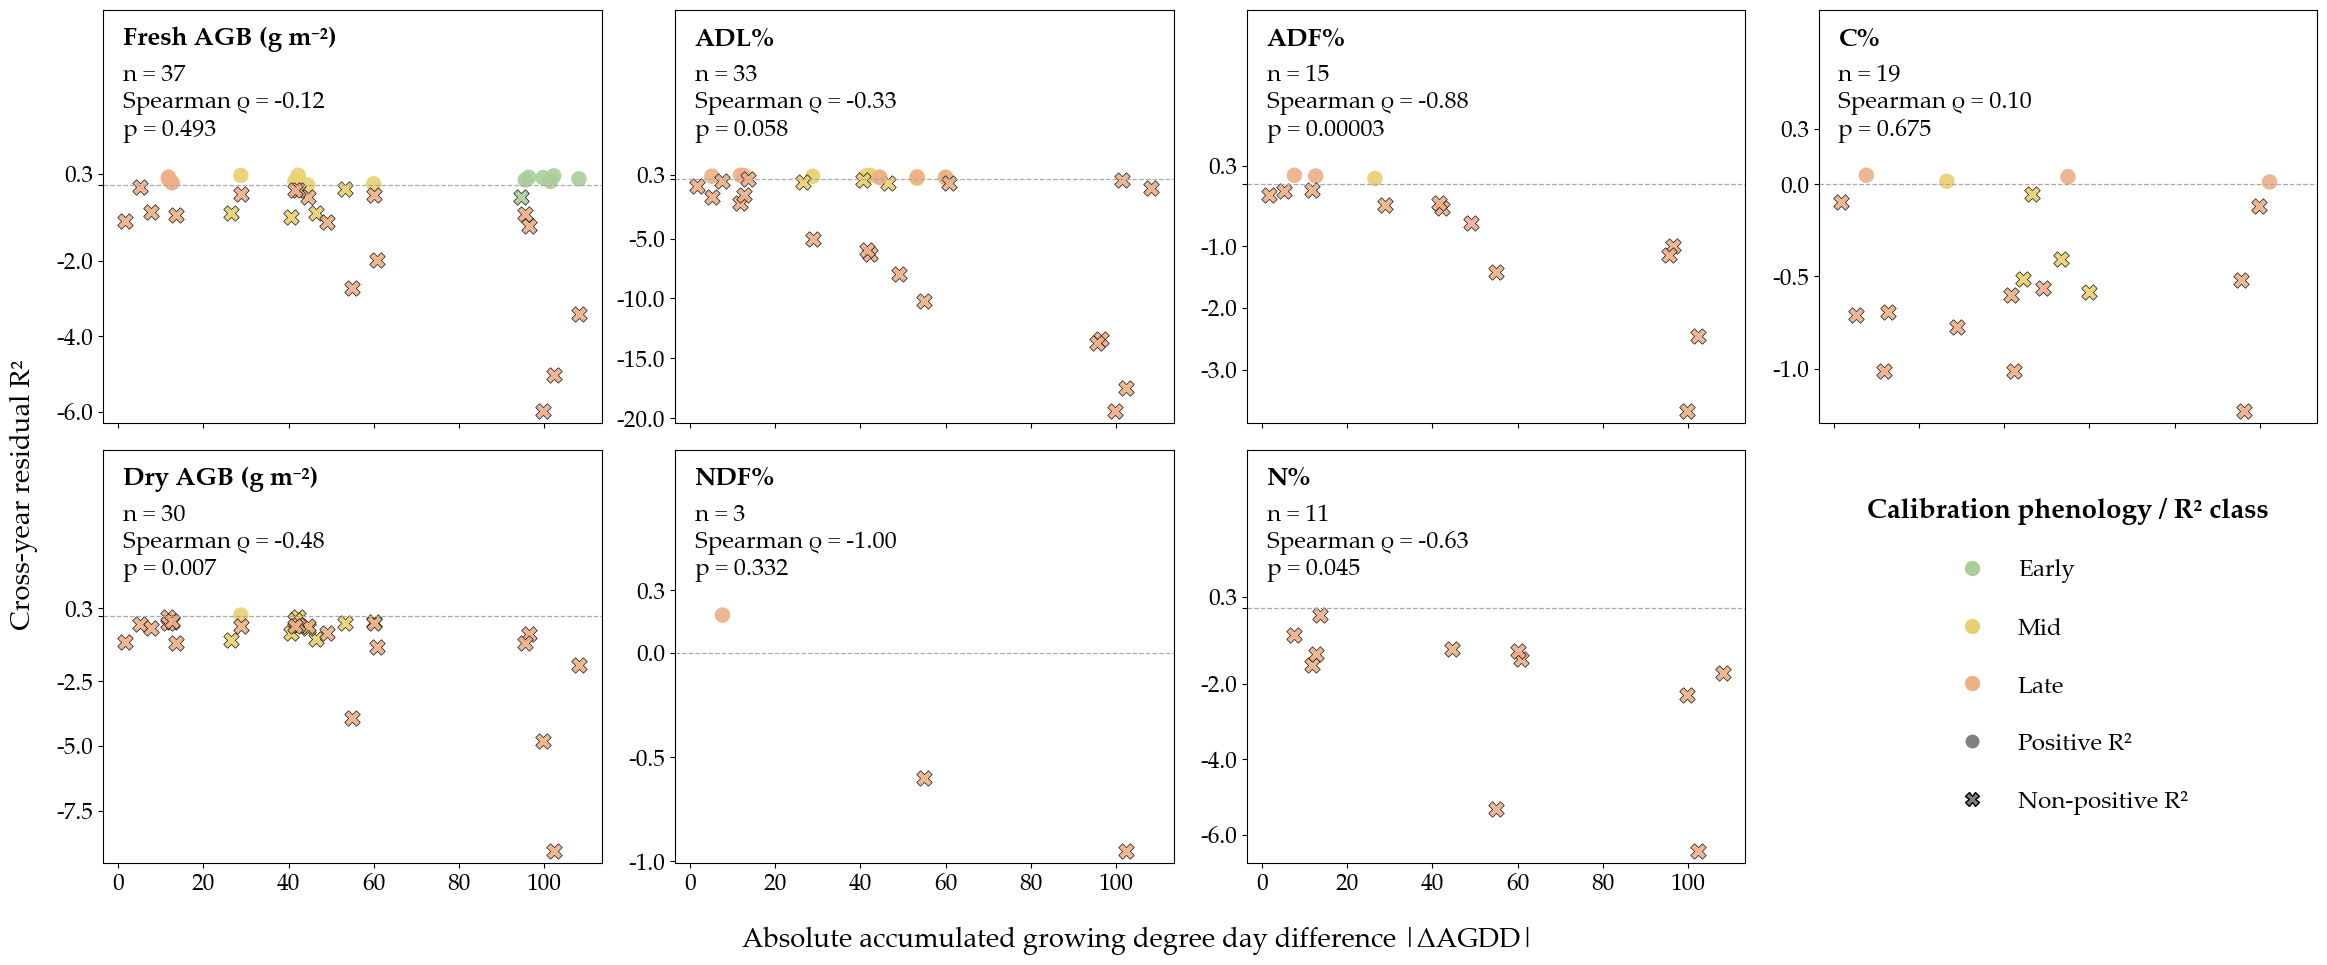

In [55]:
# ============================================================
# MAIN FIGURE — |ΔAGDD| vs cross-year residual R²
# ALL evaluated transfers, by trait
# Spearman p-values: same permutation test for ALL traits
# ============================================================

from scipy.stats import spearmanr, rankdata
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# -------------------------
# Figure settings
# -------------------------

base_size = 12
def rel(x): return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype",
    "axes.titlesize": rel(1.5),
    "axes.labelsize": rel(1.5),
    "figure.titlesize": rel(1.6),
    "xtick.labelsize": rel(1.4),
    "ytick.labelsize": rel(1.4),
    "legend.fontsize": rel(1.4),
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

FIGSIZE = (24, 10)
POINT_SIZE = 125
POINT_ALPHA = 0.90
TEXT_X = 0.04
TRAIT_TEXT_Y = 0.96
CORR_TEXT_Y = 0.87

# Permutation-test settings
N_PERM = 100000
PERM_SEED = 42

# -------------------------
# Trait labels/order
# -------------------------

trait_labels = {
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%"
}

trait_order = [
    "Fresh AGB (g m⁻²)", "ADL%", "ADF%", "C%",
    "Dry AGB (g m⁻²)", "NDF%", "N%"
]

label_to_internal = {v: k for k, v in trait_labels.items()}

# -------------------------
# Calibration phenology classes
# -------------------------

EARLY = {"2010"}

MID = {
    "2010-2011", "2010-2012", "2010-2013",
    "2010-2011-2012", "2010-2011-2013", "2010-2012-2013"
}

LATE = {
    "2011", "2012", "2013",
    "2011-2012", "2011-2013", "2012-2013",
    "2011-2012-2013"
}

PHENO_COLORS = {
    "Early": to_rgba("#A9CE9A"),
    "Mid": to_rgba("#E8D16E"),
    "Late": to_rgba("#EDB087")
}

def phenology_class(y):
    y = str(y)
    if y in EARLY: return "Early"
    if y in MID: return "Mid"
    if y in LATE: return "Late"
    return "Other"

# -------------------------
# Spearman permutation test
# SAME METHOD FOR ALL TRAITS
# -------------------------

def spearman_permutation_test(x, y, n_perm=N_PERM, seed=PERM_SEED):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)

    # Spearman = Pearson correlation of ranks
    xr = rankdata(x)
    yr = rankdata(y)
    xc = xr - xr.mean()
    yc = yr - yr.mean()

    denom = np.sqrt(np.sum(xc**2) * np.sum(yc**2))
    if denom == 0:
        return np.nan, np.nan

    rho = np.dot(xc, yc) / denom
    rng = np.random.default_rng(seed)
    extreme = 0

    for _ in range(n_perm):
        rho_perm = np.dot(xc, rng.permutation(yc)) / denom
        if abs(rho_perm) >= abs(rho) - 1e-12:
            extreme += 1

    # +1 correction prevents p = 0
    p = (extreme + 1) / (n_perm + 1)
    return rho, p

def fmt_p_dynamic(p, max_decimals=10):
    if pd.isna(p): return "NA"
    if p >= 0.001: return f"{p:.3f}"
    for d in range(4, max_decimals + 1):
        txt = f"{p:.{d}f}"
        if float(txt) > 0:
            return txt.rstrip("0").rstrip(".")
    return f"{p:.{max_decimals}f}".rstrip("0").rstrip(".")

def fmt_rho(rho):
    if pd.isna(rho): return "NA"
    if abs(rho) >= 0.01: return f"{rho:.2f}"
    if abs(rho) >= 0.001: return f"{rho:.3f}"
    return f"{rho:.4f}"

# -------------------------
# Build AGDD analysis table
# ALL evaluated transfers
# -------------------------

agdd_df = (
    models_df_expanded
    .assign(
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        abs_AGDD=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        Calibration_Year=lambda d: d["Predicted_From"].astype(str),
        Trait_internal=lambda d: d["Trait"].astype(str)
    )
    .dropna(subset=["R2_ext_num", "abs_AGDD", "Calibration_Year", "Trait_internal"])
    .copy()
)

agdd_df["Phenology_Class"] = agdd_df["Calibration_Year"].map(phenology_class)
agdd_df["R2_Class"] = np.where(
    agdd_df["R2_ext_num"] > 0, "Positive R²", "Non-positive R²"
)

# -------------------------
# Trait-wise Spearman correlations
# ALL transfers; permutation p-values
# -------------------------

trait_stats = {}

for i, label in enumerate(trait_order):
    g = agdd_df[agdd_df["Trait_internal"] == label_to_internal[label]]

    if len(g) >= 3 and g["abs_AGDD"].nunique() > 1 and g["R2_ext_num"].nunique() > 1:
        rho, p = spearman_permutation_test(
            g["abs_AGDD"].values,
            g["R2_ext_num"].values,
            seed=PERM_SEED + i
        )
    else:
        rho, p = np.nan, np.nan

    trait_stats[label] = {
        "n": len(g),
        "rho": rho,
        "p": p,
        "p_method": f"Permutation ({N_PERM:,})"
    }

trait_stats_df = pd.DataFrame([
    {"Trait": label, **stats}
    for label, stats in trait_stats.items()
])

display(trait_stats_df.round({"rho": 4, "p": 6}))

# -------------------------
# Plot
# -------------------------

fig, axes = plt.subplots(2, 4, figsize=FIGSIZE, sharex=True, sharey=False)
axes = axes.ravel()

marker_map = {
    "Positive R²": "o",
    "Non-positive R²": "X"
}

for i, label in enumerate(trait_order):
    ax = axes[i]
    g = agdd_df[agdd_df["Trait_internal"] == label_to_internal[label]]

    for pheno in ["Early", "Mid", "Late"]:
        for r2_class in ["Positive R²", "Non-positive R²"]:
            d = g[
                (g["Phenology_Class"] == pheno) &
                (g["R2_Class"] == r2_class)
            ]

            if d.empty:
                continue

            ax.scatter(
                d["abs_AGDD"], d["R2_ext_num"],
                s=POINT_SIZE,
                alpha=POINT_ALPHA,
                color=PHENO_COLORS[pheno],
                marker=marker_map[r2_class],
                edgecolor="black" if r2_class == "Non-positive R²" else "none",
                linewidth=0.5
            )

    ax.axhline(0, color="darkgray", linestyle="--", linewidth=0.9)

    # -------------------------
    # Dynamic y-limits + controlled ticks
    # -------------------------

    if not g.empty:
        ymin = g["R2_ext_num"].min()
        ymax = g["R2_ext_num"].max()
        data_range = ymax - ymin

        if data_range == 0:
            data_range = max(abs(ymax), 1)

        lower_pad = 0.05 * data_range
        upper_pad = 0.70 * data_range

        ax.set_ylim(ymin - lower_pad, ymax + upper_pad)

        ylo, yhi = ax.get_ylim()
        ticks = ax.get_yticks()
        ticks = ticks[(ticks >= ylo) & (ticks <= 0)]

        if yhi >= 0.3:
            ticks = np.append(ticks, 0.3)

        ticks = np.unique(np.round(ticks, 10))
        ax.set_yticks(ticks)

        crowded = (0.3 / (yhi - ylo)) < 0.05
        ax.set_yticklabels([
            "" if crowded and np.isclose(t, 0) else f"{t:.1f}"
            for t in ticks
        ])

    # -------------------------
    # Trait + statistics
    # -------------------------

    n = trait_stats[label]["n"]
    rho = trait_stats[label]["rho"]
    p = trait_stats[label]["p"]

    ax.text(
        TEXT_X, TRAIT_TEXT_Y, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=rel(1.55),
        fontweight="bold"
    )

    stat_text = (
        f"n = {n}\n"
        f"Spearman ρ = {fmt_rho(rho)}\n"
        f"p = {fmt_p_dynamic(p)}"
    )

    ax.text(
        TEXT_X, CORR_TEXT_Y, stat_text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=rel(1.45)
    )

# -------------------------
# Legend in unused panel
# -------------------------

axes[-1].set_axis_off()

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=11,
           markerfacecolor=PHENO_COLORS["Early"], markeredgecolor="none", label="Early"),
    Line2D([0], [0], marker="o", linestyle="", markersize=11,
           markerfacecolor=PHENO_COLORS["Mid"], markeredgecolor="none", label="Mid"),
    Line2D([0], [0], marker="o", linestyle="", markersize=11,
           markerfacecolor=PHENO_COLORS["Late"], markeredgecolor="none", label="Late"),
    Line2D([0], [0], marker="o", linestyle="", markersize=10,
           markerfacecolor="gray", markeredgecolor="none", label="Positive R²"),
    Line2D([0], [0], marker="X", linestyle="", markersize=10,
           markerfacecolor="gray", markeredgecolor="black", label="Non-positive R²")
]

axes[-1].legend(
    handles=legend_handles,
    frameon=False,
    loc="center",
    title="Calibration phenology / R² class",
    fontsize=rel(1.45),
    title_fontproperties={"weight": "bold", "size": rel(1.65)},
    labelspacing=1.4,
    handletextpad=0.9
)

# -------------------------
# Common labels/layout
# -------------------------

fig.supxlabel(
    "Absolute accumulated growing degree day difference |ΔAGDD|",
    fontsize=rel(1.65),
    y=0.04
)

fig.supylabel(
    r"Cross-year residual R²",
    fontsize=rel(1.65),
    x=0.03
)

fig.subplots_adjust(wspace=0.18, hspace=0.28)
plt.tight_layout(rect=[0.025, 0.04, 1, 1])

# ## -------------------------
# ## Save if needed
# ## -------------------------
# fig.savefig(output_path("PPR2_FIGURE_AGDD_vs_R2ext_ALL_TRANSFERS_Revised.pdf"), bbox_inches="tight", pad_inches=0.05)
# fig.savefig(output_path("PPR2_FIGURE_AGDD_vs_R2ext_ALL_TRANSFERS_Revised.png"), bbox_inches="tight", pad_inches=0.05, dpi=600)

# trait_stats_df.to_csv(output_path("PPR2_APPENDIX_Table_AGDD_stats.csv"),index=False)
# # trait_stats_df.to_excel(output_path("PPR2_APPENDIX_Table_AGDD_stats.xlsx"),index=False)

plt.show()

In [56]:
### 
# ============================================================
# -------------------------
# Overall Spearman correlation
# ALL 148 transfers
# -------------------------

overall_rho, overall_p = spearman_permutation_test(
    agdd_df["abs_AGDD"].values,
    agdd_df["R2_ext_num"].values,
    n_perm=N_PERM,
    seed=PERM_SEED
)

overall_agdd_stats = pd.DataFrame([{
    "Group": "Overall",
    "n": len(agdd_df),
    "Spearman_rho": overall_rho,
    "p_value": overall_p,
    "p_method": f"Permutation ({N_PERM:,})"
}])

display(overall_agdd_stats.round({
    "Spearman_rho": 4,
    "p_value": 6
}))

,Group,n,Spearman_rho,p_value,p_method
0,Overall,148,-0.3046,0.0003,"Permutation (100,000)"


Retained calibration Year × Trait models: 21
VIP rows after retained-model filtering: 5796
Retained Year × Trait VIP models: 21


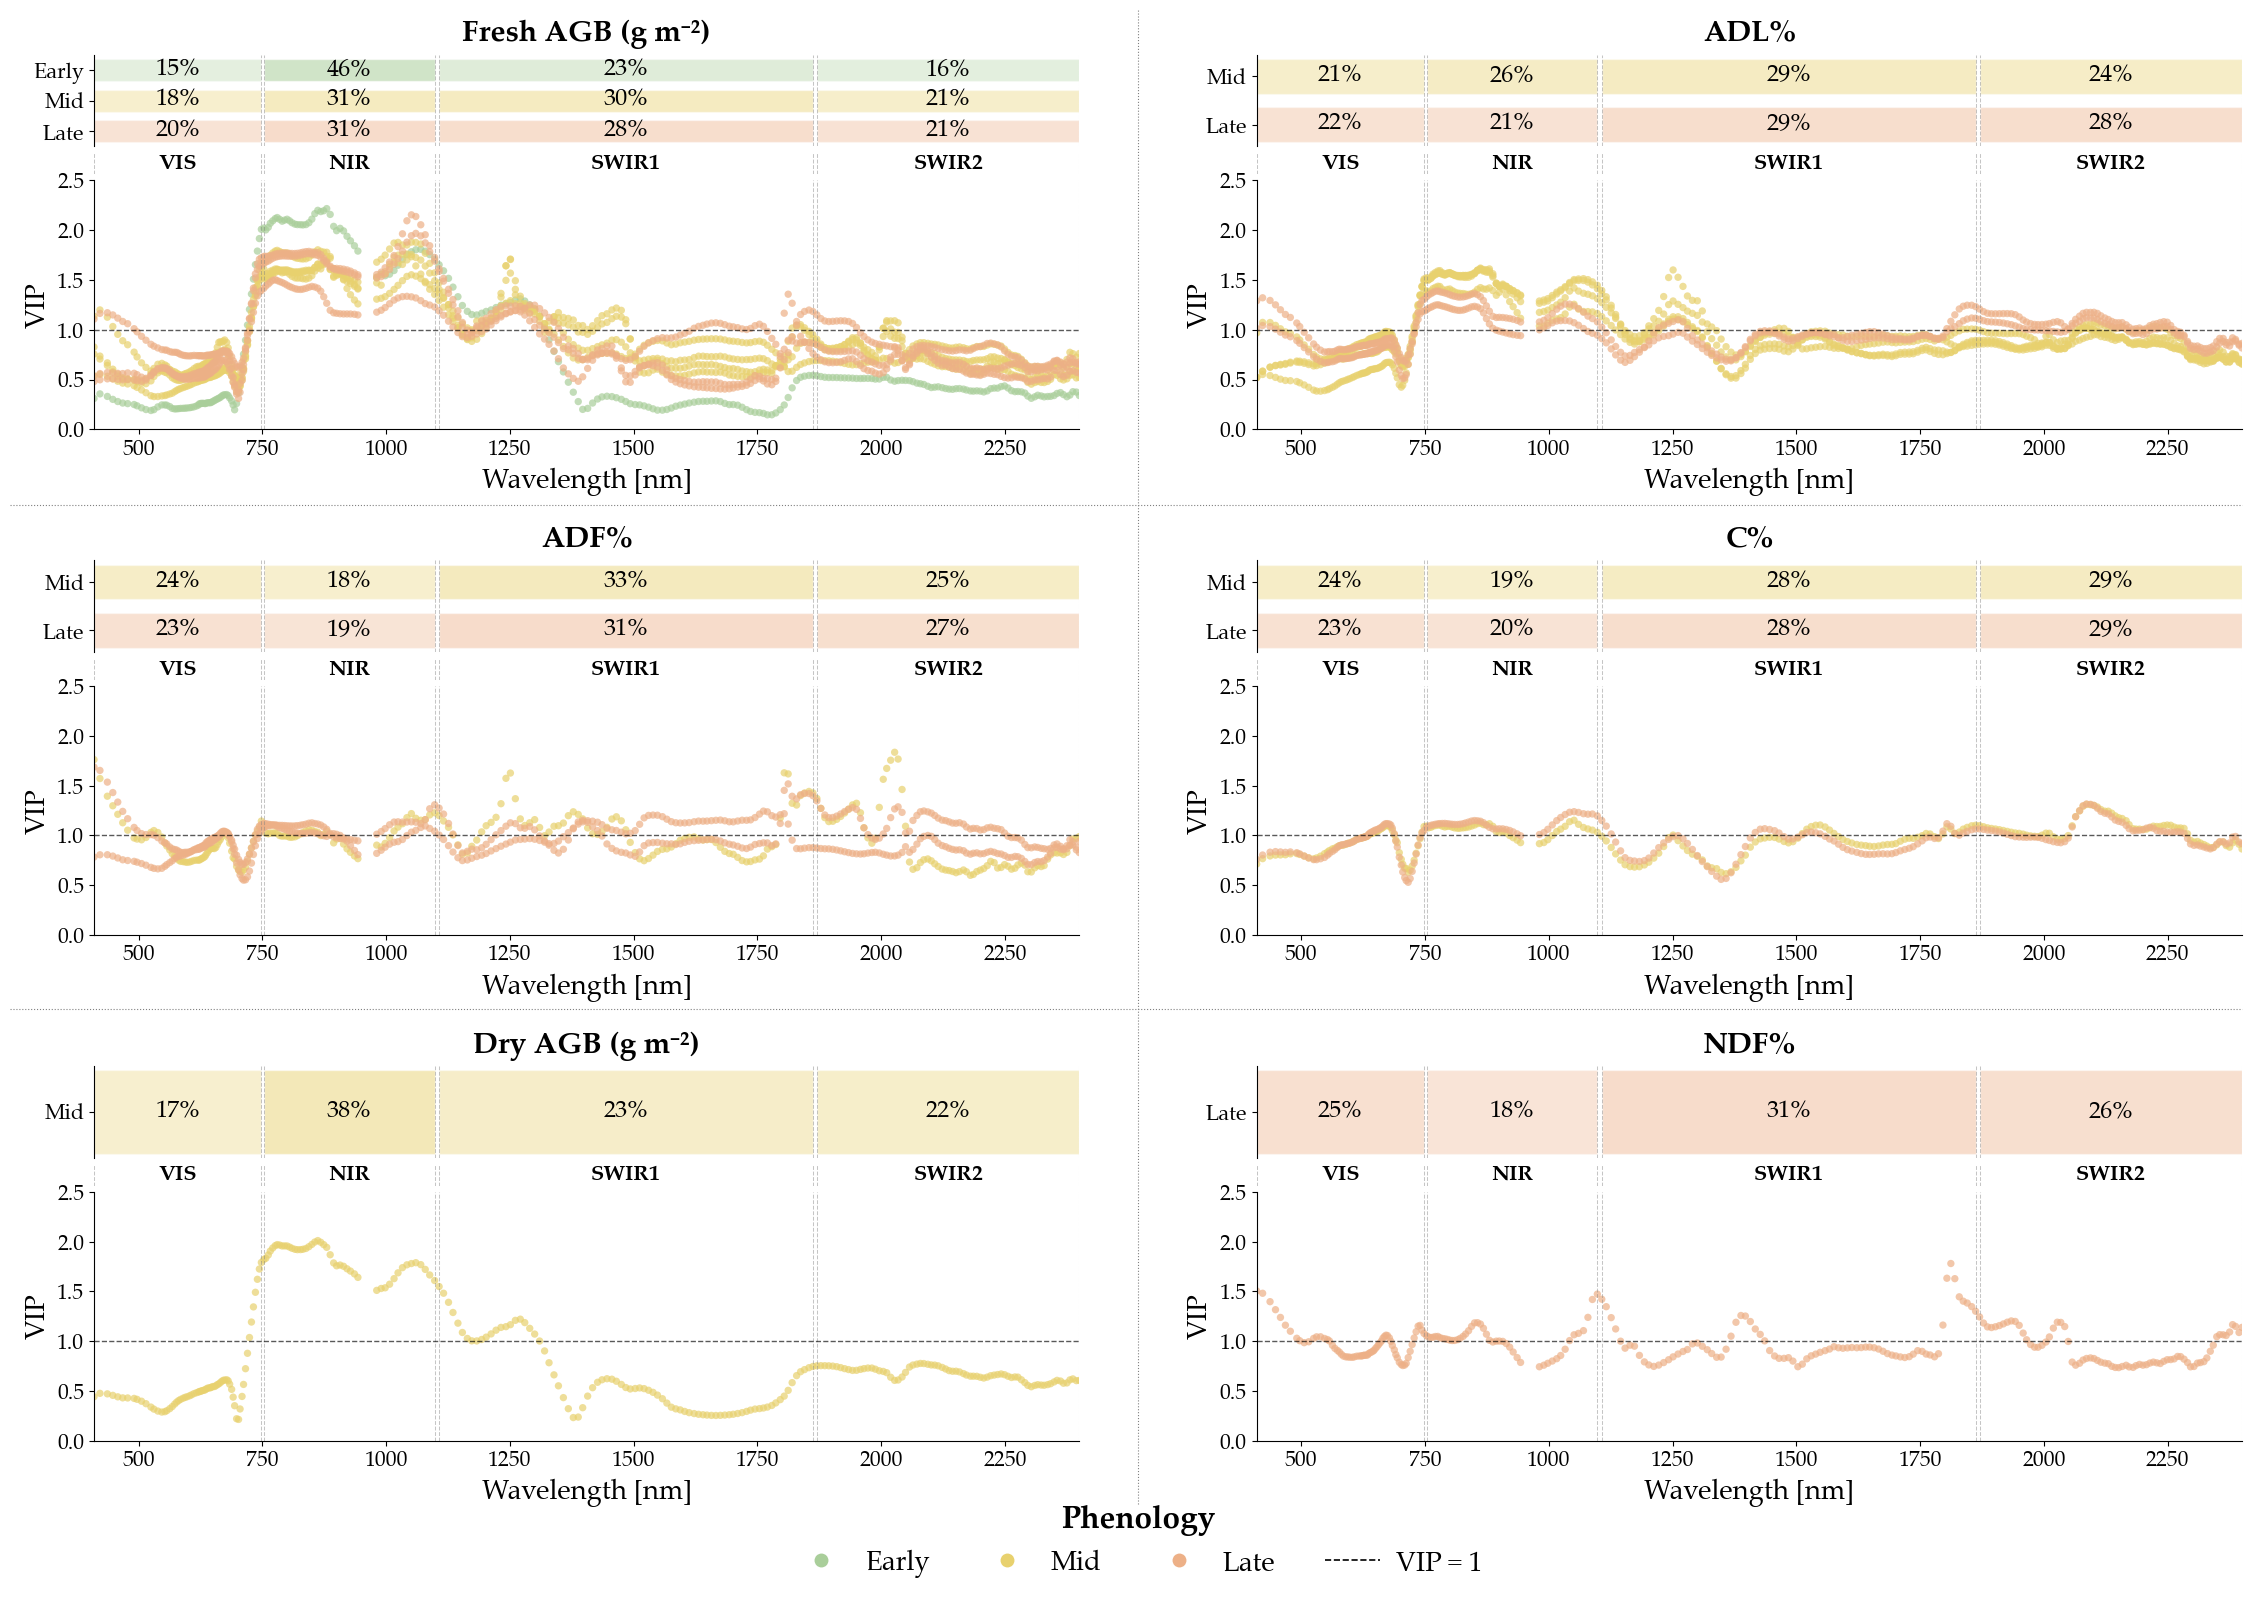

In [57]:
# ============================================================
# ENRICHED VIP FIGURE — ALL SELECTED TRAITS
# Top: regional VIP share (%) by calibration phenology
# Main: mean VIP by wavelength and calibration phenology
# Retained models: Valid_Iter >= 700, Iter_R2_iqr <= 0.15,
#                  at least one positive cross-year residual R²
# ============================================================
import warnings
warnings.filterwarnings("ignore")

FIGSIZE = (24, 18)
POINT_SIZE, POINT_ALPHA = 28, 0.70
base_size = 12
def rel(x): return base_size * (x + 0.3)

PHENO_COLORS_SHORT = {"early":"#A9CE9A", "mid":"#E8D16E", "late":"#EDB087"}
PHENO_LABELS_VISUAL = {"early":"Early", "mid":"Mid", "late":"Late"}
phenology_order = ["early", "mid", "late"]

REGION_BANDS = {
    "VIS":(410,748), "NIR":(753,1098),
    "SWIR1":(1107,1862), "SWIR2":(1870,2400)
}
region_order = ["VIS","NIR","SWIR1","SWIR2"]

trait_order_codes = [
    "Biom_wet_g","ADL_perc","ADF_perc",
    "C_perc","Biom_dry_g","NDF_perc"
]
trait_order_labels = [trait_labels_pub[t] for t in trait_order_codes]

def vip_pheno(y):
    y = str(y)
    if y == "2010": return "early"
    if "2010" in y.split("-"): return "mid"
    return "late"

def pct_to_alpha(pct, min_alpha=0.20, max_alpha=0.95):
    return min_alpha + (max_alpha - min_alpha) * pct / 100

# ------------------------------------------------------------
# Retained calibration models
# ------------------------------------------------------------

model_keys = models_df_expanded.copy()
model_keys["R2_ext_num"] = pd.to_numeric(model_keys["R2_ext"], errors="coerce")
model_keys["Valid_Iter"] = pd.to_numeric(model_keys["Valid_Iter"], errors="coerce")
model_keys["Iter_R2_iqr"] = pd.to_numeric(model_keys["Iter_R2_iqr"], errors="coerce")

valid_model_keys = (
    model_keys.loc[
        (model_keys["Valid_Iter"] >= 700) &
        # (model_keys["Iter_R2_iqr"] <= 0.15) &
        (model_keys["R2_ext_num"] > 0),
        ["Predicted_From","Trait"]
    ]
    .drop_duplicates()
    .rename(columns={"Predicted_From":"Year","Trait":"inVar"})
)

valid_model_keys["Year"] = (
    valid_model_keys["Year"].astype(str).str.replace("&","-",regex=False)
)

print("Retained calibration Year × Trait models:", len(valid_model_keys))

# ------------------------------------------------------------
# Build wavelength-level VIP table
# ------------------------------------------------------------

def parse_folder_name_vip(folder_name):
    parts = folder_name.split("_")
    if len(parts) < 4:
        return None, None
    year = parts[1].replace("&", "-")
    trait = "_".join(parts[3:])
    return year, trait

vip_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:
    year_val, trait_val = parse_folder_name_vip(folder.name)
    if year_val is None or trait_val not in trait_order_codes:
        continue

    year_val = str(year_val).replace("&","-")
    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips = pd.read_csv(max(vips_files, key=iter_n)).drop(
        columns=["Unnamed: 0"], errors="ignore"
    )
    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]
    if not vip_cols:
        continue

    vip_mean = vips[vip_cols].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    for col in vip_cols:
        wvl = float(col)
        region = spectral_region(wvl)
        if pd.isna(region):
            continue
        vip_rows.append({
            "Year":year_val,
            "inVar":trait_val,
            "Trait_label":trait_labels_pub[trait_val],
            "Phenology":vip_pheno(year_val),
            "Wavelength":wvl,
            "Region":region,
            "VIP":float(vip_mean[col])
        })

vip_long_all = pd.DataFrame(vip_rows)

if vip_long_all.empty:
    raise ValueError("No usable VIP data were found.")

vip_long_all = vip_long_all.merge(
    valid_model_keys, on=["Year","inVar"], how="inner", validate="many_to_one"
)

vip_long_all["Phenology"] = pd.Categorical(
    vip_long_all["Phenology"], categories=phenology_order, ordered=True
)
vip_long_all["Trait_label"] = pd.Categorical(
    vip_long_all["Trait_label"], categories=trait_order_labels, ordered=True
)
vip_long_all = vip_long_all.sort_values(
    ["Trait_label","Phenology","Year","Wavelength"]
).reset_index(drop=True)

print("VIP rows after retained-model filtering:", len(vip_long_all))
print("Retained Year × Trait VIP models:",
      vip_long_all[["Year","inVar"]].drop_duplicates().shape[0])

# ------------------------------------------------------------
# Draw one trait
# ------------------------------------------------------------

def draw_trait_panel(fig, outer_spec, trait_code, trait_label):
    subgs = outer_spec.subgridspec(
        3, 1, height_ratios=[1.25,0.30,3.4], hspace=0.05
    )
    ax_top = fig.add_subplot(subgs[0,0])
    ax_region = fig.add_subplot(subgs[1,0], sharex=ax_top)
    ax_main = fig.add_subplot(subgs[2,0], sharex=ax_top)

    dtrait = vip_long_all[vip_long_all["inVar"] == trait_code].copy()
    if dtrait.empty:
        ax_main.text(0.5,0.5,f"No data for {trait_label}",
                     ha="center",va="center",transform=ax_main.transAxes)
        return

    active_ph = [
        p for p in phenology_order
        if p in dtrait["Phenology"].dropna().astype(str).unique()
    ]

    # Regional VIP shares
    share = (
        dtrait.groupby(["Phenology","Region"], observed=True)["VIP"]
        .sum().reset_index()
    )
    share["Total"] = share.groupby("Phenology", observed=True)["VIP"].transform("sum")
    share["VIP_pct"] = 100 * share["VIP"] / share["Total"]

    wide = (
        share.pivot(index="Phenology",columns="Region",values="VIP_pct")
        .reindex(index=active_ph,columns=region_order)
        .fillna(0)
    )

    # Integer percentages summing exactly to 100
    wide_int = wide.copy()
    for idx in wide.index:
        vals = wide.loc[idx].values
        ints = np.floor(vals).astype(int)
        remainder = 100 - ints.sum()
        order = np.argsort(vals - ints)[::-1]
        ints[order[:remainder]] += 1
        wide_int.loc[idx] = ints

    # Region boundaries
    for ax in [ax_top,ax_region,ax_main]:
        for _,(x0,x1) in REGION_BANDS.items():
            ax.axvline(x0,color="grey",lw=0.75,ls="--",alpha=0.45)
            ax.axvline(x1,color="grey",lw=0.75,ls="--",alpha=0.45)

    # Top regional shares
    ypos = np.arange(len(active_ph))
    for i,ph in enumerate(active_ph):
        for reg in region_order:
            pct = float(wide_int.loc[ph,reg])
            if pct <= 0: continue
            x0,x1 = REGION_BANDS[reg]
            ax_top.barh(
                i,x1-x0,left=x0,height=0.72,
                color=PHENO_COLORS_SHORT[ph],
                alpha=pct_to_alpha(pct),
                edgecolor="white",linewidth=1
            )
            ax_top.text(
                (x0+x1)/2,i,f"{pct:.0f}%",
                ha="center",va="center",fontsize=rel(1.15)
            )

    ax_top.set_yticks(ypos)
    ax_top.set_yticklabels(
        [PHENO_LABELS_VISUAL[p] for p in active_ph], fontsize=rel(1.0)
    )
    ax_top.invert_yaxis()
    ax_top.set_xlim(410,2400)
    ax_top.set_title(trait_label,fontsize=rel(1.5),fontweight="bold",pad=10)
    ax_top.tick_params(axis="x",bottom=False,labelbottom=False)

    # Region labels
    ax_region.set_ylim(0,1)
    ax_region.set_yticks([])
    for reg,(x0,x1) in REGION_BANDS.items():
        ax_region.text(
            (x0+x1)/2,0.5,reg,
            ha="center",va="center",
            fontsize=rel(1.0),fontweight="bold"
        )
    ax_region.tick_params(axis="x",bottom=False,labelbottom=False)

    # Wavelength-level VIP
    for ph in active_ph:
        d = dtrait[dtrait["Phenology"].astype(str) == ph]
        ax_main.scatter(
            d["Wavelength"],d["VIP"],
            s=POINT_SIZE,alpha=POINT_ALPHA,
            color=PHENO_COLORS_SHORT[ph],
            edgecolor="none",label=PHENO_LABELS_VISUAL[ph]
        )

    ax_main.axhline(1,color="black",lw=1,ls="--",alpha=0.65)
    ax_main.set(xlim=(410,2400),ylim=(0,2.5))
    ax_main.set_xlabel("Wavelength [nm]",fontsize=rel(1.35),labelpad=5)
    ax_main.set_ylabel("VIP",fontsize=rel(1.35))
    ax_main.tick_params(axis="both",labelsize=rel(1.0))

    for ax in [ax_top,ax_region,ax_main]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax_top.spines["bottom"].set_visible(False)
    ax_region.spines["left"].set_visible(False)
    ax_region.spines["bottom"].set_visible(False)
    ax_region.spines["top"].set_visible(False)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(figsize=FIGSIZE)
outer_gs = fig.add_gridspec(3,2,wspace=0.18,hspace=0.35)

for idx,trait_code in enumerate(trait_order_codes):
    draw_trait_panel(
        fig, outer_gs[idx//2,idx%2],
        trait_code, trait_labels_pub[trait_code]
    )

legend_handles = [
    Line2D([0],[0],marker="o",linestyle="None",markersize=10,
           markerfacecolor=PHENO_COLORS_SHORT[p],markeredgecolor="none",
           label=PHENO_LABELS_VISUAL[p])
    for p in phenology_order
]
vip_line = Line2D([0],[0],color="black",lw=1.2,ls="--",label="VIP = 1")

fig.legend(
    handles=legend_handles+[vip_line],
    title="Phenology",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.44,0.02),
    ncol=4,
    fontsize=rel(1.35),
    title_fontproperties={"weight":"bold","size":rel(1.6)},
    columnspacing=1.8,
    handletextpad=0.6
)

# Grid separators
fig.add_artist(Line2D(
    [0.44,0.44],[0.075,0.905],
    transform=fig.transFigure,color="gray",lw=0.8,ls=":"
))
for y in [0.63,0.35]:
    fig.add_artist(Line2D(
        [-0.03,0.90],[y,y],
        transform=fig.transFigure,color="gray",lw=0.8,ls=":"
    ))

plt.tight_layout(rect=[0,0.04,1,0.985])
fig.subplots_adjust(left=0.005)

# # -------------------------
# # Save if needed
# # -------------------------
# fig.savefig(output_path("PPR2_FIGURE_2_VIPS_vs_Trait-Phenology-Years_Revised.pdf"), bbox_inches="tight", pad_inches=0.05)
# fig.savefig(output_path("PPR2_FIGURE_2_VIPS_vs_Trait-Phenology-Years_Revised.png"), bbox_inches="tight", pad_inches=0.05, dpi=600)

plt.show()

In [59]:
# 
# ============================================================
# Reviewer 4 — Wavelength-level stability of positive-transfer VIP profiles
# Uses existing vip_long_all from Figure 3 workflow
# VIP > 1 = trait-sensitive wavelength
# ============================================================
from itertools import combinations

vip_stab = vip_long_all.copy()
vip_stab["VIP_gt1"] = vip_stab["VIP"] > 1

model_summary = (
    vip_stab.groupby(["inVar","Trait_label","Year","Phenology"], observed=True)
    .apply(lambda d: pd.Series({
        "Peak_wavelength_nm": d.loc[d["VIP"].idxmax(),"Wavelength"],
        "Peak_VIP": d["VIP"].max(),
        "VIP_gt1_n": d["VIP_gt1"].sum(),
        "VIP_gt1_percent": 100*d["VIP_gt1"].mean(),
        "VIP_gt1_min_nm": d.loc[d["VIP_gt1"],"Wavelength"].min() if d["VIP_gt1"].any() else np.nan,
        "VIP_gt1_max_nm": d.loc[d["VIP_gt1"],"Wavelength"].max() if d["VIP_gt1"].any() else np.nan
    }))
    .reset_index()
)

pair_rows = []
for trait, dtrait in vip_stab.groupby("Trait_label", observed=True):
    models = sorted(dtrait["Year"].astype(str).unique())
    for i in range(len(models)):
        for j in range(i+1, len(models)):
            a, b = models[i], models[j]
            wa = set(dtrait.loc[(dtrait["Year"].astype(str)==a) & dtrait["VIP_gt1"],"Wavelength"])
            wb = set(dtrait.loc[(dtrait["Year"].astype(str)==b) & dtrait["VIP_gt1"],"Wavelength"])
            union = wa | wb
            pair_rows.append({
                "Trait": trait, "Model_A": a, "Model_B": b,
                "VIP_gt1_A_n": len(wa), "VIP_gt1_B_n": len(wb),
                "Overlap_n": len(wa & wb),
                "Jaccard_overlap": len(wa & wb)/len(union) if union else np.nan
            })

pairwise_overlap = pd.DataFrame(pair_rows)

trait_summary = (
    model_summary.groupby("Trait_label", observed=True)
    .agg(
        Retained_models=("Year","nunique"),
        Peak_min_nm=("Peak_wavelength_nm","min"),
        Peak_max_nm=("Peak_wavelength_nm","max"),
        Median_peak_nm=("Peak_wavelength_nm","median")
    )
    .reset_index()
    .rename(columns={"Trait_label":"Trait"})
)

if not pairwise_overlap.empty:
    overlap_summary = (
        pairwise_overlap.groupby("Trait", observed=True)["Jaccard_overlap"]
        .agg(Model_pairs="count", Median_Jaccard="median",
             Min_Jaccard="min", Max_Jaccard="max")
        .reset_index()
    )
    trait_summary = trait_summary.merge(overlap_summary, on="Trait", how="left")

for df in [model_summary, pairwise_overlap, trait_summary]:
    num = df.select_dtypes(include=np.number).columns
    df[num] = df[num].round(4)

print("MODEL-LEVEL VIP SUMMARY")
print(model_summary.to_string(index=False))

print("\nPAIRWISE VIP > 1 OVERLAP")
print(pairwise_overlap.to_string(index=False))

print("\nTRAIT-LEVEL VIP STABILITY")
print(trait_summary.to_string(index=False))

# Optional saves
# model_summary.to_csv(output_path("PPR2_VIP_Model_Level_Wavelength_Summary.csv"),index=False)
# pairwise_overlap.to_csv(output_path("PPR2_VIP_Pairwise_Wavelength_Overlap.csv"),index=False)
# trait_summary.to_csv(output_path("PPR2_VIP_Trait_summary.csv"),index=False)

MODEL-LEVEL VIP SUMMARY
     inVar       Trait_label           Year Phenology  Peak_wavelength_nm  Peak_VIP  VIP_gt1_n  VIP_gt1_percent  VIP_gt1_min_nm  VIP_gt1_max_nm
  ADF_perc              ADF% 2010-2012-2013       mid           2027.0000    1.8352   108.0000          39.1304        410.0000       2049.0000
  ADF_perc              ADF%      2011-2013      late           2086.0000    1.2458   128.0000          46.3768        662.0000       2249.0000
  ADF_perc              ADF%      2012-2013      late            410.0000    1.6866   105.0000          38.0435        410.0000       2049.0000
  ADL_perc              ADL% 2010-2011-2012       mid           1251.0000    1.6003    80.0000          28.9855        422.0000       1862.0000
  ADL_perc              ADL% 2010-2011-2013       mid            862.0000    1.6035    71.0000          25.7246        728.0000       2101.0000
  ADL_perc              ADL%      2010-2012       mid            862.0000    1.6192    91.0000          32.9710 

In [60]:
# ============================================================
# FINAL VIP STABILITY DIAGNOSTIC
# Wavelengths with VIP > 1 in >=75% of retained models
# ============================================================

vip_diag = vip_long_all.copy()
vip_diag["VIP_gt1"] = vip_diag["VIP"] > 1

# Unique retained model count per trait
model_counts = (
    vip_diag[["Trait_label","Year"]]
    .drop_duplicates()
    .groupby("Trait_label")["Year"]
    .nunique()
    .rename("Retained_models")
)

# For each trait × wavelength: proportion of retained models with VIP > 1
wvl_stability = (
    vip_diag.groupby(["Trait_label","Wavelength"], observed=True)
    .agg(
        Models_VIP_gt1=("VIP_gt1","sum"),
        Models_total=("Year","nunique"),
        Mean_VIP=("VIP","mean")
    )
    .reset_index()
)

wvl_stability["VIP_gt1_model_percent"] = (
    100 * wvl_stability["Models_VIP_gt1"] / wvl_stability["Models_total"]
)

# Restrict to traits with >=2 retained models and wavelengths stable in >=75%
stable75 = (
    wvl_stability
    .merge(model_counts, left_on="Trait_label", right_index=True, how="left")
    .loc[
        lambda d: (d["Retained_models"] >= 2) &
                  (d["VIP_gt1_model_percent"] >= 75)
    ]
    .copy()
)

# Convert adjacent wavelengths into contiguous intervals
def contiguous_ranges(d, max_gap=10):
    w = np.sort(d["Wavelength"].unique())
    if len(w) == 0:
        return pd.DataFrame()

    groups = [[w[0]]]
    for x in w[1:]:
        if x - groups[-1][-1] <= max_gap:
            groups[-1].append(x)
        else:
            groups.append([x])

    rows = []
    for g in groups:
        sub = d[d["Wavelength"].isin(g)]
        rows.append({
            "Start_nm": min(g),
            "End_nm": max(g),
            "N_wavelengths": len(g),
            "Median_model_percent": sub["VIP_gt1_model_percent"].median(),
            "Mean_VIP": sub["Mean_VIP"].mean()
        })
    return pd.DataFrame(rows)

range_rows = []
for trait, d in stable75.groupby("Trait_label", observed=True):
    out = contiguous_ranges(d)
    if not out.empty:
        out.insert(0, "Trait", trait)
        out.insert(1, "Retained_models", int(model_counts.loc[trait]))
        range_rows.append(out)

stable_ranges = pd.concat(range_rows, ignore_index=True) if range_rows else pd.DataFrame()

for df in [stable75, stable_ranges]:
    num = df.select_dtypes(include=np.number).columns
    df[num] = df[num].round(2)

print("STABLE VIP > 1 WAVELENGTH RANGES (>=75% OF RETAINED MODELS)")
print(stable_ranges.to_string(index=False))

print("\nNUMBER OF STABLE WAVELENGTHS PER TRAIT")
print(
    stable75.groupby("Trait_label", observed=True)["Wavelength"]
    .nunique()
    .rename("Stable_wavelength_n")
    .to_string()
)

STABLE VIP > 1 WAVELENGTH RANGES (>=75% OF RETAINED MODELS)
            Trait  Retained_models  Start_nm    End_nm  N_wavelengths  Median_model_percent  Mean_VIP
Fresh AGB (g m⁻²)                8  728.0000  943.0000             40              100.0000    1.6200
Fresh AGB (g m⁻²)                8  981.0000 1145.0000             19              100.0000    1.5300
Fresh AGB (g m⁻²)                8 1193.0000 1320.0000             14              100.0000    1.1900
             ADL%                6  732.0000  943.0000             39              100.0000    1.3800
             ADL%                6  981.0000 1107.0000             15              100.0000    1.2400
             ADL%                6 1232.0000 1280.0000              6               83.3300    1.1500
             ADL%                6 2079.0000 2094.0000              3               83.3300    1.0500
             ADF%                3  671.0000  678.0000              3              100.0000    1.0300
             ADF%     

In [61]:
# ============================================================
# APPENDIX TABLE — VIP WAVELENGTH STABILITY SUMMARY
# ============================================================

# Collapse stable wavelength intervals into one text field per trait
stable_ranges_text = (
    stable_ranges
    .assign(
        Stable_range=lambda d: np.where(
            d["Start_nm"].eq(d["End_nm"]),
            d["Start_nm"].astype(int).astype(str),
            d["Start_nm"].astype(int).astype(str) + "–" +
            d["End_nm"].astype(int).astype(str)
        )
    )
    .groupby("Trait", observed=True)["Stable_range"]
    .apply("; ".join)
    .reset_index(name="Stable VIP > 1 wavelength ranges (nm)")
)

# Start from the previously calculated trait-level stability summary
appendix_vip_stability = trait_summary.copy()

# Format peak wavelength range
appendix_vip_stability["Peak wavelength range (nm)"] = np.where(
    appendix_vip_stability["Peak_min_nm"].eq(appendix_vip_stability["Peak_max_nm"]),
    appendix_vip_stability["Peak_min_nm"].round(0).astype("Int64").astype(str),
    appendix_vip_stability["Peak_min_nm"].round(0).astype("Int64").astype(str) + "–" +
    appendix_vip_stability["Peak_max_nm"].round(0).astype("Int64").astype(str)
)

# Merge stable wavelength ranges
appendix_vip_stability = appendix_vip_stability.merge(
    stable_ranges_text, on="Trait", how="left"
)

# Final appendix columns
appendix_vip_stability = (
    appendix_vip_stability[
        [
            "Trait",
            "Retained_models",
            "Peak wavelength range (nm)",
            "Median_Jaccard",
            "Stable VIP > 1 wavelength ranges (nm)"
        ]
    ]
    .rename(columns={
        "Retained_models": "Positive-transfer calibration models (n)",
        "Median_Jaccard": "Median pairwise VIP > 1 overlap (Jaccard)"
    })
    .sort_values("Trait")
    .reset_index(drop=True)
)

appendix_vip_stability[
    "Median pairwise VIP > 1 overlap (Jaccard)"
] = pd.to_numeric(
    appendix_vip_stability["Median pairwise VIP > 1 overlap (Jaccard)"],
    errors="coerce"
).round(2)

# Save
# appendix_vip_stability.to_csv(output_path("PPR2_Appendix_VIP_Wavelength_Stability.csv"), index=False, encoding="utf-8-sig")

print("\nAPPENDIX VIP WAVELENGTH STABILITY TABLE")
print(appendix_vip_stability.to_string(index=False))


APPENDIX VIP WAVELENGTH STABILITY TABLE
            Trait  Positive-transfer calibration models (n) Peak wavelength range (nm)  Median pairwise VIP > 1 overlap (Jaccard)                           Stable VIP > 1 wavelength ranges (nm)
             ADF%                                         3                   410–2086                                     0.2600 671–678; 744–780; 827–862; 887; 1051–1107; 1378–1427; 1796–1812
             ADL%                                         6                   422–1251                                     0.6000                         732–943; 981–1107; 1232–1280; 2079–2094
               C%                                         2                       2086                                     0.7900    636–688; 744–914; 1016–1098; 1512–1548; 1796–1926; 2057–2283
  Dry AGB (g m⁻²)                                         1                        862                                        NaN                                                      

In [62]:
# Diagnose Fresh AGB calibration models used/not used in VIP figure
vip_check = (
    models_df_expanded
    .loc[models_df_expanded["Trait"] == "Biom_wet_g",
         ["Predicted_From","Trait","Valid_Iter","Iter_R2_iqr","R2_ext"]]
    .copy()
)

vip_check["R2_ext"] = pd.to_numeric(vip_check["R2_ext"], errors="coerce")

vip_check["Pass_ValidIter"] = vip_check["Valid_Iter"] >= 700
# vip_check["Pass_R2_IQR"] = vip_check["Iter_R2_iqr"] <= 0.15
vip_check["Positive_R2"] = vip_check["R2_ext"] > 0

vip_check.sort_values(["Predicted_From","R2_ext"], ascending=[True,False]).head(15)

,Predicted_From,Trait,Valid_Iter,Iter_R2_iqr,R2_ext,Pass_ValidIter,Positive_R2
83,2010,Biom_wet_g,847,0.3047,0.2455,True,True
80,2010,Biom_wet_g,847,0.3047,0.2068,True,True
84,2010,Biom_wet_g,847,0.3047,0.1976,True,True
79,2010,Biom_wet_g,847,0.3047,0.1646,True,True
82,2010,Biom_wet_g,847,0.3047,0.1341,True,True
81,2010,Biom_wet_g,847,0.3047,0.0975,True,True
78,2010,Biom_wet_g,847,0.3047,-0.3058,True,False
111,2010-2011-2012,Biom_wet_g,988,0.1509,0.2551,True,True
112,2010-2011-2013,Biom_wet_g,1000,0.1012,0.0023,True,True
100,2010-2012,Biom_wet_g,991,0.1820,0.2606,True,True


In [63]:
# ============================================================
# APPENDIX VIP TABLE — Single-year vs Multi-year
# Same retained-model definition as revised VIP figure:
# Valid_Iter >= 700 + at least one positive cross-year R²
# ============================================================

MODEL_TYPE_ORDER = ["Single-year", "Multi-year"]
PHENO_ORDER = ["Early", "Mid", "Late"]

trait_order_codes = [
    "Biom_wet_g", "ADL_perc", "Biom_dry_g",
    "ADF_perc", "C_perc", "N_perc", "NDF_perc"
]
trait_order_labels = [trait_labels_pub[t] for t in trait_order_codes]

def parse_folder_name_vip(folder_name):
    parts = folder_name.split("_")
    if len(parts) < 4: return None, None
    return parts[1].replace("&", "-"), "_".join(parts[3:])

def vip_pheno_label(y):
    y = str(y)
    if y == "2010": return "Early"
    if "2010" in y.split("-"): return "Mid"
    return "Late"

# ------------------------------------------------------------
# 1) Select calibration models:
#    >=700 valid iterations + at least one positive R²_t transfer
# ------------------------------------------------------------

models_for_vip = models_df_expanded.copy()
models_for_vip["Valid_Iter"] = pd.to_numeric(models_for_vip["Valid_Iter"], errors="coerce")
models_for_vip["R2_ext_num"] = pd.to_numeric(models_for_vip["R2_ext"], errors="coerce")
models_for_vip["Predicted_From"] = models_for_vip["Predicted_From"].astype(str).str.replace("&", "-", regex=False)

valid_model_keys = (
    models_for_vip.loc[
        (models_for_vip["Valid_Iter"] >= 700) &
        (models_for_vip["R2_ext_num"] > 0),
        ["Predicted_From", "Trait"]
    ]
    .drop_duplicates()
    .rename(columns={"Predicted_From": "Year", "Trait": "inVar"})
)

valid_model_keys["Model type"] = np.where(
    valid_model_keys["Year"].str.contains("-", regex=False),
    "Multi-year", "Single-year"
)
valid_model_keys["Phenology"] = valid_model_keys["Year"].map(vip_pheno_label)

print("Retained calibration Year × Trait models:", len(valid_model_keys))

# ------------------------------------------------------------
# 2) Read mean VIP by wavelength for each calibration model
# ------------------------------------------------------------

vip_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:
    year_val, trait_val = parse_folder_name_vip(folder.name)
    if year_val is None or trait_val not in trait_order_codes:
        continue

    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips = pd.read_csv(max(vips_files, key=iter_n)).drop(
        columns=["Unnamed: 0"], errors="ignore"
    )

    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]
    if not vip_cols:
        continue

    vip_mean = vips[vip_cols].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    for col in vip_cols:
        wvl = float(col)
        region = spectral_region(wvl)
        if pd.isna(region):
            continue

        vip_rows.append({
            "Year": year_val,
            "inVar": trait_val,
            "Trait": trait_labels_pub[trait_val],
            "Wavelength": wvl,
            "Region": region,
            "VIP": float(vip_mean[col])
        })

vip_long_all = pd.DataFrame(vip_rows)

if vip_long_all.empty:
    raise ValueError("No usable VIP files were found.")

vip_long_all = vip_long_all.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner",
    validate="many_to_one"
)

print(
    "Retained Year × Trait VIP models:",
    vip_long_all[["Year", "inVar"]].drop_duplicates().shape[0]
)

# ------------------------------------------------------------
# 3) Regional VIP contribution (%) per Trait × Type × Phenology
# ------------------------------------------------------------

vip_region_sum = (
    vip_long_all
    .groupby(["Trait", "inVar", "Model type", "Phenology", "Region"], observed=True)["VIP"]
    .sum()
    .reset_index()
)

vip_region_sum["Total_VIP"] = (
    vip_region_sum
    .groupby(["Trait", "inVar", "Model type", "Phenology"], observed=True)["VIP"]
    .transform("sum")
)

vip_region_sum["VIP_pct"] = (
    100 * vip_region_sum["VIP"] / vip_region_sum["Total_VIP"]
)

vip_table = (
    vip_region_sum
    .pivot_table(
        index=["Trait", "inVar", "Model type", "Phenology"],
        columns="Region",
        values="VIP_pct",
        fill_value=0,
        observed=True
    )
    .reset_index()
)

for reg in region_order:
    if reg not in vip_table.columns:
        vip_table[reg] = 0

# ------------------------------------------------------------
# 4) Order + integer percentages that sum exactly to 100
# ------------------------------------------------------------

vip_table["Trait"] = pd.Categorical(
    vip_table["Trait"], categories=trait_order_labels, ordered=True
)
vip_table["Model type"] = pd.Categorical(
    vip_table["Model type"], categories=MODEL_TYPE_ORDER, ordered=True
)
vip_table["Phenology"] = pd.Categorical(
    vip_table["Phenology"], categories=PHENO_ORDER, ordered=True
)

vip_table = (
    vip_table
    .sort_values(["Trait", "Model type", "Phenology"])
    .reset_index(drop=True)
)

region_int = []
for _, row in vip_table.iterrows():
    vals = row[region_order].astype(float).values
    ints = np.floor(vals).astype(int)
    remainder = 100 - ints.sum()
    order = np.argsort(vals - ints)[::-1]
    ints[order[:remainder]] += 1
    region_int.append(ints)

vip_table[region_order] = np.vstack(region_int)

vip_table_final = (
    vip_table
    .rename(columns={
        "VIS": "VIS (%)", "NIR": "NIR (%)",
        "SWIR1": "SWIR1 (%)", "SWIR2": "SWIR2 (%)"
    })
    [["Trait", "Model type", "Phenology",
      "VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]]
)

# Safety check: every displayed row must total 100%
assert (
    vip_table_final[["VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]]
    .sum(axis=1)
    .eq(100)
    .all()
), "A VIP percentage row does not sum to 100%."

display(vip_table_final)

# ## Optional save
# vip_table_final.to_csv(output_path("PPR2_APPENDIX_Table_VIP_regions_single_vs_multi_Revised.csv"),index=False)
# vip_table_final.to_excel(output_path("PPR2_APPENDIX_Table_VIP_regions_single_vs_multi_Revised.xlsx"),index=False)

Retained calibration Year × Trait models: 21
Retained Year × Trait VIP models: 21


Region,Trait,Model type,Phenology,VIS (%),NIR (%),SWIR1 (%),SWIR2 (%)
0,Fresh AGB (g m⁻²),Single-year,Early,15,46,23,16
1,Fresh AGB (g m⁻²),Single-year,Late,21,29,29,21
2,Fresh AGB (g m⁻²),Multi-year,Mid,18,31,30,21
3,Fresh AGB (g m⁻²),Multi-year,Late,20,34,25,21
4,ADL%,Single-year,Late,21,23,28,28
5,ADL%,Multi-year,Mid,21,26,29,24
6,ADL%,Multi-year,Late,23,20,29,28
7,Dry AGB (g m⁻²),Multi-year,Mid,17,38,23,22
8,ADF%,Multi-year,Mid,24,18,33,25
9,ADF%,Multi-year,Late,23,19,31,27


Converged calibration Year × Trait models: 48
Retained Year × Trait VIP models: 48


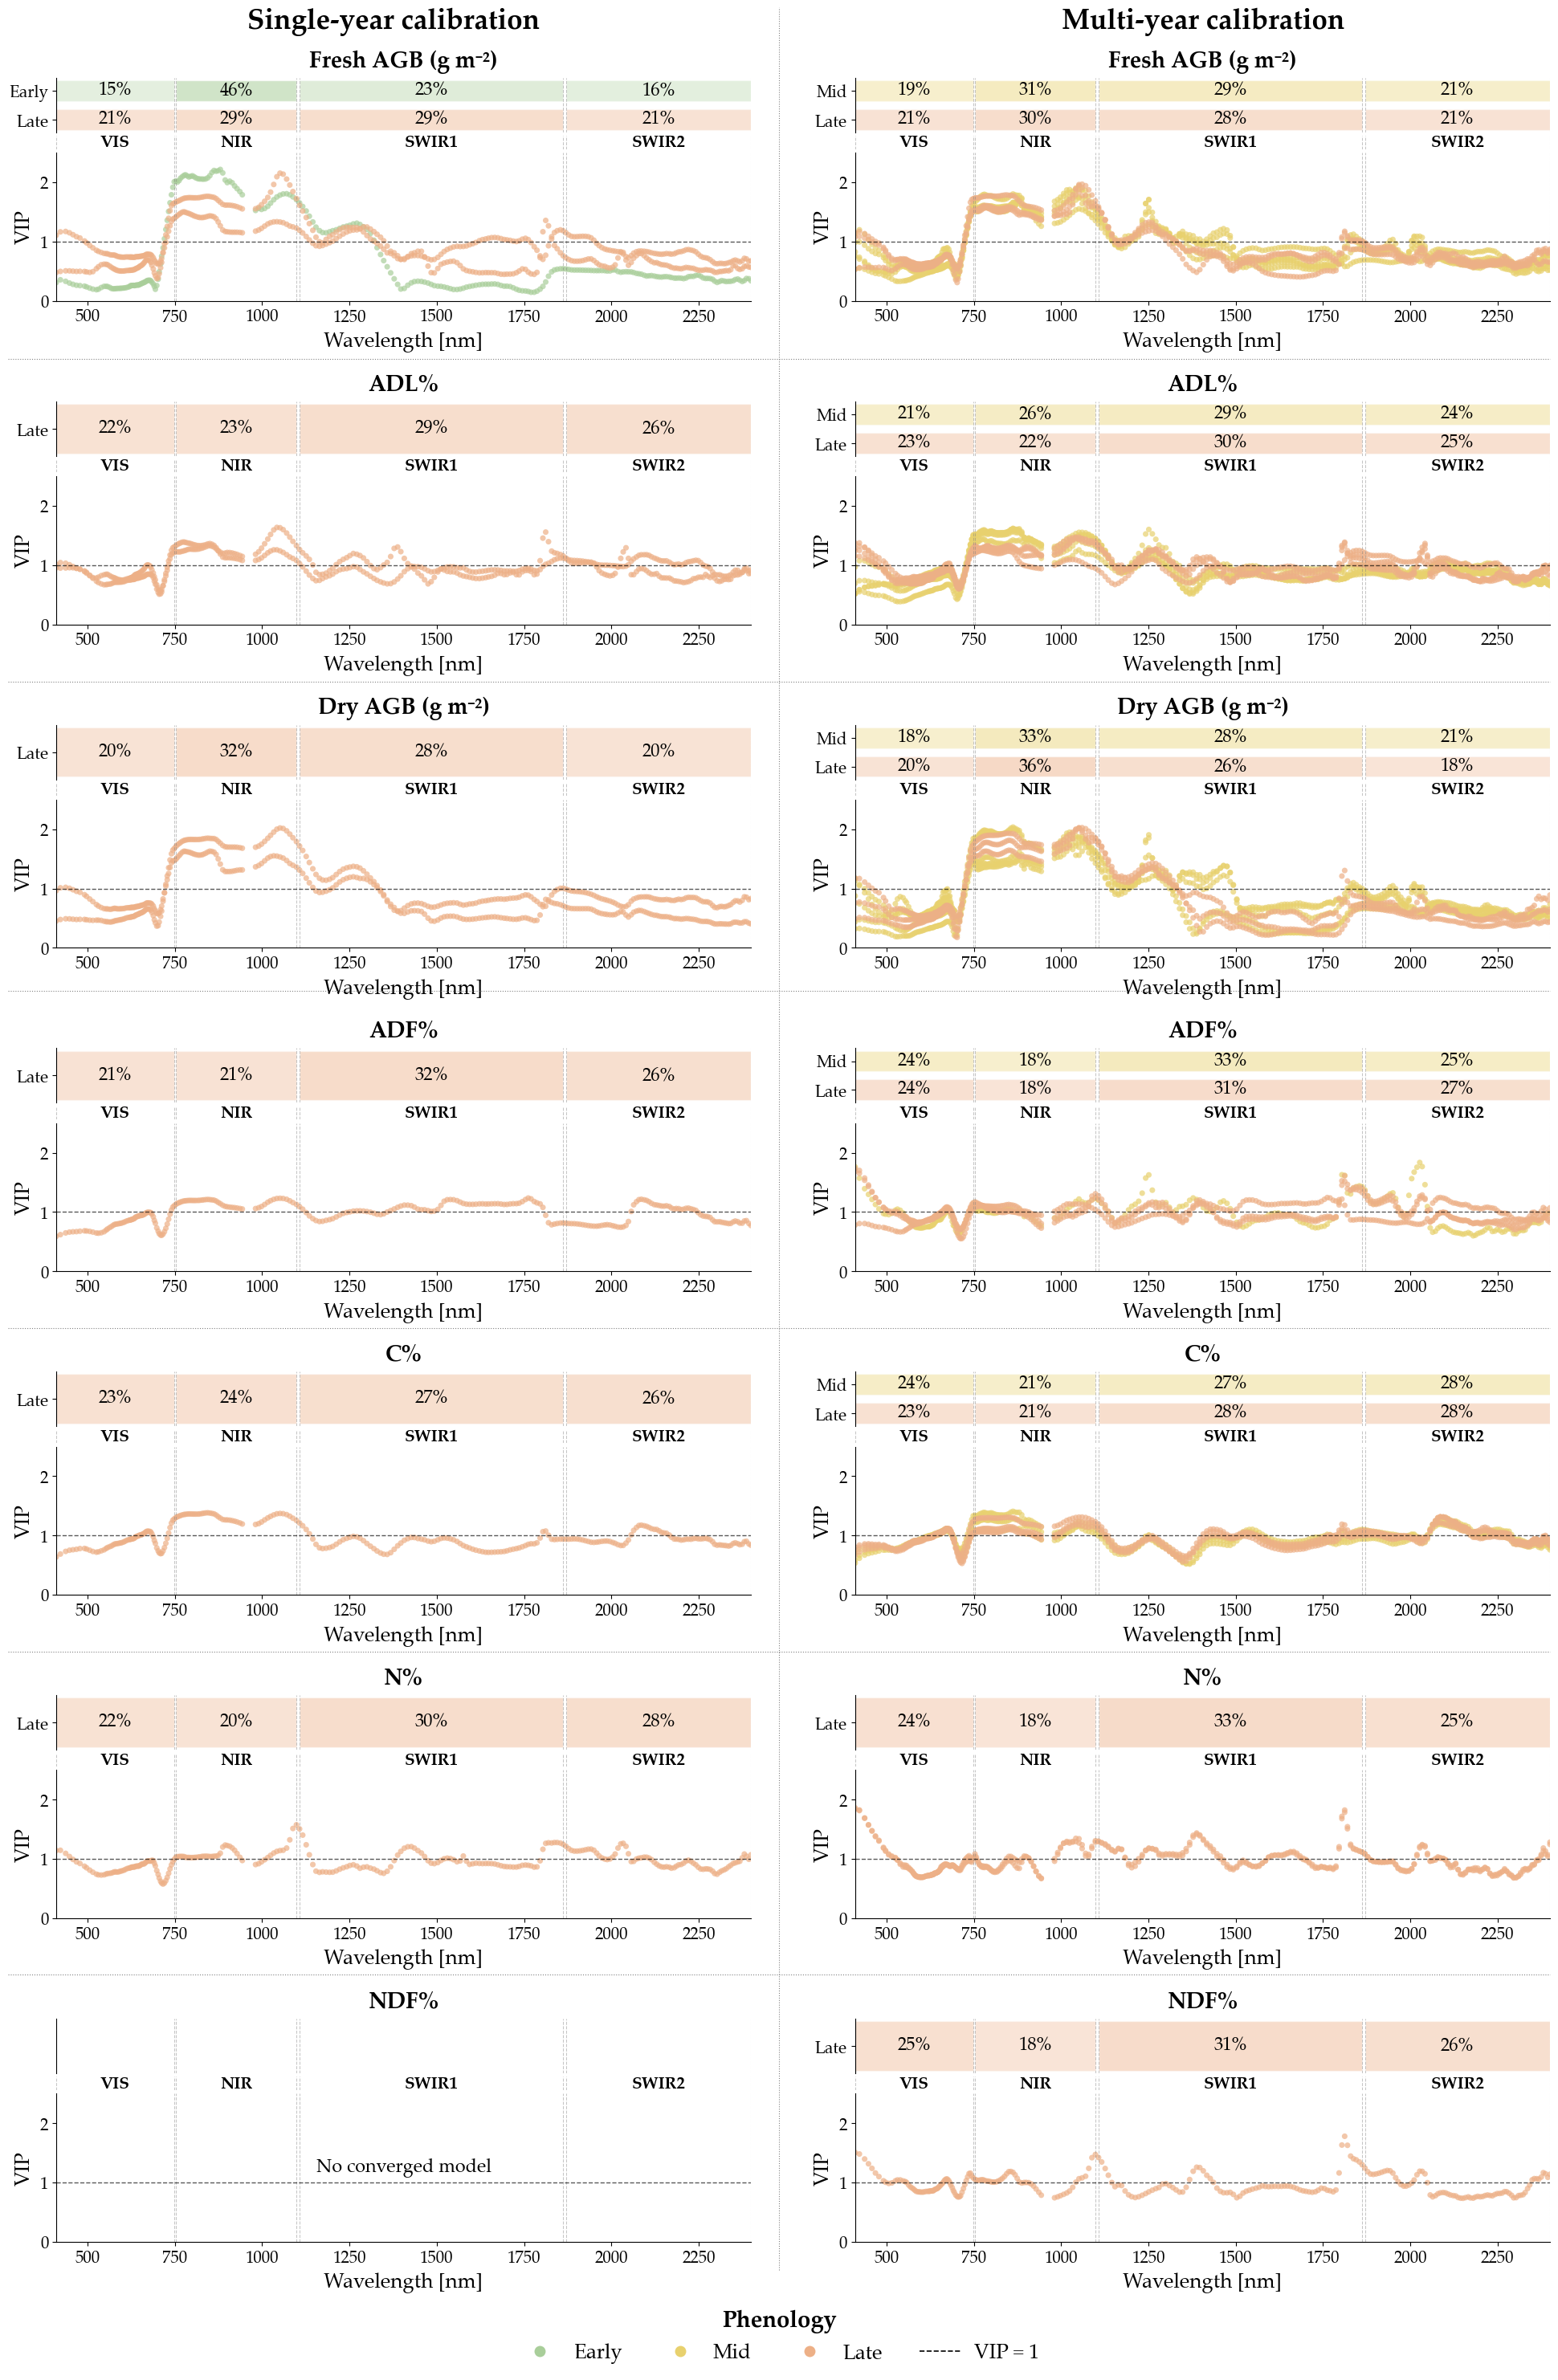

In [64]:
# ============================================================
# APPENDIX VIP FIGURE — Single-year vs Multi-year
# Same retained-model definition as revised VIP figure/table:
# Valid_Iter >= 700 + at least one positive cross-year R²
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings("ignore")

FIGSIZE = (24, 35)
POINT_SIZE, POINT_ALPHA = 26, 0.70
base_size = 12
def rel(x): return base_size * (x + 0.3)

PHENO_COLORS_SHORT = {"early":"#A9CE9A", "mid":"#E8D16E", "late":"#EDB087"}
PHENO_LABELS_VISUAL = {"early":"Early", "mid":"Mid", "late":"Late"}
phenology_order = ["early", "mid", "late"]
calib_type_order = ["Single-year", "Multi-year"]

REGION_BANDS = {
    "VIS":(410,748), "NIR":(753,1098),
    "SWIR1":(1107,1862), "SWIR2":(1870,2400)
}
region_order = ["VIS","NIR","SWIR1","SWIR2"]

trait_order_codes = [
    "Biom_wet_g","ADL_perc","Biom_dry_g",
    "ADF_perc","C_perc","N_perc","NDF_perc"
]
trait_order_labels = [trait_labels_pub[t] for t in trait_order_codes]

def parse_folder_name_vip(folder_name):
    parts = folder_name.split("_")
    if len(parts) < 4: return None, None
    return parts[1].replace("&","-"), "_".join(parts[3:])

def vip_pheno(y):
    y = str(y)
    if y == "2010": return "early"
    if "2010" in y.split("-"): return "mid"
    return "late"

def pct_to_alpha(pct, min_alpha=0.20, max_alpha=0.95):
    return min_alpha + (max_alpha - min_alpha) * pct / 100

# # ------------------------------------------------------------
# # 1) Retained calibration models
# # ------------------------------------------------------------

# models_for_vip = models_df_expanded.copy()
# models_for_vip["Valid_Iter"] = pd.to_numeric(models_for_vip["Valid_Iter"], errors="coerce")
# models_for_vip["R2_ext_num"] = pd.to_numeric(models_for_vip["R2_ext"], errors="coerce")
# models_for_vip["Predicted_From"] = (
#     models_for_vip["Predicted_From"].astype(str).str.replace("&","-",regex=False)
# )

# valid_model_keys = (
#     models_for_vip.loc[
#         (models_for_vip["Valid_Iter"] >= 700) &
#         (models_for_vip["R2_ext_num"] > 0),
#         ["Predicted_From","Trait"]
#     ]
#     .drop_duplicates()
#     .rename(columns={"Predicted_From":"Year","Trait":"inVar"})
# )

# valid_model_keys["Calibration_type"] = np.where(
#     valid_model_keys["Year"].str.contains("-", regex=False),
#     "Multi-year","Single-year"
# )
# valid_model_keys["Phenology"] = valid_model_keys["Year"].map(vip_pheno)

# print("Retained calibration Year × Trait models:", len(valid_model_keys))

# ------------------------------------------------------------
# 1) ALL CONVERGED calibration models
# Convergence definition: Valid_Iter >= 700 only
# No R2_ext, R² or Iter_R2_iqr filtering
# ------------------------------------------------------------

models_for_vip = models_df_expanded.copy()

models_for_vip["Valid_Iter"] = pd.to_numeric(
    models_for_vip["Valid_Iter"], errors="coerce"
)

models_for_vip["Predicted_From"] = (
    models_for_vip["Predicted_From"]
    .astype(str)
    .str.replace("&", "-", regex=False)
)

valid_model_keys = (
    models_for_vip.loc[
        models_for_vip["Valid_Iter"] >= 700,
        ["Predicted_From", "Trait"]
    ]
    .drop_duplicates()
    .rename(columns={
        "Predicted_From": "Year",
        "Trait": "inVar"
    })
)

# Derive calibration type directly from calibration-year structure
valid_model_keys["Calibration_type"] = np.where(
    valid_model_keys["Year"].str.contains("-", regex=False),
    "Multi-year",
    "Single-year"
)

# Assign calibration phenology
valid_model_keys["Phenology"] = valid_model_keys["Year"].map(vip_pheno)

print("Converged calibration Year × Trait models:", len(valid_model_keys))


# ------------------------------------------------------------
# 2) Build wavelength-level VIP table
# ------------------------------------------------------------

vip_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:
    year_val, trait_val = parse_folder_name_vip(folder.name)
    if year_val is None or trait_val not in trait_order_codes:
        continue

    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips = pd.read_csv(max(vips_files, key=iter_n)).drop(
        columns=["Unnamed: 0"], errors="ignore"
    )
    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]
    if not vip_cols:
        continue

    vip_mean = vips[vip_cols].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    for col in vip_cols:
        wvl = float(col)
        region = spectral_region(wvl)
        if pd.isna(region):
            continue

        vip_rows.append({
            "Year":year_val,
            "inVar":trait_val,
            "Trait_label":trait_labels_pub[trait_val],
            "Wavelength":wvl,
            "Region":region,
            "VIP":float(vip_mean[col])
        })

vip_long_all = pd.DataFrame(vip_rows)
if vip_long_all.empty:
    raise ValueError("No usable VIP files were found.")

vip_long_all = vip_long_all.merge(
    valid_model_keys,
    on=["Year","inVar"],
    how="inner",
    validate="many_to_one"
)

vip_long_all["Phenology"] = pd.Categorical(
    vip_long_all["Phenology"], categories=phenology_order, ordered=True
)
vip_long_all["Trait_label"] = pd.Categorical(
    vip_long_all["Trait_label"], categories=trait_order_labels, ordered=True
)
vip_long_all["Calibration_type"] = pd.Categorical(
    vip_long_all["Calibration_type"], categories=calib_type_order, ordered=True
)

vip_long_all = vip_long_all.sort_values(
    ["Trait_label","Calibration_type","Phenology","Year","Wavelength"]
).reset_index(drop=True)

print(
    "Retained Year × Trait VIP models:",
    vip_long_all[["Year","inVar"]].drop_duplicates().shape[0]
)

# ------------------------------------------------------------
# 3) Draw one Trait × Calibration-type panel
# ------------------------------------------------------------

def draw_trait_calib_panel(fig, outer_spec, trait_code, trait_label, calib_type):
    subgs = outer_spec.subgridspec(3,1,height_ratios=[1.25,0.30,3.4],hspace=0.05)
    ax_top = fig.add_subplot(subgs[0,0])
    ax_region = fig.add_subplot(subgs[1,0],sharex=ax_top)
    ax_main = fig.add_subplot(subgs[2,0],sharex=ax_top)

    dtrait = vip_long_all[
        (vip_long_all["inVar"] == trait_code) &
        (vip_long_all["Calibration_type"] == calib_type)
    ].copy()

    for ax in [ax_top,ax_region,ax_main]:
        for _,(x0,x1) in REGION_BANDS.items():
            ax.axvline(x0,color="grey",lw=0.75,ls="--",alpha=0.45)
            ax.axvline(x1,color="grey",lw=0.75,ls="--",alpha=0.45)

    ax_top.set_xlim(410,2400)
    ax_region.set_xlim(410,2400)
    ax_main.set_xlim(410,2400)
    ax_main.set_ylim(0,2.5)

    if dtrait.empty:
        ax_main.text(
            0.5,0.5,"No converged model",
            ha="center",va="center",
            fontsize=rel(1.1),transform=ax_main.transAxes
        )
        ax_top.set_title(trait_label,fontsize=rel(1.4),fontweight="bold",pad=10)
        ax_top.set_yticks([])
    else:
        active_ph = [
            p for p in phenology_order
            if p in dtrait["Phenology"].dropna().astype(str).unique()
        ]

        # Regional VIP %
        share = (
            dtrait.groupby(["Phenology","Region"], observed=True)["VIP"]
            .sum().reset_index()
        )
        share["Total"] = share.groupby("Phenology", observed=True)["VIP"].transform("sum")
        share["VIP_pct"] = 100 * share["VIP"] / share["Total"]

        wide = (
            share.pivot(index="Phenology",columns="Region",values="VIP_pct")
            .reindex(index=active_ph,columns=region_order)
            .fillna(0)
        )

        # Integer percentages summing exactly to 100
        wide_int = wide.copy()
        for idx in wide.index:
            vals = wide.loc[idx].values
            ints = np.floor(vals).astype(int)
            remainder = 100 - ints.sum()
            order = np.argsort(vals - ints)[::-1]
            ints[order[:remainder]] += 1
            wide_int.loc[idx] = ints

        ypos = np.arange(len(active_ph))

        for i,ph in enumerate(active_ph):
            for reg in region_order:
                pct = float(wide_int.loc[ph,reg])
                if pct <= 0: continue
                x0,x1 = REGION_BANDS[reg]

                ax_top.barh(
                    i,x1-x0,left=x0,height=0.72,
                    color=PHENO_COLORS_SHORT[ph],
                    alpha=pct_to_alpha(pct),
                    edgecolor="white",linewidth=1
                )
                ax_top.text(
                    (x0+x1)/2,i,f"{pct:.0f}%",
                    ha="center",va="center",fontsize=rel(1.05)
                )

        ax_top.set_yticks(ypos)
        ax_top.set_yticklabels(
            [PHENO_LABELS_VISUAL[p] for p in active_ph],
            fontsize=rel(0.95)
        )
        ax_top.invert_yaxis()
        ax_top.set_title(trait_label,fontsize=rel(1.4),fontweight="bold",pad=10)

        # Wavelength-level VIP
        for ph in active_ph:
            d = dtrait[dtrait["Phenology"].astype(str) == ph]
            ax_main.scatter(
                d["Wavelength"],d["VIP"],
                s=POINT_SIZE,alpha=POINT_ALPHA,
                color=PHENO_COLORS_SHORT[ph],
                edgecolor="none",
                label=PHENO_LABELS_VISUAL[ph]
            )

    # Region labels
    ax_region.set_ylim(0,1)
    ax_region.set_yticks([])

    for reg,(x0,x1) in REGION_BANDS.items():
        ax_region.text(
            (x0+x1)/2,0.5,reg,
            ha="center",va="center",
            fontsize=rel(0.95),fontweight="bold"
        )

    ax_main.axhline(1,color="black",lw=1,ls="--",alpha=0.65)
    ax_main.set_xlabel("Wavelength [nm]",fontsize=rel(1.25),labelpad=5)
    ax_main.set_ylabel("VIP",fontsize=rel(1.25))
    ax_main.tick_params(axis="both",labelsize=rel(0.95))

    ax_top.tick_params(axis="x",bottom=False,labelbottom=False)
    ax_region.tick_params(axis="x",bottom=False,labelbottom=False)

    for ax in [ax_top,ax_region,ax_main]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax_top.spines["bottom"].set_visible(False)
    ax_region.spines["left"].set_visible(False)
    ax_region.spines["bottom"].set_visible(False)
    ax_region.spines["top"].set_visible(False)

# ------------------------------------------------------------
# 4) Figure layout
# ------------------------------------------------------------

fig = plt.figure(figsize=FIGSIZE)

outer_gs = fig.add_gridspec(
    nrows=len(trait_order_codes),
    ncols=2,
    wspace=0.15,
    hspace=0.45
)

for row,trait_code in enumerate(trait_order_codes):
    for col,calib_type in enumerate(calib_type_order):
        draw_trait_calib_panel(
            fig,
            outer_gs[row,col],
            trait_code,
            trait_labels_pub[trait_code],
            calib_type
        )

# Column headers
fig.text(
    0.300,0.905,"Single-year calibration",
    ha="center",va="top",
    fontsize=rel(1.8),fontweight="bold"
)

fig.text(
    0.720,0.905,"Multi-year calibration",
    ha="center",va="top",
    fontsize=rel(1.8),fontweight="bold"
)

# Shared legend
legend_handles = [
    Line2D(
        [0],[0],marker="o",linestyle="None",markersize=10,
        markerfacecolor=PHENO_COLORS_SHORT[p],markeredgecolor="none",
        label=PHENO_LABELS_VISUAL[p]
    )
    for p in phenology_order
]

vip_line = Line2D(
    [0],[0],color="black",lw=1.2,ls="--",label="VIP = 1"
)

fig.legend(
    handles=legend_handles+[vip_line],
    title="Phenology",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5,0.06),
    ncol=4,
    fontsize=rel(1.25),
    title_fontproperties={"weight":"bold","size":rel(1.45)},
    columnspacing=1.8,
    handletextpad=0.6
)

# Grid separators
fig.add_artist(Line2D(
    [0.50,0.50],[0.1,0.905],
    transform=fig.transFigure,
    color="gray",lw=0.8,ls=":"
))

for y in [0.78,0.665,0.555,0.435,0.320,0.205]:
    fig.add_artist(Line2D(
        [0.10,0.90],[y,y],
        transform=fig.transFigure,
        color="gray",lw=0.8,ls=":"
    ))

plt.tight_layout(rect=[0,0.04,1,0.965])

# # -------------------------
# # Save if needed
# # -------------------------

# fig.savefig(
#     output_path("PPR2_APPENDIX_Figure_VIPS_single_vs_multi_Revised.pdf"),
#     bbox_inches="tight", pad_inches=0.05
# )
# fig.savefig(
#     output_path("PPR2_APPENDIX_Figure_VIPS_single_vs_multi_Revised.png"),
#     bbox_inches="tight", pad_inches=0.05, dpi=600
# )

plt.show()

Loading: Fresh AGB | 2012 to 2013
Loading: Fresh AGB | 2010-2011-2012 to 2013
Loading: Fresh AGB | 2013 to 2013 reference
Loading: ADL% | 2012 to 2013
Loading: ADL% | 2010-2012 to 2013
Loading: ADL% | 2013 to 2013 reference


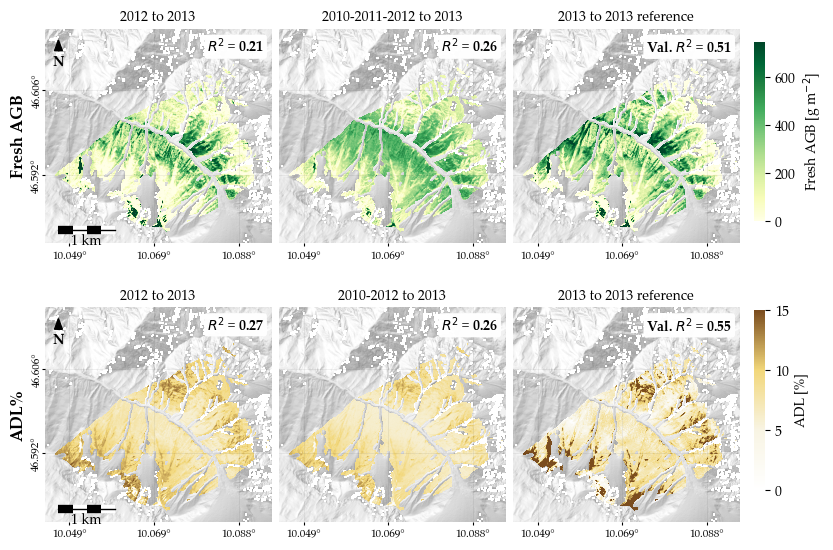

In [65]:
# ============================================================
### PPR3 Simple Map Grid [Exploring The Mapping Options]
# ============================================================

import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.vrt import WarpedVRT
from rasterio.transform import Affine
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import FancyArrow
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from glob import glob
from pyproj import Transformer
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

# Create an input folder variable
# the_input_folder = r"F:/ALL_ABOUT_PLOTS/PPR2_ACCURATE_Polygon_Shapefiles/"

# Helper function to join folder and filename to be used when reading the data
def input_path(filename):
    return os.path.join(the_input_folder, filename)

# Create an output folder variable
the_output_folder = "C:/Users/.../PPR2_FIGURES&TABLES"

# Helper function to join folder and filename to be used when saving output
def output_path(filename):
    return os.path.join(the_output_folder, filename)

# ------------------------------------------------------------
# INPUTS
# ------------------------------------------------------------
# MIN_DIR = r"D:/Biomass_Maps_Minnaert"

# OUT_DIR = r"D:/PPR3_Trait_MAPS_Minnaert_year_comparison"
# os.makedirs(OUT_DIR, exist_ok=True)

HILLSHADES = {
    2010: r"C:/Users/.../Slope&Aspect+DTM_copy_of_original/hillshades_by_year/hillshade_2010_az130.8_alt59.4.tif",
    2011: r"C:/Users/.../Slope&Aspect+DTM_copy_of_original/hillshades_by_year/hillshade_2011_az233.0_alt57.9.tif",
    2012: r"C:/Users/.../Slope&Aspect+DTM_copy_of_original/hillshades_by_year/hillshade_2012_az114.2_alt51.6.tif",
    2013: r"C:/Users/.../Slope&Aspect+DTM_copy_of_original/hillshades_by_year/hillshade_2013_az140.9_alt60.7.tif",
}

# # Choose year comparisons here
# YEAR_PAIRS = [
#     (2010, 2011),
#     (2010, 2012),
#     (2010, 2013),
#     (2011, 2012),
#     (2011, 2013),
#     (2012, 2013),
# ]

MAPS = [
    ("Fresh AGB", "2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/Fresh_AGB_coef2012_to2013_Minnaert_grass.tif")),
    ("Fresh AGB", "2010-2011-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/Fresh_AGB_coef2010-2011-2012_to2013_Minnaert_grass.tif")),
    ("Fresh AGB", "2013 to 2013 reference", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/Fresh_AGB_coef2013_to2013_Minnaert_grass.tif")),
    ("ADL%", "2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/ADL_coef2012_to2013_Minnaert_grass.tif")),
    ("ADL%", "2010-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/ADL_coef2010-2012_to2013_Minnaert_grass.tif")),
    # ("ADL%", "2011-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/ADL_coef2011-2012_to2013_Minnaert_grass.tif")),
    # ("ADL%", "2010-2011-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/ADL_coef2010-2011-2012_to2013_Minnaert_grass.tif")),
    ("ADL%", "2013 to 2013 reference", Path(r"C:/Users/.../.../3rd-paper/PPR3_FIGURES&TABLES/PPR3_Trait_Maps/ADL_coef2013_to2013_Minnaert_grass.tif")),
]

# R2t_stats = [
#     ("R² Fresh AGB", "2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2012_2026-02-01_Biom_wet_g/2012_Biom_wet_g_MAIN_MODELs-avg-STATISTICS.csv")),
#     ("R² Fresh AGB", "2010-2011-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2010&2011&2012_2026-02-02_Biom_wet_g/2010&2011&2012_Biom_wet_g_MAIN_MODELs-avg-STATISTICS.csv")),
#     ("R² Fresh AGB", "2013 to 2013 reference", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2013_2026-02-01_Biom_wet_g/2013_Biom_wet_g_MAIN_MODELs-avg-STATISTICS.csv")),
#     ("R² ADL%", "2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2012_2026-02-01_ADL_perc/2012_ADL_perc_MAIN_MODELs-avg-STATISTICS.csv")),
#     ("R² ADL%", "2010-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2010&2012_2026-02-01_ADL_perc/2010&2012_ADL_perc_MAIN_MODELs-avg-STATISTICS.csv")),
#     # ("R² ADL%", "2011-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2011&2012_2026-02-02_ADL_perc/2011&2012_ADL_perc_MAIN_MODELs-avg-STATISTICS.csv")),
#     # ("R² ADL%", "2010-2011-2012 to 2013", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2010&2011&2012_2026-02-02_ADL_perc/2010&2011&2012_ADL_perc_MAIN_MODELs-avg-STATISTICS.csv")),
#     ("R² ADL%", "2013 to 2013 reference", Path(r"C:/Users/.../.../3rd-paper/PPR3_input_files/PPR3_Transferrable_Models_copied/PPR2_2013_2026-02-01_ADL_perc/2013_ADL_perc_MAIN_MODELs-avg-STATISTICS.csv")),
# ]

BIOMASS_UNITS = "g m$^{-2}$"
ADL_UNITS = "[%]"

# Optional zoom-in region
USE_ZOOM = True
LON_MIN, LON_MAX = 10.04271, 10.09669
LAT_MIN, LAT_MAX = 46.58205, 46.61502

plt.rcParams.update({
    "font.family": "palatino linotype",
    "font.size": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

overlay_alpha = 1
hillshade_alpha = 0.4

adl_cmap = LinearSegmentedColormap.from_list(
    "adl_yellow_brown",
    ["#FFFFFF", "#f8f4e3", "#f2d77a", "#7a4c1e"]
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

# def path_min(y):
#     files = glob(os.path.join(MIN_DIR, f"Minnaert_{y}*_grass.tif"))
#     if len(files) == 0:
#         raise FileNotFoundError(f"No Minnaert grass map found for {y}")
#     if len(files) > 1:
#         print(f" Multiple Minnaert files found for {y}. Using first:")
#         for f in files:
#             print("   ", f)
#     return files[0]


def raster_extent(profile):
    T = profile["transform"]
    w, h = profile["width"], profile["height"]
    left = T.c
    top = T.f
    right = left + T.a * w
    bottom = top + T.e * h
    return (left, right, bottom, top)


def load_reference_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None and np.isfinite(src.nodata):
            arr[arr == src.nodata] = np.nan
        profile = src.profile
    return arr, profile


def load_raster_match_safe(src_path, ref_profile, resampling=Resampling.bilinear):
    H, W = ref_profile["height"], ref_profile["width"]
    dst = np.full((H, W), np.nan, dtype="float32")

    try:
        with rasterio.open(src_path) as src:
            src_nodata = src.nodata if src.nodata is not None else np.nan

            reproject(
                source=rasterio.band(src, 1),
                destination=dst,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src_nodata if np.isfinite(src_nodata) else None,
                dst_transform=ref_profile["transform"],
                dst_crs=ref_profile["crs"],
                dst_nodata=np.nan,
                resampling=resampling
            )
        return dst

    except Exception:
        with rasterio.open(src_path) as src:
            vrt_opts = dict(
                crs=ref_profile["crs"],
                transform=ref_profile["transform"],
                height=H,
                width=W,
                resampling=resampling
            )
            with WarpedVRT(src, **vrt_opts) as vrt:
                arr = vrt.read(1, out_shape=(H, W)).astype("float32", copy=False)
                nod = vrt.nodata
                if nod is not None and np.isfinite(nod):
                    arr[arr == nod] = np.nan
                return arr


def crop_to_lonlat(arrays, profile, lon_min, lon_max, lat_min, lat_max):
    to_proj = Transformer.from_crs(4326, profile["crs"], always_xy=True)

    xmin, ymin = to_proj.transform(lon_min, lat_min)
    xmax, ymax = to_proj.transform(lon_max, lat_max)

    xmin, xmax = sorted([xmin, xmax])
    ymin, ymax = sorted([ymin, ymax])

    T = profile["transform"]
    xres, yres = T.a, -T.e
    x0, y0 = T.c, T.f
    H, W = profile["height"], profile["width"]

    col0 = max(0, int(np.floor((xmin - x0) / xres)))
    col1 = min(W, int(np.ceil((xmax - x0) / xres)))
    row0 = max(0, int(np.floor((y0 - ymax) / yres)))
    row1 = min(H, int(np.ceil((y0 - ymin) / yres)))

    if not ((row1 > row0) and (col1 > col0)):
        print(" Zoom window empty. Using full extent.")
        return arrays, profile, raster_extent(profile)

    cropped = [a[row0:row1, col0:col1] for a in arrays]

    T_zoom = T * Affine.translation(col0, row0)
    profile_zoom = profile.copy()
    profile_zoom.update(
        transform=T_zoom,
        height=row1 - row0,
        width=col1 - col0
    )

    extent = (xmin, xmax, ymin, ymax)

    return cropped, profile_zoom, extent


def nanmask(arr):
    return np.ma.masked_invalid(arr)


def clamp_nonnegative(a):
    out = a.copy()
    np.copyto(out, 0.0, where=np.isfinite(out) & (out < 0))
    return out


def add_north_arrow(ax, extent, size_frac=0.08):
    left, right, bottom, top = extent
    W, H = right - left, top - bottom

    x = left + 0.06 * W
    y = top - 0.10 * H
    length = size_frac * min(W, H)

    ax.add_patch(
        FancyArrow(
            x, y,
            0, length * 0.8,
            width=0.0,
            head_width=0.035 * W,
            head_length=0.05 * H,
            length_includes_head=True,
            color="k"
        )
    )

    ax.text(
        x,
        y - 0.02 * H,
        "N",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )


def add_scalebar(ax, extent, meters=1000, segments=4, pad_frac=0.06, label="1 km"):
    left, right, bottom, top = extent
    W, H = right - left, top - bottom

    x0 = left + pad_frac * W
    y0 = bottom + pad_frac * H
    seg_len = meters / segments

    for i in range(segments):
        x_start = x0 + i * seg_len
        x_end = x_start + seg_len
        color = "k" if i % 2 == 0 else "w"

        ax.plot(
            [x_start, x_end],
            [y0, y0],
            lw=6,
            color=color,
            solid_capstyle="butt"
        )

    ax.plot([x0, x0 + meters], [y0, y0], lw=1, color="k")

    ax.text(
        x0 + meters / 2,
        y0 - 0.02 * H,
        label,
        ha="center",
        va="top",
        fontsize=10
    )

def set_lonlat_ticks(ax, extent, proj_crs, n_lon=3, n_lat=3):
    left, right, bottom, top = extent
    transformer = Transformer.from_crs(proj_crs, 4326, always_xy=True)

    def fmt_lon(x, pos):
        lon, _ = transformer.transform(x, (bottom + top) / 2)
        return f"{lon:.3f}°"

    def fmt_lat(y, pos):
        _, lat = transformer.transform((left + right) / 2, y)
        return f"{lat:.3f}°"

    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_lon))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_lat))
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))

    ax.tick_params(axis="both", which="both", labelsize=8, length=2)
    ax.grid(color="k", alpha=0.08, lw=0.5)

    for label in ax.get_yticklabels():
        label.set_rotation(90)
        label.set_verticalalignment("center")
        label.set_horizontalalignment("center")


def remove_all_spines(ax):
    for s in ax.spines.values():
        s.set_visible(False)

# ------------------------------------------------------------
# SIMPLE MAP GRID — transferred maps + within-year references
# ------------------------------------------------------------

# Use first map as reference grid
ref_path = MAPS[0][2]
_, ref_profile = load_reference_raster(ref_path)

R2_LABELS = {
    ("Fresh AGB", "2012 to 2013"): r"$R^2$ = 0.21",
    ("Fresh AGB", "2010-2011-2012 to 2013"): r"$R^2$ = 0.26",
    ("Fresh AGB", "2013 to 2013 reference"): r"Val. $R^2$ = 0.51",

    ("ADL%", "2012 to 2013"): r"$R^2$ = 0.27",
    ("ADL%", "2010-2012 to 2013"): r"$R^2$ = 0.26",
    # ("ADL%", "2011-2012 to 2013"): r"$R^2_t$ = 0.20",
    # ("ADL%", "2010-2011-2012 to 2013"): r"$R^2_t$ = 0.19",
    ("ADL%", "2013 to 2013 reference"): r"Val. $R^2$ = 0.55",
}

# Load 2013 hillshade because all maps predict 2013
shade = load_raster_match_safe(HILLSHADES[2013], ref_profile, Resampling.bilinear)

loaded = []
vals_by_trait = {"Fresh AGB": [], "ADL%": []}

for trait, label, path in MAPS:
    print(f"Loading: {trait} | {label}")
    arr = load_raster_match_safe(path, ref_profile, Resampling.bilinear)

    # if trait == "Fresh AGB":
    #     arr = clamp_nonnegative(arr)
    
    if trait in ["Fresh AGB", "ADL%"]:
        arr = clamp_nonnegative(arr)

    if USE_ZOOM:
        arrays, ref_profile_zoom, extent = crop_to_lonlat(
            [arr, shade],
            ref_profile,
            LON_MIN, LON_MAX,
            LAT_MIN, LAT_MAX
        )
        arr_z, shade_z = arrays
        plot_profile = ref_profile_zoom
    else:
        arr_z = arr
        shade_z = shade
        plot_profile = ref_profile
        extent = raster_extent(ref_profile)

    loaded.append((trait, label, arr_z))

    v = arr_z[np.isfinite(arr_z)]
    if v.size:
        vals_by_trait[trait].append(v)

# Trait-specific color ranges
scale = {}

for trait, vals in vals_by_trait.items():
    if vals:
        pooled = np.concatenate(vals)

        if trait == "ADL%":
            vmin, vmax = 0, 15
            # vmin, vmax = np.nanpercentile(pooled, [7, 98])
            # vmin = max(0, vmin)   # avoid negative ADL display scale
            
        elif trait == "Fresh AGB":
            vmin, vmax = np.nanpercentile(pooled, [2, 98])
            vmin = max(0, vmin)
        else:
            vmin, vmax = np.nanpercentile(pooled, [2, 98])

        scale[trait] = (float(vmin), float(vmax))
    else:
        scale[trait] = (0, 1)

# Hillshade range
hs_valid = shade_z[np.isfinite(shade_z)]
hs_vmin, hs_vmax = (
    np.nanpercentile(hs_valid, [2, 98])
    if hs_valid.size else (0, 1)
)

fresh_maps = [(label, arr) for trait, label, arr in loaded if trait == "Fresh AGB"]
adl_maps   = [(label, arr) for trait, label, arr in loaded if trait == "ADL%"]

ncols = max(len(fresh_maps), len(adl_maps))
fig, axes = plt.subplots(
    nrows=2,
    ncols=ncols,
    figsize= (3.0 * ncols, 6.4), #(3.3 * ncols, 6.6),
    constrained_layout=False
)

plt.subplots_adjust(wspace=0.02, hspace=0.30, right=0.90)
# plt.subplots_adjust(wspace=0.05, hspace=0.16)
# plt.subplots_adjust(wspace=0.05, hspace=0.35)
# plt.subplots_adjust(wspace=0.05, hspace=0.45)

# Make sure axes is always 2D
axes = np.asarray(axes)

im_fresh = None
im_adl = None

for row_idx, (trait, maps, cmap, unit) in enumerate([
    ("Fresh AGB", fresh_maps, "YlGn", "g m$^{-2}$"),
    ("ADL%", adl_maps, adl_cmap, "%"),
]):
    vmin, vmax = scale[trait]

    for col_idx in range(ncols):
        ax = axes[row_idx, col_idx]

        if col_idx >= len(maps):
            ax.axis("off")
            continue

        label, arr = maps[col_idx]

        ax.imshow(
            nanmask(shade_z),
            cmap="gray",
            vmin=hs_vmin,
            vmax=hs_vmax,
            alpha=hillshade_alpha,
            extent=extent
        )

        im = ax.imshow(
            nanmask(arr),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=overlay_alpha,
            extent=extent
        )

        if trait == "Fresh AGB":
            im_fresh = im
        else:
            im_adl = im

        ax.set_title(label, fontsize=10)
        
        r2_text = R2_LABELS.get((trait, label), "")

        if r2_text:
            ax.text(
                0.97, 0.96,
                r2_text,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.99, #0.75
                    boxstyle="round,pad=0.20"
                )
            )

        # if col_idx == 0:
        #     ax.set_ylabel(trait, fontsize=12, fontweight="bold")
        #     set_lonlat_ticks(ax, extent, plot_profile["crs"], n_lon=3, n_lat=3)
        #     add_north_arrow(ax, extent, size_frac=0.06)
        #     add_scalebar(ax, extent, meters=1000, segments=4, label="1 km")
        # else:
        #     ax.set_xticks([])
        #     ax.set_yticks([])
        
        # # Latitude/longitude ticks on all maps
        # set_lonlat_ticks(ax, extent, plot_profile["crs"], n_lon=3, n_lat=3)
        
        # Longitude ticks on all maps
        set_lonlat_ticks(ax, extent, plot_profile["crs"], n_lon=3, n_lat=3)

        # Latitude labels only on first column
        if col_idx != 0:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)

        # Keep row label, north arrow, and scale bar only on first map of each row
        if col_idx == 0:
            ax.set_ylabel(trait, fontsize=12, fontweight="bold")
            add_north_arrow(ax, extent, size_frac=0.06)
            add_scalebar(ax, extent, meters=1000, segments=4, label="1 km")
        else:
            ax.set_ylabel("")

        remove_all_spines(ax)

# Colorbars
# cbar1 = fig.colorbar(
#     im_fresh,
#     ax=axes[0, :len(fresh_maps)],
#     orientation="horizontal",
#     fraction=0.045,
#     pad=0.08
# )
# cbar1.set_label("Fresh AGB [g m$^{-2}$]")
# cbar1.outline.set_visible(False)

# cbar2 = fig.colorbar(
#     im_adl,
#     ax=axes[1, :len(adl_maps)],
#     orientation="horizontal",
#     fraction=0.045,
#     pad=0.08
# )

# Right-side colorbar for Fresh AGB row
cax1 = fig.add_axes([0.915, 0.58, 0.012, 0.28])  # [left, bottom, width, height]
cbar1 = fig.colorbar(im_fresh, cax=cax1, orientation="vertical")
cbar1.set_label("Fresh AGB [g m$^{-2}$]", fontsize=10)
cbar1.ax.tick_params(labelsize=10)
cbar1.outline.set_visible(False)

# Right-side colorbar for ADL row
cax2 = fig.add_axes([0.915, 0.16, 0.012, 0.28])
cbar2 = fig.colorbar(im_adl, cax=cax2, orientation="vertical")
cbar2.set_label("ADL [%]", fontsize=10)
cbar2.ax.tick_params(labelsize=10)
cbar2.outline.set_visible(False)

# ADL ticks from 0 to max 15 without decimals
cbar2.set_ticks([0, 5, 10, 15])
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

cbar2.set_label("ADL [%]")
cbar2.outline.set_visible(False)

# # -------------------------
# # Save figure (PNG, 600 dpi & PDF)
# # -------------------------
# # pad_inches trims excess outer whitespace without altering any figure element(s)
# fig.savefig(output_path("PPR2_Simple_Trait_Prediction_Map_Grid.pdf"), bbox_inches="tight", pad_inches=0.05, dpi=600) # dpi=300
# fig.savefig(output_path("PPR2_Simple_Trait_Prediction_Map_Grid.png"), bbox_inches="tight", pad_inches=0.05, dpi=600)

plt.show()


In [66]:
# ============================================================
# EXPORT FORMATTING — Trait-specific cross-year residual R² matrices
# Formatting only; no new statistics are calculated
# ============================================================

from openpyxl import load_workbook
from openpyxl.styles import PatternFill

GREEN_FILL = PatternFill(
    start_color="D9F2D9",
    end_color="D9F2D9",
    fill_type="solid"
)

def safe_filename(s):
    return (
        str(s)
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("⁻", "-")
        .replace("²", "2")
        .replace("%", "perc")
        .replace("·", "_")
        .replace("—", "-")
        .replace("/", "-")
    )

def apply_excel_formatting(file_path, sheet_name="Residual_R2"):
    wb = load_workbook(file_path)
    ws = wb[sheet_name]

    for row in ws.iter_rows(min_row=2, min_col=2):
        for cell in row:
            v = cell.value

            if v is None or (isinstance(v, float) and np.isnan(v)):
                cell.value = None
                continue

            if isinstance(v, (int, float, np.integer, np.floating)):
                cell.number_format = "0.000" if abs(v) < 0.01 else "0.00"

                # Non-negative cross-year residual R²
                if v >= 0:
                    cell.fill = GREEN_FILL

    wb.save(file_path)
    wb.close()

# ============================================================
# OPTIONAL EXPORT — one XLSX per trait
# Requires: traits, make_transfer_matrix(), output_path()
# ============================================================

# for trait in traits:
#     _, matrix = make_transfer_matrix(trait)
#
#     file_path = output_path(
#         f"PPR2_Appendix_TransferMatrix_{safe_filename(trait)}.xlsx"
#     )
#
#     with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
#         matrix.to_excel(
#             writer,
#             sheet_name="Residual_R2",
#             index=True
#         )
#
#     apply_excel_formatting(
#         file_path,
#         sheet_name="Residual_R2"
#     )
#
# print(f"Saved {len(traits)} formatted transfer-matrix files.")

In [67]:
# ============================================================
# Global min/max cross-year residual R² + corresponding cases
# ============================================================

df_temp = models_df_expanded.copy()
df_temp["R2_ext_num"] = pd.to_numeric(df_temp["R2_ext"], errors="coerce")
df_temp = df_temp.dropna(subset=["R2_ext_num"])

global_min = df_temp["R2_ext_num"].min()
global_max = df_temp["R2_ext_num"].max()

extreme_cases = pd.DataFrame([
    {
        "Extreme": "Minimum",
        "Trait": df_temp.loc[df_temp["R2_ext_num"].idxmin(), "Trait"],
        "Calibration_Years": df_temp.loc[df_temp["R2_ext_num"].idxmin(), "Predicted_From"],
        "Target_Year": df_temp.loc[df_temp["R2_ext_num"].idxmin(), "Input_Year"],
        "Residual_R2": global_min
    },
    {
        "Extreme": "Maximum",
        "Trait": df_temp.loc[df_temp["R2_ext_num"].idxmax(), "Trait"],
        "Calibration_Years": df_temp.loc[df_temp["R2_ext_num"].idxmax(), "Predicted_From"],
        "Target_Year": df_temp.loc[df_temp["R2_ext_num"].idxmax(), "Input_Year"],
        "Residual_R2": global_max
    }
])

print("Global residual R² range:",
      round(global_min, 3), "to", round(global_max, 3))

display(extreme_cases.round({"Residual_R2": 3}))

Global residual R² range: -19.412 to 0.273


,Extreme,Trait,Calibration_Years,Target_Year,Residual_R2
0,Minimum,ADL_perc,2011-2012-2013,2010,-19.4120
1,Maximum,ADL_perc,2012,2013,0.2730


In [68]:
# ============================================================
# Block 2 — Temporal transferability of SINGLE-YEAR models
# All converged cross-year transfer cases
# ============================================================

single_year_transfer = models_df_expanded.copy()

single_year_transfer["R2_ext"] = pd.to_numeric(
    single_year_transfer["R2_ext"], errors="coerce"
)

single_year_transfer["Valid_Iter"] = pd.to_numeric(
    single_year_transfer["Valid_Iter"], errors="coerce"
)

single_year_transfer = (
    single_year_transfer.loc[
        (~single_year_transfer["Predicted_From"].astype(str).str.contains("-", regex=False)) &
        (single_year_transfer["Valid_Iter"] >= 700) &
        (single_year_transfer["R2_ext"].notna())
    ]
    .copy()
)

# Reviewer-relevant columns; keep only those actually available
wanted_cols = [
    "Predicted_From", "Trait", "Input_Year", "Valid_Iter",
    "R2_ext", "R2_regression", "Adjusted_R2_regression",
    "Pearson_r", "Spearman_rho",
    "Bias_Predicted_minus_Observed",
    "Regression_Intercept", "Regression_Slope",
    "RMSEP_ext", "nRMSEP_SD_percent", "nRMSEP_Range_percent",
    "Iter_R2_iqr", "Iter_R2_sd",
    "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range",
    "AGDD_int_avg", "AGDD_ext_avg", "ΔAGDD", "|Δ| AGDD",
    "Phenology"
]

single_year_transfer = (
    single_year_transfer[[c for c in wanted_cols if c in single_year_transfer.columns]]
    .sort_values(["Trait", "Predicted_From", "Input_Year"])
    .reset_index(drop=True)
)

display(single_year_transfer)

,Predicted_From,Trait,Input_Year,Valid_Iter,R2_ext,R2_regression,Adjusted_R2_regression,Pearson_r,Spearman_rho,Bias_Predicted_minus_Observed,Regression_Intercept,Regression_Slope,RMSEP_ext,nRMSEP_SD_percent,nRMSEP_Range_percent,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,AGDD_int_avg,AGDD_ext_avg,ΔAGDD,|Δ| AGDD,Phenology
0,2013,ADF_perc,2010,804,-0.9927,0.0005,-0.0430,-0.0214,0.0554,2.9299,31.4703,-0.0133,5.4193,138.3124,38.3385,0.1763,0.1430,2,64.1791,11,321.5000,225.1000,96.4000,96.4000,late
1,2013,ADF_perc,2010-2011,804,-0.6228,0.0038,-0.0205,-0.0618,0.0008,1.0873,31.1771,-0.0417,4.7296,125.8988,33.4595,0.1763,0.1430,2,64.1791,11,321.5000,272.4500,49.0500,49.0500,late
2,2013,ADF_perc,2010-2011-2012,804,-0.3404,0.0192,0.0108,0.1387,0.2165,-0.1900,26.0964,0.1020,3.7181,115.2835,23.6960,0.1763,0.1430,2,64.1791,11,321.5000,292.7000,28.8000,28.8000,late
3,2013,ADF_perc,2010-2012,804,-0.3820,0.0180,0.0080,0.1341,0.2216,0.0407,26.2048,0.1028,3.7464,116.9696,23.8767,0.1763,0.1430,2,64.1791,11,321.5000,279.2000,42.3000,42.3000,late
4,2013,ADF_perc,2011,804,-0.1772,0.0802,0.0227,0.2832,0.2590,-1.4719,24.0183,0.1471,3.5564,105.4420,33.0908,0.1763,0.1430,2,64.1791,11,321.5000,319.8000,1.7000,1.7000,late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2012,N_perc,2010-2011-2013,747,-1.0737,0.0114,0.0043,-0.1066,0.1451,0.1108,2.1725,-0.0967,0.6708,143.5003,23.9146,0.4079,0.2102,2,20.2142,18,333.3000,288.8000,44.5000,44.5000,late
66,2012,N_perc,2010-2013,747,-1.1330,0.0141,0.0061,-0.1189,0.1756,0.1327,2.2048,-0.1089,0.7065,145.4636,25.1854,0.4079,0.2102,2,20.2142,18,333.3000,273.3000,60.0000,60.0000,late
67,2012,N_perc,2011,747,-0.1858,0.0630,0.0044,0.2509,0.2528,-0.0411,1.5583,0.1834,0.3302,105.8275,31.1914,0.4079,0.2102,2,20.2142,18,333.3000,319.8000,13.5000,13.5000,late
68,2012,N_perc,2011-2013,747,-1.2196,0.0385,0.0302,0.1962,0.3245,0.3035,1.8017,0.1651,0.4930,148.3514,33.3407,0.4079,0.2102,2,20.2142,18,333.3000,320.7000,12.6000,12.6000,late


In [69]:
# ============================================================
# Block 3a/2d — Does multi-year training improve stability?
# Compare ALL converged single-year vs multi-year calibration models
# ============================================================

df_stability = models_df_expanded.copy()

for c in ["Valid_Iter", "R2_ext", "Iter_R2_iqr", "Iter_R2_sd",
          "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range"]:
    if c in df_stability.columns:
        df_stability[c] = pd.to_numeric(df_stability[c], errors="coerce")

df_stability["Calibration_type"] = np.where(
    df_stability["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)

# Converged models only; no performance/stability pre-filtering
df_stability = df_stability[
    (df_stability["Valid_Iter"] >= 700) &
    (df_stability["R2_ext"].notna())
].copy()

stability_comparison = (
    df_stability
    .groupby("Calibration_type")
    .agg(
        Transfer_cases=("R2_ext", "size"),
        Positive_R2_n=("R2_ext", lambda x: (x > 0).sum()),
        Positive_R2_pct=("R2_ext", lambda x: 100 * (x > 0).mean()),
        Median_R2_ext=("R2_ext", "median"),
        Mean_R2_ext=("R2_ext", "mean"),
        Median_Iter_R2_iqr=("Iter_R2_iqr", "median"),
        Mean_Iter_R2_iqr=("Iter_R2_iqr", "mean"),
        Median_Iter_R2_sd=("Iter_R2_sd", "median"),
        Median_nComps_mode=("Iter_nComps_mode", "median"),
        Median_nComps_mode_pct=("Iter_nComps_mode_pct", "median"),
        Median_nComps_range=("Iter_nComps_range", "median")
    )
    .reindex(["Single-year", "Multi-year"])
    .round(3)
)

display(stability_comparison)

,Transfer_cases,Positive_R2_n,Positive_R2_pct,Median_R2_ext,Mean_R2_ext,Median_Iter_R2_iqr,Mean_Iter_R2_iqr,Median_Iter_R2_sd,Median_nComps_mode,Median_nComps_mode_pct,Median_nComps_range
Calibration_type,,,,,,,,,,,
Single-year,70,13,18.5710,-0.3900,-1.0180,0.1020,0.1530,0.0990,2.5000,54.9320,18.5000
Multi-year,78,23,29.4870,-0.3910,-1.7510,0.0790,0.0900,0.0690,5.5000,50.7770,17.0000


In [70]:
# ============================================================
# Block 4 — Traits with positive transfer only under multi-year calibration
# Converged models only; positive transfer = residual R² > 0
# ============================================================

df_enable = models_df_expanded.copy()

df_enable["Valid_Iter"] = pd.to_numeric(df_enable["Valid_Iter"], errors="coerce")
df_enable["R2_ext_num"] = pd.to_numeric(df_enable["R2_ext"], errors="coerce")

df_enable["Calibration_type"] = np.where(
    df_enable["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)

# Converged transfer cases only
df_enable = df_enable[
    (df_enable["Valid_Iter"] >= 700) &
    (df_enable["R2_ext_num"].notna())
].copy()

# Trait-level positive-transfer availability by calibration type
trait_enable_summary = (
    df_enable
    .assign(is_positive=lambda d: d["R2_ext_num"] > 0)
    .groupby(["Trait", "Calibration_type"])["is_positive"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "Positive_n", "count": "Total_n"})
    .reset_index()
)

trait_enable_wide = (
    trait_enable_summary
    .pivot(index="Trait", columns="Calibration_type", values="Positive_n")
    .fillna(0)
)

for c in ["Single-year", "Multi-year"]:
    if c not in trait_enable_wide.columns:
        trait_enable_wide[c] = 0

traits_multi_only = trait_enable_wide.index[
    (trait_enable_wide["Multi-year"] > 0) &
    (trait_enable_wide["Single-year"] == 0)
].tolist()

multi_only_cases = (
    df_enable[
        (df_enable["Trait"].isin(traits_multi_only)) &
        (df_enable["Calibration_type"] == "Multi-year") &
        (df_enable["R2_ext_num"] > 0)
    ]
    [[
        "Trait", "Predicted_From", "Input_Year",
        "Valid_Iter", "R2_ext_num",
        "Iter_R2_iqr", "Iter_R2_sd",
        "Iter_nComps_mode", "Iter_nComps_mode_pct",
        "Iter_nComps_range"
    ]]
    .rename(columns={"R2_ext_num": "Residual_R2"})
    .sort_values(["Trait", "Residual_R2"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Traits with positive transfer only under multi-year calibration:")
print(traits_multi_only)

display(trait_enable_wide)
display(multi_only_cases)

Traits with positive transfer only under multi-year calibration:
['ADF_perc', 'Biom_dry_g', 'C_perc', 'NDF_perc']


Calibration_type,Multi-year,Single-year
Trait,,
ADF_perc,3.0000,0.0000
ADL_perc,8.0000,4.0000
Biom_dry_g,1.0000,0.0000
Biom_wet_g,6.0000,9.0000
C_perc,4.0000,0.0000
NDF_perc,1.0000,0.0000
N_perc,0.0000,0.0000


,Trait,Predicted_From,Input_Year,Valid_Iter,Residual_R2,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range
0,ADF_perc,2012-2013,2011,1000,0.1434,0.1326,0.0825,5,36.9000,21
1,ADF_perc,2011-2013,2012,707,0.1311,0.1972,0.1295,2,50.3536,17
2,ADF_perc,2010-2012-2013,2011,997,0.0908,0.0793,0.0601,8,32.7984,16
3,Biom_dry_g,2010-2011-2012,2013,863,0.0414,0.0683,0.0531,1,74.6234,9
4,C_perc,2012-2013,2011,976,0.0488,0.0968,0.1116,2,57.8893,19
5,C_perc,2012-2013,2010-2011,976,0.0410,0.0968,0.1116,2,57.8893,19
6,C_perc,2010-2012-2013,2011,961,0.0164,0.0826,0.0866,2,62.8512,16
7,C_perc,2012-2013,2010,976,0.0123,0.0968,0.1116,2,57.8893,19
8,NDF_perc,2012-2013,2011,750,0.1802,0.0990,0.0836,6,26.4000,24


In [71]:
# ============================================================
# Block 5 — Weak but stable temporal transfer
# Weak positive transfer: 0 <= residual R² < 0.2
# Stability criterion: Iter_R2_iqr <= 0.2
# Converged models only: Valid_Iter >= 700
# ============================================================

weak_stable = models_df_expanded.copy()

for c in [
    "Valid_Iter", "R2_ext", "Iter_R2_iqr", "Iter_R2_sd",
    "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range"
]:
    if c in weak_stable.columns:
        weak_stable[c] = pd.to_numeric(weak_stable[c], errors="coerce")

weak_stable["Calibration_type"] = np.where(
    weak_stable["Predicted_From"].astype(str).str.contains("-", regex=False),
    "Multi-year", "Single-year"
)

weak_stable = (
    weak_stable.loc[
        (weak_stable["Valid_Iter"] >= 700) &
        (weak_stable["R2_ext"] >= 0) &
        (weak_stable["R2_ext"] < 0.2) &
        (weak_stable["Iter_R2_iqr"] <= 0.2)
    ]
    .copy()
)

wanted_cols = [
    "Trait", "Predicted_From", "Input_Year", "Calibration_type",
    "Valid_Iter", "R2_ext",
    "Iter_R2_iqr", "Iter_R2_sd",
    "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range",
    "RMSEP_ext", "AGDD_int_avg", "AGDD_ext_avg", "ΔAGDD", "|Δ| AGDD"
]

weak_stable = (
    weak_stable[[c for c in wanted_cols if c in weak_stable.columns]]
    .rename(columns={"R2_ext": "Residual_R2"})
    .sort_values(
        ["Residual_R2", "Iter_R2_iqr"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("Weak but stable transfer cases:", len(weak_stable))
display(weak_stable)

Weak but stable transfer cases: 23


,Trait,Predicted_From,Input_Year,Calibration_type,Valid_Iter,Residual_R2,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,RMSEP_ext,AGDD_int_avg,AGDD_ext_avg,ΔAGDD,|Δ| AGDD
0,ADL_perc,2011-2012,2013,Multi-year,769,0.1976,0.0584,0.0535,4,39.0117,16,2.6480,326.6000,321.5000,5.1000,5.1000
1,ADL_perc,2010-2011-2012,2013,Multi-year,946,0.1914,0.0625,0.0445,5,33.6152,7,2.6584,292.7000,321.5000,-28.8000,28.8000
2,NDF_perc,2012-2013,2011,Multi-year,750,0.1802,0.0990,0.0836,6,26.4000,24,4.2476,327.4000,319.8000,7.6000,7.6000
3,Biom_wet_g,2013,2012,Single-year,1000,0.1638,0.0788,0.0670,6,43.6000,23,245.2635,321.5000,333.3000,-11.8000,11.8000
4,ADF_perc,2012-2013,2011,Multi-year,1000,0.1434,0.1326,0.0825,5,36.9000,21,3.0338,327.4000,319.8000,7.6000,7.6000
5,ADL_perc,2011-2012,2010-2013,Multi-year,769,0.1406,0.0584,0.0535,4,39.0117,16,2.7037,326.6000,273.3000,53.3000,53.3000
6,ADF_perc,2011-2013,2012,Multi-year,707,0.1311,0.1972,0.1295,2,50.3536,17,2.6676,320.7000,333.3000,-12.6000,12.6000
7,ADL_perc,2010-2011-2013,2012,Multi-year,1000,0.1146,0.0416,0.0324,2,79.4000,23,1.9199,288.8000,333.3000,-44.5000,44.5000
8,Biom_wet_g,2010-2012,2011-2013,Multi-year,991,0.1021,0.1820,0.1404,6,24.0161,15,308.6422,279.2000,320.7000,-41.5000,41.5000
9,ADL_perc,2010-2013,2012,Multi-year,1000,0.1003,0.0446,0.0376,2,77.6000,24,1.9354,273.3000,333.3000,-60.0000,60.0000


In [72]:
# ============================================================
# Block 6 — Role of phenological alignment (|ΔAGDD|)
# ALL converged cross-year transfer cases
# ============================================================

agdd_transfer = (
    models_df_expanded
    .assign(
        abs_AGDD=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        Valid_Iter_num=lambda d: pd.to_numeric(d["Valid_Iter"], errors="coerce")
    )
    .loc[
        lambda d: d["Valid_Iter_num"] >= 700,
        ["Trait", "abs_AGDD", "R2_ext_num"]
    ]
    .dropna(subset=["abs_AGDD", "R2_ext_num"])
)

agdd_trait_summary = (
    agdd_transfer
    .groupby("Trait")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "Spearman_rho": spearmanr(g["abs_AGDD"], g["R2_ext_num"]).correlation
            if len(g) >= 3 and g["abs_AGDD"].nunique() > 1 and g["R2_ext_num"].nunique() > 1
            else np.nan
        })
    )
    .reset_index()
)

display(agdd_trait_summary.round({"Spearman_rho": 3}))

,Trait,n,Spearman_rho
0,ADF_perc,15.0000,-0.8790
1,ADL_perc,33.0000,-0.3350
2,Biom_dry_g,30.0000,-0.4830
3,Biom_wet_g,37.0000,-0.1160
4,C_perc,19.0000,0.1020
5,NDF_perc,3.0000,-1.0000
6,N_perc,11.0000,-0.6270


In [73]:
### 
# ============================================================
# Block 6 — |ΔAGDD| vs calibration-model stability
# ALL converged cross-year transfer cases
# Exploratory diagnostic
# ============================================================

agdd_stability = (
    models_df_expanded
    .assign(
        abs_AGDD=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        Valid_Iter_num=lambda d: pd.to_numeric(d["Valid_Iter"], errors="coerce"),
        Iter_R2_iqr_num=lambda d: pd.to_numeric(d["Iter_R2_iqr"], errors="coerce"),
        Iter_R2_sd_num=lambda d: pd.to_numeric(d["Iter_R2_sd"], errors="coerce"),
        Iter_nComps_mode_pct_num=lambda d: pd.to_numeric(d["Iter_nComps_mode_pct"], errors="coerce"),
        Iter_nComps_range_num=lambda d: pd.to_numeric(d["Iter_nComps_range"], errors="coerce")
    )
    .loc[lambda d: d["Valid_Iter_num"] >= 700]
    .dropna(subset=["abs_AGDD"])
)

def spearman_safe(g, y):
    x = g["abs_AGDD"]
    z = g[y]
    m = x.notna() & z.notna()
    x, z = x[m], z[m]
    if len(x) < 3 or x.nunique() < 2 or z.nunique() < 2:
        return np.nan
    return spearmanr(x, z).correlation

agdd_stability_summary = (
    agdd_stability
    .groupby("Trait")
    .apply(lambda g: pd.Series({
        "n_transfer_cases": len(g),
        "rho_AGDD_vs_R2_IQR": spearman_safe(g, "Iter_R2_iqr_num"),
        "rho_AGDD_vs_R2_SD": spearman_safe(g, "Iter_R2_sd_num"),
        "rho_AGDD_vs_nComps_mode_pct": spearman_safe(g, "Iter_nComps_mode_pct_num"),
        "rho_AGDD_vs_nComps_range": spearman_safe(g, "Iter_nComps_range_num")
    }))
    .reset_index()
)

display(agdd_stability_summary.round(3))

,Trait,n_transfer_cases,rho_AGDD_vs_R2_IQR,rho_AGDD_vs_R2_SD,rho_AGDD_vs_nComps_mode_pct,rho_AGDD_vs_nComps_range
0,ADF_perc,15.0000,-0.1750,-0.3150,-0.2660,0.2690
1,ADL_perc,33.0000,-0.2270,-0.0940,-0.0960,0.0080
2,Biom_dry_g,30.0000,0.2190,0.2190,-0.0430,0.1200
3,Biom_wet_g,37.0000,0.2530,0.3090,0.3270,-0.2820
4,C_perc,19.0000,-0.2910,-0.2910,0.0400,-0.2900
5,NDF_perc,3.0000,NaN,NaN,NaN,NaN
6,N_perc,11.0000,-0.1710,-0.1710,0.0640,-0.1810


In [74]:
# ============================================================
# Trait sensitivity to phenological mismatch
# Spearman correlation: |ΔAGDD| vs cross-year residual R²
# ALL converged transfer cases
# ============================================================

trait_sensitivity = (
    models_df_expanded
    .assign(
        abs_AGDD=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        Valid_Iter_num=lambda d: pd.to_numeric(d["Valid_Iter"], errors="coerce")
    )
    .loc[lambda d: d["Valid_Iter_num"] >= 700,
         ["Trait", "abs_AGDD", "R2_ext_num"]]
    .dropna(subset=["abs_AGDD", "R2_ext_num"])
)

def trait_spearman(g):
    if len(g) < 3 or g["abs_AGDD"].nunique() < 2 or g["R2_ext_num"].nunique() < 2:
        return np.nan
    return spearmanr(g["abs_AGDD"], g["R2_ext_num"]).correlation

trait_sensitivity = (
    trait_sensitivity
    .groupby("Trait")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "Spearman_rho_AGDD_R2": trait_spearman(g)
    }))
    .reset_index()
    .sort_values("Spearman_rho_AGDD_R2")
    .reset_index(drop=True)
)

display(trait_sensitivity.round({"Spearman_rho_AGDD_R2": 3}))

,Trait,n,Spearman_rho_AGDD_R2
0,NDF_perc,3.0000,-1.0000
1,ADF_perc,15.0000,-0.8790
2,N_perc,11.0000,-0.6270
3,Biom_dry_g,30.0000,-0.4830
4,ADL_perc,33.0000,-0.3350
5,Biom_wet_g,37.0000,-0.1160
6,C_perc,19.0000,0.1020


In [75]:
# ============================================================
# Exploratory diagnostic — high-confidence non-negative transfers
# Converged models + non-negative residual R²
# Optional component-stability filter retained
# ============================================================

high_conf_transfer = models_df_expanded.copy()

for c in [
    "Valid_Iter", "R2_ext", "Iter_R2_iqr", "Iter_R2_sd",
    "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range"
]:
    if c in high_conf_transfer.columns:
        high_conf_transfer[c] = pd.to_numeric(high_conf_transfer[c], errors="coerce")

high_conf_transfer = (
    high_conf_transfer.loc[
        (high_conf_transfer["Valid_Iter"] >= 700) &
        (high_conf_transfer["R2_ext"] >= 0) #&
        # (high_conf_transfer["Iter_nComps_mode_pct"] >= 50)
    ]
    .copy()
)

wanted_cols = [
    "Trait", "Predicted_From", "Input_Year",
    "Valid_Iter", "R2_ext",
    "Iter_R2_iqr", "Iter_R2_sd",
    "Iter_nComps_mode", "Iter_nComps_mode_pct", "Iter_nComps_range",
    "RMSEP_ext", "R2_regression", "Pearson_r", "Spearman_rho",
    "Bias_Predicted_minus_Observed",
    "Regression_Slope", "Regression_Intercept",
    "|Δ| AGDD", "Phenology", "Top5_regions"
]

high_conf_transfer = (
    high_conf_transfer[[c for c in wanted_cols if c in high_conf_transfer.columns]]
    .rename(columns={"R2_ext": "Residual_R2"})
    .sort_values(["Residual_R2", "Valid_Iter"], ascending=[False, False])
    .reset_index(drop=True)
)

display(high_conf_transfer.head(5))

,Trait,Predicted_From,Input_Year,Valid_Iter,Residual_R2,Iter_R2_iqr,Iter_R2_sd,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_range,RMSEP_ext,R2_regression,Pearson_r,Spearman_rho,Bias_Predicted_minus_Observed,Regression_Slope,Regression_Intercept,|Δ| AGDD,Phenology,Top5_regions
0,ADL_perc,2012,2013,928,0.2727,0.0733,0.0816,4,28.0172,19,2.5212,0.3504,0.5919,0.6755,0.6485,0.2486,5.5509,11.8000,late,"[750-774, 775-799, 800-824, 725-749, 825-849]"
1,ADL_perc,2010-2012,2013,921,0.2618,0.0729,0.0481,2,72.9642,9,2.5399,0.3442,0.5867,0.6382,0.1708,0.1792,5.5255,42.3000,mid,"[750-774, 800-824, 725-749, 900-924, 775-799]"
2,Biom_wet_g,2010-2012,2013,991,0.2606,0.1820,0.1404,6,24.0161,15,283.5030,0.4349,0.6595,0.6082,-137.2698,0.4556,133.2744,42.3000,mid,"[725-749, 875-899, 1050-1074, 900-924, 1075-1099]"
3,ADL_perc,2012,2011-2013,928,0.2560,0.0733,0.0816,4,28.0172,19,2.5336,0.3018,0.5494,0.6280,0.4937,0.2289,5.6889,12.6000,late,"[750-774, 775-799, 800-824, 725-749, 825-849]"
4,Biom_wet_g,2010-2011-2012,2013,988,0.2551,0.1509,0.1028,2,54.3522,15,284.5490,0.3555,0.5962,0.5699,-93.0103,0.2695,270.0119,28.8000,mid,"[775-799, 750-774, 850-874, 875-899, 725-749]"


In [76]:
# ============================================================
# Stability diagnostics — descriptive ranges across calibration models
# One row per converged calibration Year × Trait
#
# Important:
# models_df_expanded contains repeated calibration models because each
# calibration Year × Trait may be evaluated against several target years.
# Therefore, deduplicate by Predicted_From × Trait before summarizing
# calibration-model stability.
#
# Only converged models are included:
# Valid_Iter >= 700
# ============================================================

stability_cols = [
    "Iter_R2_iqr", # robust R² variability across iterations; smaller = more stable
    "Iter_R2_sd", # standard deviation of iteration-level R²; smaller = more stable
    "Iter_nComps_mode", # most frequently selected number of PLS components
    "Iter_nComps_mode_pct", # percentage of iterations selecting the modal nComps; higher = more stable component selection
    "Iter_nComps_range" # max - min selected nComps across iterations;  smaller = more stable model complexity
]

stability_audit = (
    models_df_expanded
    .assign(
        Valid_Iter_num=lambda d: pd.to_numeric(
            d["Valid_Iter"], errors="coerce"
        )
    )
    .loc[
        lambda d: d["Valid_Iter_num"] >= 700,
        ["Predicted_From", "Trait"] + stability_cols
    ]
    .drop_duplicates(["Predicted_From", "Trait"])
    .copy()
)

# Ensure all stability metrics are numeric before summarizing
stability_audit[stability_cols] = (
    stability_audit[stability_cols]
    .apply(pd.to_numeric, errors="coerce")
)

# Descriptive audit:
# count  = number of converged calibration models with available metric
# min    = lowest observed value
# median = central value, less sensitive to extremes
# mean   = arithmetic average
# max    = highest observed value
stability_summary = (
    stability_audit[stability_cols]
    .agg(["count", "min", "median", "mean", "max"])
    .T
    .round(3)
)

display(stability_summary)

,count,min,median,mean,max
Iter_R2_iqr,48.0000,0.0420,0.0790,0.1010,0.4080
Iter_R2_sd,48.0000,0.0320,0.0690,0.0780,0.2100
Iter_nComps_mode,48.0000,1.0000,4.0000,5.3960,13.0000
Iter_nComps_mode_pct,48.0000,18.1000,50.7770,50.8950,81.2180
Iter_nComps_range,48.0000,7.0000,17.0000,17.0830,24.0000


In [77]:
### END ###